# Projet P11 - La Poule qui Chante
# Notebook 2 - ACP, clustering et visualisations

Ce notebook repart des exports finaux produits dans le notebook 1 : `base_acp_finale_2017.csv`, `base_acp_finale_standardisee_2017.csv` et `dictionnaire_variables_acp_finales.csv`.

L'objectif est de transformer la base préparée en lecture décisionnelle : réduire les variables actives par ACP, regrouper les pays aux profils similaires, sélectionner le segment le plus pertinent pour l'exportation de poulet biologique depuis la France, puis identifier les pays à cibler en priorité.

---

## Contexte

La Poule qui Chante souhaite identifier des pays cibles pour exporter du poulet biologique depuis la France. Le notebook 1 a construit une base pays propre, comparable et documentée à partir de sources internationales : disponibilité alimentaire, population, production/importations de volaille, indicateurs économiques, stabilité politique, distance à la France, proximité linguistique, signaux sanitaires et maturité bio/import.

Le notebook 2 ne refait pas la préparation des données. Il utilise la base finale du notebook 1 comme socle analytique, puis exclut défensivement la France si elle est encore présente dans les exports afin de conserver uniquement des marchés cibles export. La question de décision devient donc : quels pays du périmètre final présentent des profils de marché suffisamment favorables, comparables et robustes pour être étudiés en priorité ?

---

## Pipeline de données retenu

Le pipeline est construit pour être contrôlable à chaque étape :

1. **charger les exports finaux du notebook 1**, vérifier les colonnes attendues et retirer la France du périmètre cible si nécessaire ;
2. **séparer les variables actives ACP** des variables de scoring utilisées seulement pour l'interprétation ;
3. **contrôler les valeurs manquantes**, imputer les résidus si nécessaire, puis standardiser les variables ;
4. **réduire la dimension par ACP** et justifier le nombre de composantes retenues ;
5. **interpréter les axes ACP** au regard des variables marché, export, institutionnelles et sanitaires ;
6. **définir le nombre de segments** avec inertie, silhouette et taille minimale des clusters ;
7. **regrouper les pays** avec KMeans sur les composantes ACP retenues, puis contrôler la cohérence par CAH ;
8. **tester la robustesse** en retirant les pays agricoles les plus influents et le point atypique principal ;
9. **sélectionner le segment prioritaire**, construire le Top 5, puis formuler la recommandation finale.

---

## Choix des variables issues du notebook 1

Le notebook 1 a arbitré les variables finales selon quatre critères : pertinence métier, couverture suffisante, non-redondance statistique et lisibilité PESTEL. Les variables actives retenues pour l'ACP sont celles qui décrivent directement l'attractivité et les contraintes d'un marché export, sans inclure les scores de décision utilisés ensuite pour classer les pays.

| Dimension PESTEL / métier | Question d'évaluation | Variables actives issues du notebook 1 |
|---|---|---|
| Demande et taille de marché | Le pays représente-t-il une demande potentielle suffisante ? | `disponibilite_volaille_kg_hab_an`, `log_population_2017` |
| Dépendance aux importations et concurrence locale | Le marché dépend-il des importations de poulet ou dispose-t-il d'une forte production domestique ? | `part_importations_poulet`, `log_production_poulet` |
| Maturité bio / signal premium | Le pays montre-t-il un signal favorable au bio et aux importations de volaille ? | `signal_maturite_bio_import` |
| Environnement économique et institutionnel | Le marché est-il solvable, stable et praticable commercialement ? | `log_gdp_per_capita`, `ease_business_score`, `political_stability` |
| Accessibilité commerciale depuis la France | Le pays est-il accessible logistiquement et relationnellement ? | `log_distance_france`, `langue_officielle_commune_france` |
| Risque sanitaire filière | Le contexte sanitaire peut-il influencer le risque marché ? | `log_evenements_sanitaires` |

Les indicateurs d'imputation produits dans le notebook 1 sont conservés comme traces qualité, mais ils ne sont pas utilisés comme variables actives dans l'ACP. Les scores de priorité marché sont recalculés dans ce notebook uniquement pour interpréter, classer et recommander les pays après la segmentation ; ils ne pilotent pas l'ACP afin d'éviter une analyse circulaire.

---

## Définition des pays agricoles influents

Un pays est considéré comme **influent sur le plan agricole** lorsqu'il se situe parmi les plus grands producteurs de poulet du périmètre final. Dans ce notebook, cette influence est mesurée par `log_production_poulet`, variable issue du notebook 1. Elle représente la puissance de production locale, avec une transformation logarithmique déjà préparée en amont pour limiter l'effet d'échelle sans supprimer le classement des grands producteurs.

Les trois pays les plus influents ne sont donc pas choisis manuellement : ils sont identifiés par tri décroissant de `log_production_poulet`. Le test de robustesse retire ensuite ces trois pays, rejoue la standardisation, l'ACP et KMeans, puis compare les clusters avant/après. Si l'ARI reste proche de 1 et que les pays restants ne changent pas de cluster, la segmentation est considérée comme stable.

## Table des matières

0. **Contexte, pipeline de données et choix des variables issues du notebook 1**
   - Contexte métier et exports utilisés
   - Pipeline de données retenu
   - Choix des variables actives PESTEL / métier
   - Définition des pays agricoles influents
1. **Cadre méthodologique**
   - 1.1 Configuration de l'environnement de travail
   - 1.2 Import des librairies utiles au projet
   - 1.3 Pipeline analytique
2. **Chargement de la base préparée et du dictionnaire français**
3. **Définition des blocs de variables et preprocessing ACP**
   - 3.1 Sélection des variables actives et transformation logarithmique
   - 3.2 Contrôle du taux de valeurs manquantes
   - 3.3 Imputation médiane des valeurs résiduelles
   - 3.4 Centrage et standardisation robuste
4. **Corrélations entre variables actives**
   - 4.1 Calcul de la matrice de corrélation
   - 4.2 Visualisation de la matrice par heatmap
5. **Analyse en Composantes Principales : valeurs propres et réduction de dimension**
   - 5.1 Lecture du choix des dimensions retenues
   - 5.2 Scoring ACP exploratoire
   - 5.3 Variance expliquée et signal de Kaiser
   - 5.4 Contribution des variables aux axes retenus
   - 5.5 Lecture complémentaire : score PC1 et contributions PC1-PC3
   - 5.6 Cercle des corrélations
   - 5.7 Interprétation métier du plan PC1 / PC2
6. **Projection des pays dans le plan factoriel**
   - 6.1 Lecture métier du plan PC1 / PC2
   - 6.2 Projection complémentaire PC1 / PC3
   - 6.3 Lecture métier du plan PC1 / PC3
   - 6.4 Lecture métier des pays proches en PC1 / PC2 mais différents sur PC3
7. **Classification ascendante hiérarchique exploratoire puis KMeans**
   - 7.1 Dendrogramme CAH exploratoire
   - 7.2 Lecture synthétique de la coupe CAH
   - 7.3 Données réelles ou données ACP pour le clustering ?
8. **KMeans : choix du nombre de clusters et robustesse**
   - 8.1 Courbe de coude, silhouette et taille des clusters
   - 8.2 Lecture appliquée aux deux graphiques de diagnostic
   - 8.3 Conclusion sur le choix de `k`
   - 8.4 Lecture détaillée des diagnostics KMeans
   - 8.5 Choix du nombre optimal de clusters
   - 8.6 Projection ACP des clusters KMeans
   - 8.7 Lecture de la projection ACP des clusters KMeans
   - 8.8 Robustesse : retrait des 3 pays agricoles influents
   - 8.9 Robustesse : retrait du point atypique principal
   - 8.10 Lecture des tests de robustesse
9. **Comparaison CAH / KMeans**
   - 9.1 Lecture métier de la table alignée
   - 9.2 Comprendre la diagonale de la table alignée
10. **Profil des clusters**
    - 10.1 Calcul du profil moyen des clusters
    - 10.2 Lecture métier de la heatmap des profils
11. **Lecture métier des groupes**
    - 11.1 Conclusion de la lecture métier
    - 11.2 Top 5 des pays les mieux placés dans chaque cluster
12. **Choix du pays à recommander et lecture des clusters**
    - 12.1 Lecture des recommandations
    - 12.2 Démarche en entonnoir : candidats prioritaires, shortlist 3 puis pays recommandé
13. **Synthèse finale des recommandations**
    - 13.1 Entonnoir de décision et recommandation finale
    - 13.2 Dendrogramme CAH final de synthèse
14. **Exports et rapport des attendus**
    - 14.1 Lecture des attendus
    - 14.2 Export du notebook
    - 14.3 Rapport des attendus

<a id="RNCP37837BC05"></a>

## 1. Cadre méthodologique

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Bloc compétence :</strong> <span style="background-color: #FCE4EC; padding: 2px 6px; border-radius: 3px;">RNCP37837BC05</span> — Analyses multivariées · Réduction de dimension · Feature Engineering · Exploiter un modèle
</div>

Ce notebook a pour objectif de transformer la base ACP finale du notebook 1 en lecture factorielle, puis en segmentation exploitable pour la recommandation export.

Deux objectifs sont explicitement couverts :

1. **Réaliser des analyses multivariées pour comprendre la corrélation entre les variables** : définition des blocs de variables, heatmap de corrélation, lecture des redondances et des oppositions entre signaux.
2. **Réduire la dimension du jeu de données afin d'optimiser les temps d'apprentissage des modèles** : contrôle des variables actives, ACP, éboulis des valeurs propres, justification du nombre de dimensions retenues, puis clustering sur les composantes principales plutôt que sur toutes les variables brutes.

### 1.1 Configuration de l'environnement de travail

Le notebook 2 doit pouvoir être relancé depuis le dossier du projet ou depuis le dossier `notebooks/`. La première cellule de code configure donc :

- la racine du projet `project_root` ;
- le dossier `data/processed`, qui contient les exports finaux du notebook 1 ;
- le dossier `data/processed/decision_export`, qui recevra les exports de décision du notebook 2 ;
- les options d'affichage et de visualisation utiles pour l'ACP et le clustering.


In [1]:
from pathlib import Path
import os

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

project_root = Path.cwd().resolve()
if project_root.name.lower() == 'notebooks':
    project_root = project_root.parent
while project_root.name and not (project_root / 'pyproject.toml').exists() and not (project_root / 'data').exists():
    if project_root.parent == project_root:
        break
    project_root = project_root.parent

processed_dir = project_root / 'data' / 'processed'
export_dir = processed_dir / 'decision_export'

if not processed_dir.exists():
    raise FileNotFoundError(f'Dossier data/processed introuvable : {processed_dir}')
export_dir.mkdir(parents=True, exist_ok=True)

print('Environnement Notebook 2 configuré')
print('project_root  =', project_root)
print('processed_dir =', processed_dir)
print('export_dir    =', export_dir)

Environnement Notebook 2 configuré
project_root  = C:\Users\feria\Documents\P11
processed_dir = C:\Users\feria\Documents\P11\data\processed
export_dir    = C:\Users\feria\Documents\P11\data\processed\decision_export



### 1.2 Import des librairies utiles au projet

Les librairies importées répondent aux besoins du notebook :

- `pandas` et `numpy` pour manipuler les tableaux ;
- `matplotlib` et `seaborn` pour les graphiques ACP, corrélations et clusters ;
- `PCA`, `RobustScaler`, `KMeans` et `silhouette_score` pour la réduction de dimension et la segmentation ;
- `linkage`, `dendrogram` et `fcluster` pour la CAH ;
- `display` pour afficher les tableaux de contrôle dans le notebook.


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 160)

print('Librairies ACP / clustering importées avec succès')

Librairies ACP / clustering importées avec succès



### 1.3 Pipeline analytique

La démarche suit neuf étapes cohérentes avec la structure du notebook :

1. charger la base ACP finale issue du notebook 1 et le dictionnaire français des variables ;
2. distinguer les variables actives de l'ACP des variables de référence utilisées seulement pour l'interprétation ;
3. préparer les variables actives : contrôle des NaN, imputation médiane si nécessaire, centrage et standardisation robuste ;
4. analyser les corrélations entre variables actives afin d'identifier les redondances ou oppositions avant l'ACP ;
5. réaliser l'ACP : valeurs propres, inertie expliquée, contribution des variables, cercle des corrélations et choix des dimensions retenues ;
6. projeter les pays dans les plans factoriels pour interpréter les axes et repérer les proximités entre marchés ;
7. définir le nombre de clusters, construire les segmentations CAH et KMeans à partir des composantes ACP retenues, puis profiler les clusters ;
8. contrôler la robustesse : retrait des trois pays agricoles les plus influents, retrait du point atypique principal, comparaison des partitions avant/après ;
9. traduire les résultats en recommandation métier : candidats prioritaires, shortlist de pays, pays recommandé, synthèse finale et exports.

Point méthodologique important : les scores de priorité recalculés dans ce notebook servent uniquement à colorer, classer et interpréter les graphiques. Ils ne pilotent pas l'ACP, afin d'éviter une analyse circulaire.

In [3]:
pipeline_analytique = pd.DataFrame([
    {'etape': 1, 'bloc': 'Chargement', 'objectif': 'Charger les exports finaux du notebook 1'},
    {'etape': 2, 'bloc': 'Variables actives', 'objectif': "Distinguer les variables ACP des variables d'interprétation"},
    {'etape': 3, 'bloc': 'Préparation ACP', 'objectif': 'Contrôler les NaN, imputer si nécessaire et standardiser'},
    {'etape': 4, 'bloc': 'Corrélations', 'objectif': "Identifier les redondances avant l'ACP"},
    {'etape': 5, 'bloc': 'ACP', 'objectif': 'Réduire la dimension et interpréter les composantes'},
    {'etape': 6, 'bloc': 'Projection', 'objectif': 'Visualiser les pays dans les plans factoriels'},
    {'etape': 7, 'bloc': 'Clustering', 'objectif': 'Construire CAH et KMeans sur les composantes retenues'},
    {'etape': 8, 'bloc': 'Robustesse', 'objectif': 'Tester le retrait des pays influents et du point atypique'},
    {'etape': 9, 'bloc': 'Recommandation', 'objectif': 'Choisir le segment prioritaire, le Top 5 et le pays recommandé'},
])

display(pipeline_analytique)

,etape,bloc,objectif
0,1,Chargement,Charger les exports finaux du notebook 1
1,2,Variables actives,Distinguer les variables ACP des variables d'i...
2,3,Préparation ACP,"Contrôler les NaN, imputer si nécessaire et st..."
3,4,Corrélations,Identifier les redondances avant l'ACP
4,5,ACP,Réduire la dimension et interpréter les compos...
5,6,Projection,Visualiser les pays dans les plans factoriels
6,7,Clustering,Construire CAH et KMeans sur les composantes r...
7,8,Robustesse,Tester le retrait des pays influents et du poi...
8,9,Recommandation,"Choisir le segment prioritaire, le Top 5 et le..."


<a id="RNCP37837BC05-ACP"></a>

## 4. Corrélations entre variables actives

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Compétences :</strong> <span style="background-color: #FCE4EC; padding: 2px 6px; border-radius: 3px;">Analyses multivariées</span> — Sélectionner le bon nombre de variables pour comprendre les corrélations
</div>

### Objectif
Contrôler les redondances et les oppositions entre variables actives avant de lancer l'ACP.

In [4]:
if 'project_root' not in globals():
    project_root = Path.cwd().resolve()
    if project_root.name.lower() == 'notebooks':
        project_root = project_root.parent

if 'processed_dir' not in globals():
    processed_dir = project_root / 'data' / 'processed'
if 'export_dir' not in globals():
    export_dir = processed_dir / 'decision_export'
export_dir.mkdir(parents=True, exist_ok=True)

base_path = processed_dir / 'base_acp_finale_2017.csv'
standardized_path = processed_dir / 'base_acp_finale_standardisee_2017.csv'
dictionary_path = processed_dir / 'dictionnaire_variables_acp_finales.csv'
completion_path = processed_dir / 'controle_completion_acp_finale.csv'

exports_notebook1 = pd.DataFrame([
    {
        'fichier': 'base_acp_finale_2017.csv',
        'role': 'base pays finale pour interpretation et scoring',
        'obligatoire': True,
        'chemin': base_path,
    },
    {
        'fichier': 'base_acp_finale_standardisee_2017.csv',
        'role': 'base standardisee issue du notebook 1',
        'obligatoire': True,
        'chemin': standardized_path,
    },
    {
        'fichier': 'dictionnaire_variables_acp_finales.csv',
        'role': 'dictionnaire des variables ACP finales',
        'obligatoire': True,
        'chemin': dictionary_path,
    },
    {
        'fichier': 'controle_completion_acp_finale.csv',
        'role': 'controle de completion et traces qualite',
        'obligatoire': False,
        'chemin': completion_path,
    },
])
exports_notebook1['statut'] = exports_notebook1['chemin'].apply(lambda path: 'OK' if path.exists() else 'MANQUANT')
exports_notebook1['chemin_relatif'] = exports_notebook1['chemin'].apply(
    lambda path: str(path.relative_to(project_root)) if path.exists() else str(path)
)

display(exports_notebook1[['fichier', 'role', 'obligatoire', 'statut', 'chemin_relatif']])

missing_required = exports_notebook1[exports_notebook1['obligatoire'] & exports_notebook1['statut'].eq('MANQUANT')]
if not missing_required.empty:
    raise FileNotFoundError(
        'Exports obligatoires du notebook 1 manquants : '
        + ', '.join(missing_required['chemin_relatif'])
    )

db = pd.read_csv(base_path, encoding='utf-8-sig')
db_standardisee = pd.read_csv(standardized_path, encoding='utf-8-sig')
dictionnaire = pd.read_csv(dictionary_path, encoding='utf-8-sig')
controle_completion = pd.read_csv(completion_path, encoding='utf-8-sig') if completion_path.exists() else pd.DataFrame()
scenarios = pd.DataFrame()

if 'iso3_final' not in db.columns and 'iso3' in db.columns:
    db['iso3_final'] = db['iso3']
if 'year' not in db.columns:
    db['year'] = 2017
if 'country_label' not in db.columns:
    db['country_label'] = db['iso3_final']

if 'iso3_final' not in db_standardisee.columns and 'iso3' in db_standardisee.columns:
    db_standardisee['iso3_final'] = db_standardisee['iso3']
if 'country_label' not in db_standardisee.columns:
    db_standardisee['country_label'] = db_standardisee['iso3_final']

excluded_origin_iso3 = 'FRA'
france_mask_db = db['iso3_final'].eq(excluded_origin_iso3)
france_mask_standardisee = db_standardisee['iso3_final'].eq(excluded_origin_iso3)
if france_mask_db.any() or france_mask_standardisee.any():
    print(
        "Attention : la France (FRA) est encore presente dans les exports du notebook 1. "
        "Elle est exclue ici pour respecter le perimetre des pays cibles export."
    )
    db = db.loc[~france_mask_db].reset_index(drop=True)
    db_standardisee = db_standardisee.loc[~france_mask_standardisee].reset_index(drop=True)

if 'variable_technique' not in dictionnaire.columns and 'variable' in dictionnaire.columns:
    dictionnaire['variable_technique'] = dictionnaire['variable']
if 'variable_fr' not in dictionnaire.columns:
    dictionnaire['variable_fr'] = (
        dictionnaire['variable_technique']
        .astype(str)
        .str.replace('_', ' ', regex=False)
    )
if 'famille' not in dictionnaire.columns:
    dictionnaire['famille'] = dictionnaire.get('dimension_pestel', 'non_documente')

imputation_cols = [col for col in db.columns if col.endswith('_impute')]
if imputation_cols:
    db['imputed_rate'] = db[imputation_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
else:
    db['imputed_rate'] = 0.0

def minmax(series):
    values = pd.to_numeric(series, errors='coerce')
    if values.max() == values.min():
        return pd.Series(0.5, index=values.index)
    return (values - values.min()) / (values.max() - values.min())

score_components = pd.DataFrame(index=db.index)
positive_score_cols = [
    'disponibilite_volaille_kg_hab_an',
    'log_population_2017',
    'part_importations_poulet',
    'ease_business_score',
    'political_stability',
    'log_gdp_per_capita',
    'langue_officielle_commune_france',
    'signal_maturite_bio_import',
]
negative_score_cols = [
    'log_distance_france',
    'log_evenements_sanitaires',
    'log_production_poulet',
]

for col in positive_score_cols:
    if col in db.columns:
        score_components[col] = minmax(db[col])
for col in negative_score_cols:
    if col in db.columns:
        score_components[f'{col}_inverse'] = 1 - minmax(db[col])

if score_components.empty:
    db['biz__market_priority_score'] = 50.0
else:
    db['biz__market_priority_score'] = 100 * score_components.mean(axis=1)

attractiveness_cols = [
    col for col in [
        'disponibilite_volaille_kg_hab_an',
        'part_importations_poulet',
        'ease_business_score',
        'log_gdp_per_capita',
        'signal_maturite_bio_import',
    ]
    if col in db.columns
]
db['biz__market_attractiveness_score'] = (
    100 * pd.concat([minmax(db[col]) for col in attractiveness_cols], axis=1).mean(axis=1)
    if attractiveness_cols else db['biz__market_priority_score']
)
db['biz__size_factor'] = pd.to_numeric(db.get('log_population_2017', 0.0), errors='coerce')
db['indice_confiance'] = (100 * (1 - db['imputed_rate'].fillna(0))).clip(0, 100)
db['niveau_confiance'] = pd.cut(
    db['indice_confiance'],
    bins=[-0.1, 70, 90, 100.1],
    labels=['Fragile', 'Correct', 'Eleve'],
)

db['biz__segment_action'] = pd.qcut(
    db['biz__market_priority_score'].rank(method='first'),
    q=[0, 0.40, 0.70, 1.0],
    labels=['Faible priorite', 'Watchlist', 'Priorite immediate'],
)
db['biz__segment_action'] = db['biz__segment_action'].astype(str)
db['biz__action_recommandee'] = db['biz__segment_action'].map({
    'Priorite immediate': 'Approfondir en priorite',
    'Watchlist': 'Surveiller et qualifier',
    'Faible priorite': 'Ecarter a ce stade',
})

reference_rows = pd.DataFrame({
    'variable_technique': [
        'biz__market_priority_score',
        'biz__market_attractiveness_score',
        'biz__size_factor',
        'biz__segment_action',
        'biz__action_recommandee',
        'indice_confiance',
        'niveau_confiance',
    ],
    'variable_fr': [
        'score_priorite_marche',
        'score_attractivite_marche',
        'facteur_taille_marche',
        'segment_action',
        'action_recommandee',
        'indice_confiance_donnees',
        'niveau_confiance_donnees',
    ],
    'famille': ['reference_interpretation'] * 7,
})
dictionnaire = pd.concat([dictionnaire, reference_rows], ignore_index=True)

print(f'Base ACP finale chargee : {db.shape[0]} pays x {db.shape[1]} colonnes')
print(f'Base standardisee disponible : {db_standardisee.shape[0]} pays x {db_standardisee.shape[1]} colonnes')
print(f'Dictionnaire final : {dictionnaire.shape[0]} variables documentees')
if not controle_completion.empty:
    display(controle_completion)
display(db.head())
display(dictionnaire.head(12))

,fichier,role,obligatoire,statut,chemin_relatif
0,base_acp_finale_2017.csv,base pays finale pour interpretation et scoring,True,OK,data\processed\base_acp_finale_2017.csv
1,base_acp_finale_standardisee_2017.csv,base standardisee issue du notebook 1,True,OK,data\processed\base_acp_finale_standardisee_20...
2,dictionnaire_variables_acp_finales.csv,dictionnaire des variables ACP finales,True,OK,data\processed\dictionnaire_variables_acp_fina...
3,controle_completion_acp_finale.csv,controle de completion et traces qualite,False,OK,data\processed\controle_completion_acp_finale.csv


Attention : la France (FRA) est encore presente dans les exports du notebook 1. Elle est exclue ici pour respecter le perimetre des pays cibles export.
Base ACP finale chargee : 138 pays x 29 colonnes
Base standardisee disponible : 138 pays x 14 colonnes
Dictionnaire final : 24 variables documentees


,dataset,usage_notebook_2,pays,iso3_uniques,doublons_iso3,variables_actives,traces_imputation,nb_colonnes,nan_total,paires_pearson_fortes_080,statut
0,base_acp_finale,controle et interpretation non standardisee,139,139,0,11,6,19,0,0,pret pour notebook 2
1,base_acp_finale_standardisee,"ACP, CAH et KMeans",139,139,0,11,0,13,0,0,pret pour notebook 2


,iso3,country_label,disponibilite_volaille_kg_hab_an,log_population_2017,part_importations_poulet,log_production_poulet,ease_business_score,political_stability,log_gdp_per_capita,log_distance_france,langue_officielle_commune_france,log_evenements_sanitaires,signal_maturite_bio_import,disponibilite_volaille_kg_hab_an_impute,importations_poulet_frais_tonnes_impute,production_poulet_tonnes_impute,distance_france_km_impute,langue_officielle_commune_france_impute,signal_maturite_bio_import_impute,iso3_final,year,imputed_rate,biz__market_priority_score,biz__market_attractiveness_score,biz__size_factor,indice_confiance,niveau_confiance,biz__segment_action,biz__action_recommandee
0,AFG,Afghanistan,1.53,10.499493,0.511482,10.226977,37.13062,-2.80,7.756536,8.628982,0.0,0.000000,-0.324978,0,0,0,0,0,1,AFG,2017,0.166667,28.551988,15.022417,10.499493,83.333333,Correct,Faible priorite,Ecarter a ce stade
1,AGO,Angola,10.56,10.302860,0.867926,10.608112,39.00774,-0.33,8.988176,8.781298,0.0,0.000000,-0.324978,0,0,0,0,0,1,AGO,2017,0.166667,40.163281,31.000658,10.302860,83.333333,Correct,Watchlist,Surveiller et qualifier
2,ALB,Albania,16.36,7.967339,0.575647,9.465990,66.83770,0.38,9.554758,7.380589,0.0,0.000000,-0.514623,0,0,0,0,0,0,ALB,2017,0.000000,47.030485,39.375304,7.967339,100.000000,Eleve,Priorite immediate,Approfondir en priorite
3,ARE,United Arab Emirates,43.47,9.157805,0.884749,10.957591,79.30036,0.62,11.160284,8.566085,0.0,0.000000,-0.295802,0,0,0,0,0,0,ARE,2017,0.000000,57.390993,66.430329,9.157805,100.000000,Eleve,Priorite immediate,Approfondir en priorite
4,ARG,Argentina,42.24,10.690538,0.000990,14.565039,57.31005,0.17,10.059896,9.312288,0.0,2.833213,0.108496,0,0,0,0,0,0,ARG,2017,0.000000,36.251936,36.609156,10.690538,100.000000,Eleve,Faible priorite,Ecarter a ce stade


,famille,variable,raison_finale,origine,type_variable,moyenne,ecart_type_population,minimum,maximum,nb_nan,dimension_pestel,justification_pestel,role_notebook_2,traitement_notebook_2,variable_technique,variable_fr
0,Demande alimentaire,disponibilite_volaille_kg_hab_an,indicateur direct de consommation potentielle ...,variable active existante,numerique continue,18.865719,14.723517,0.130000,67.390000,0.0,Social,mesure la demande alimentaire potentielle pour...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,disponibilite_volaille_kg_hab_an,disponibilite volaille kg hab an
1,Taille du marche,log_population_2017,represente la taille du marche en limitant l e...,variable ajoutee section 11,numerique continue,8.955798,1.836898,4.283007,14.107193,0.0,Social,approche la taille du marche en limitant l eff...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,log_population_2017,log population 2017
2,Dependance aux importations,part_importations_poulet,mesure directement la dependance au poulet imp...,variable ajoutee section 11,numerique continue,0.293306,0.331002,0.000000,0.996193,0.0,Economique,mesure la dependance du marche aux importation...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,part_importations_poulet,part importations poulet
3,Production locale,log_production_poulet,conserve l information de production locale en...,variable ajoutee section 11,numerique continue,11.019135,2.431038,3.197856,16.426121,0.0,Economique,approche la capacite de production locale et l...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,log_production_poulet,log production poulet
4,Environnement des affaires,ease_business_score,score synthetique directement interpretable su...,variable active existante,numerique continue,62.783521,12.391729,35.526060,87.022130,0.0,Economique / legal,resume la facilite institutionnelle et regleme...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,ease_business_score,ease business score
5,Stabilite politique,political_stability,variable source interpretable ; on ecarte son ...,variable active existante,numerique continue,-0.057482,0.872489,-2.800000,1.590000,0.0,Politique,mesure la stabilite institutionnelle et le ris...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,political_stability,political stability
6,Richesse du marche,log_gdp_per_capita,represente le niveau de richesse en limitant l...,variable ajoutee section 11,numerique continue,9.385807,1.089582,7.097670,11.652573,0.0,Economique,approche le niveau de richesse et la capacite ...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,log_gdp_per_capita,log gdp per capita
7,Eloignement geographique,log_distance_france,conserve l ordre d eloignement tout en reduisa...,variable ajoutee section 11,numerique continue,8.404166,0.881599,5.573615,9.866039,0.0,Technologique / logistique,approche les contraintes d acces commercial et...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,log_distance_france,log distance france
8,Proximite linguistique,langue_officielle_commune_france,"variable binaire metier, non remplacee par une...",variable active existante,binaire,0.187050,0.389952,0.000000,1.000000,0.0,Social,approche la proximite culturelle et la facilit...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,langue_officielle_commune_france,langue officielle commune france
9,Risque sanitaire,log_evenements_sanitaires,garde le signal sanitaire en limitant l effet ...,variable ajoutee section 11,numerique continue,0.667176,1.284453,0.000000,6.421622,0.0,Environnemental / sanitaire,integre un signal de risque sanitaire pour la ...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...,log_evenements_sanitaires,log evenements sanitaires


In [5]:
db.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   iso3                                     138 non-null    str     
 1   country_label                            138 non-null    str     
 2   disponibilite_volaille_kg_hab_an         138 non-null    float64 
 3   log_population_2017                      138 non-null    float64 
 4   part_importations_poulet                 138 non-null    float64 
 5   log_production_poulet                    138 non-null    float64 
 6   ease_business_score                      138 non-null    float64 
 7   political_stability                      138 non-null    float64 
 8   log_gdp_per_capita                       138 non-null    float64 
 9   log_distance_france                      138 non-null    float64 
 10  langue_officielle_commune_france         138 non-

## 3. Définition des blocs de variables et preprocessing ACP

L'ACP doit expliquer la structure multidimensionnelle des pays, pas simplement reproduire un score métier déjà calculé.

Les variables sont donc séparées en deux familles :

- **variables actives** : elles construisent l'ACP et portent les dimensions demande, dépendance aux importations, production locale, environnement économique et institutionnel, accessibilité commerciale, risque sanitaire et signal bio/import ;
- **variables de référence** : elles sont conservées pour interpréter les projections, contrôler les clusters et relier les résultats au scoring métier, mais elles ne pilotent pas directement les composantes.

Le preprocessing suit quatre règles :

1. réutiliser les variables finales déjà préparées dans le notebook 1, notamment les transformations logarithmiques nécessaires ;
2. vérifier le `taux_nan`, c'est-à-dire la part de pays sans valeur disponible sur chaque variable active ;
3. remplacer les éventuels manquants résiduels par la médiane, uniquement si nécessaire ;
4. centrer et mettre à l'échelle les données avant ACP avec `RobustScaler`, ce qui revient à centrer les variables autour de leur médiane et à les rapporter à leur dispersion interquartile.

Cette préparation répond directement à deux exigences : comprendre les corrélations entre variables, puis réduire la dimension avant clustering pour éviter d'apprendre sur des variables redondantes.

### 3.1 Sélection des variables actives et transformations préparées

Cette étape définit les variables actives qui construisent l'ACP, conserve les variables de référence hors ACP et réutilise les transformations déjà préparées dans le notebook 1. Les variables logarithmiques, comme `log_population_2017`, `log_production_poulet`, `log_gdp_per_capita`, `log_distance_france` et `log_evenements_sanitaires`, limitent les effets d'échelle sans supprimer l'information de rang entre pays.

In [6]:
label_fr = dict(zip(dictionnaire['variable_technique'], dictionnaire['variable_fr']))
family_map = dict(zip(dictionnaire['variable_technique'], dictionnaire['famille']))

reference_features = [
    'biz__market_priority_score',
    'biz__segment_action',
    'biz__action_recommandee',
    'indice_confiance',
    'niveau_confiance',
]

variable_blocks = {
    'Demande et taille du marche': [
        'disponibilite_volaille_kg_hab_an',
        'log_population_2017',
    ],
    'Dependance import et signal bio': [
        'part_importations_poulet',
        'signal_maturite_bio_import',
    ],
    'Production locale et concurrence': [
        'log_production_poulet',
    ],
    'Contexte economique et institutionnel': [
        'ease_business_score',
        'political_stability',
        'log_gdp_per_capita',
    ],
    'Accessibilite commerciale': [
        'log_distance_france',
        'langue_officielle_commune_france',
    ],
    'Risque sanitaire': [
        'log_evenements_sanitaires',
    ],
}

available_reference_features = [col for col in reference_features if col in db.columns]
missing_reference_features = [col for col in reference_features if col not in db.columns]

active_feature_blocks = []
model = db[['iso3_final']].copy()
missing_active_features = []

for bloc, variables in variable_blocks.items():
    for variable in variables:
        if variable not in db.columns:
            missing_active_features.append({'bloc': bloc, 'variable_absente': variable})
            continue

        model[variable] = db[variable]
        active_feature_blocks.append({
            'bloc': bloc,
            'variable_source': variable,
            'variable_active': variable,
            'transformation': 'deja_preparee_notebook_1',
        })

active_features = [row['variable_active'] for row in active_feature_blocks]

selection_table = pd.DataFrame(active_feature_blocks)
selection_table['variable_fr'] = selection_table['variable_active'].map(label_fr).fillna(selection_table['variable_active'])
selection_table['famille'] = selection_table['variable_active'].map(family_map).fillna('variable_finale_acp')
selection_table['taux_nan'] = [model[col].isna().mean() for col in selection_table['variable_active']]

reference_table = pd.DataFrame({
    'variable_reference': available_reference_features,
    'variable_fr': [label_fr.get(col, col) for col in available_reference_features],
    'role': 'reference_interpretation_hors_acp',
})

print('Blocs de variables actives retenues pour construire l ACP')
display(selection_table)
print(f'{len(active_features)} variables actives retenues pour l ACP finale.')

print('\nVariables de reference conservees hors ACP pour interpretation et scoring')
display(reference_table)

if missing_active_features:
    raise ValueError('Variables actives finales absentes : ' + str(missing_active_features))
if missing_reference_features:
    print('\nVariables de reference absentes et ignorees :')
    display(missing_reference_features)

Blocs de variables actives retenues pour construire l ACP


,bloc,variable_source,variable_active,transformation,variable_fr,famille,taux_nan
0,Demande et taille du marche,disponibilite_volaille_kg_hab_an,disponibilite_volaille_kg_hab_an,deja_preparee_notebook_1,disponibilite volaille kg hab an,Demande alimentaire,0.0
1,Demande et taille du marche,log_population_2017,log_population_2017,deja_preparee_notebook_1,log population 2017,Taille du marche,0.0
2,Dependance import et signal bio,part_importations_poulet,part_importations_poulet,deja_preparee_notebook_1,part importations poulet,Dependance aux importations,0.0
3,Dependance import et signal bio,signal_maturite_bio_import,signal_maturite_bio_import,deja_preparee_notebook_1,signal maturite bio import,Maturite bio premium,0.0
4,Production locale et concurrence,log_production_poulet,log_production_poulet,deja_preparee_notebook_1,log production poulet,Production locale,0.0
5,Contexte economique et institutionnel,ease_business_score,ease_business_score,deja_preparee_notebook_1,ease business score,Environnement des affaires,0.0
6,Contexte economique et institutionnel,political_stability,political_stability,deja_preparee_notebook_1,political stability,Stabilite politique,0.0
7,Contexte economique et institutionnel,log_gdp_per_capita,log_gdp_per_capita,deja_preparee_notebook_1,log gdp per capita,Richesse du marche,0.0
8,Accessibilite commerciale,log_distance_france,log_distance_france,deja_preparee_notebook_1,log distance france,Eloignement geographique,0.0
9,Accessibilite commerciale,langue_officielle_commune_france,langue_officielle_commune_france,deja_preparee_notebook_1,langue officielle commune france,Proximite linguistique,0.0


11 variables actives retenues pour l ACP finale.

Variables de reference conservees hors ACP pour interpretation et scoring


,variable_reference,variable_fr,role
0,biz__market_priority_score,score_priorite_marche,reference_interpretation_hors_acp
1,biz__segment_action,segment_action,reference_interpretation_hors_acp
2,biz__action_recommandee,action_recommandee,reference_interpretation_hors_acp
3,indice_confiance,indice_confiance_donnees,reference_interpretation_hors_acp
4,niveau_confiance,niveau_confiance_donnees,reference_interpretation_hors_acp


### 3.2 Contrôle du taux de valeurs manquantes

Cette étape vérifie le `taux_nan`, c'est-à-dire la part de pays sans valeur disponible pour chaque variable active avant ACP.

In [7]:
X_raw = model[active_features].apply(pd.to_numeric, errors='coerce')
nan_report = X_raw.isna().mean().sort_values(ascending=False).rename('taux_nan').reset_index()
nan_report['variable_fr'] = nan_report['index'].map(label_fr).fillna(nan_report['index'])
nan_report['lecture_taux_nan'] = np.select(
    [
        nan_report['taux_nan'].eq(0),
        nan_report['taux_nan'].le(0.05),
        nan_report['taux_nan'].le(0.20),
    ],
    [
        'aucune valeur manquante',
        'manquants très limités',
        'manquants modérés à surveiller',
    ],
    default='manquants élevés : variable fragile pour l ACP',
)

print('Lecture du taux_nan : part des pays sans valeur disponible pour chaque variable active.')
print('Exemple : 0.00 = aucune valeur manquante ; 0.10 = environ 10 % des pays sans valeur.')
display(nan_report[['index', 'variable_fr', 'taux_nan', 'lecture_taux_nan']])

Lecture du taux_nan : part des pays sans valeur disponible pour chaque variable active.
Exemple : 0.00 = aucune valeur manquante ; 0.10 = environ 10 % des pays sans valeur.


,index,variable_fr,taux_nan,lecture_taux_nan
0,disponibilite_volaille_kg_hab_an,disponibilite volaille kg hab an,0.0,aucune valeur manquante
1,log_population_2017,log population 2017,0.0,aucune valeur manquante
2,part_importations_poulet,part importations poulet,0.0,aucune valeur manquante
3,signal_maturite_bio_import,signal maturite bio import,0.0,aucune valeur manquante
4,log_production_poulet,log production poulet,0.0,aucune valeur manquante
5,ease_business_score,ease business score,0.0,aucune valeur manquante
6,political_stability,political stability,0.0,aucune valeur manquante
7,log_gdp_per_capita,log gdp per capita,0.0,aucune valeur manquante
8,log_distance_france,log distance france,0.0,aucune valeur manquante
9,langue_officielle_commune_france,langue officielle commune france,0.0,aucune valeur manquante


### 3.3 Imputation médiane des valeurs résiduelles

Si des valeurs manquantes restent après la sélection des variables actives, elles sont remplacées par la médiane de leur variable afin de conserver les pays dans l'ACP sans introduire de valeur extrême.

In [8]:
if X_raw.isna().any().any():
    nb_missing_before = int(X_raw.isna().sum().sum())
    X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
    print(
        f'{nb_missing_before} valeur(s) manquante(s) résiduelle(s) ont été remplacée(s) par la médiane de leur variable avant standardisation.'
    )
    print(
        'Cette imputation est une correction technique de dernier niveau : elle conserve les pays dans l ACP sans laisser une valeur extrême piloter le remplacement.'
    )
else:
    print('Aucune valeur manquante résiduelle sur les variables actives : aucune imputation supplémentaire n est nécessaire avant standardisation.')

Aucune valeur manquante résiduelle sur les variables actives : aucune imputation supplémentaire n est nécessaire avant standardisation.


### 3.4 Centrage et standardisation robuste

Les variables actives sont centrées sur leur médiane et mises à l'échelle par leur intervalle interquartile avec `RobustScaler`, afin de limiter l'influence des valeurs atypiques avant l'ACP.

In [9]:
scaler = RobustScaler(with_centering=True, with_scaling=True)
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    index=model['iso3_final'],
    columns=active_features,
)

centrage_standardisation = pd.DataFrame({
    'variable_technique': active_features,
    'variable_fr': [label_fr.get(col, col) for col in active_features],
    'centre_mediane': scaler.center_,
    'echelle_iqr': scaler.scale_,
})

print('Contrôle du centrage et de la mise à l échelle robuste')
display(centrage_standardisation)

Contrôle du centrage et de la mise à l échelle robuste


,variable_technique,variable_fr,centre_mediane,echelle_iqr
0,disponibilite_volaille_kg_hab_an,disponibilite volaille kg hab an,16.782500,22.165000
1,log_population_2017,log population 2017,9.155852,2.426873
2,part_importations_poulet,part importations poulet,0.132724,0.515290
3,signal_maturite_bio_import,signal maturite bio import,-0.324978,0.230011
4,log_production_poulet,log production poulet,11.374008,2.752358
5,ease_business_score,ease business score,61.728605,19.335228
6,political_stability,political stability,-0.020000,1.285000
7,log_gdp_per_capita,log gdp per capita,9.514355,1.748158
8,log_distance_france,log distance france,8.623854,0.990836
9,langue_officielle_commune_france,langue officielle commune france,0.000000,1.000000


### Conclusion sur les variables retenues pour l'ACP

À ce stade, les variables actives de l'ACP sont définies et préparées. Elles couvrent les dimensions nécessaires à l'étude de marché : taille et dynamique de la demande, dépendance aux importations, accessibilité économique, contraintes logistiques, stabilité du pays et potentiel commercial.

La nouveauté importante est que ces variables ne sont plus analysées séparément dans leurs unités d'origine. Elles sont désormais rendues comparables par la standardisation, ce qui permet d'étudier leurs relations entre elles et leur contribution commune aux axes de l'ACP.

La section suivante analyse donc les corrélations entre ces variables afin d'identifier les groupes d'indicateurs qui portent une information proche ou complémentaire avant la réduction de dimension.

## 4. Corrélations entre variables actives

Cette étape reprend l'esprit du notebook de référence : elle permet d'identifier les blocs de variables qui évoluent ensemble avant de lancer l'ACP.

Le code est découpé en trois temps : calcul de la matrice de corrélation, visualisation par heatmap, puis extraction des corrélations fortes à commenter.

### 4.1 Calcul de la matrice de corrélation

La matrice de corrélation est calculée sur les variables actives préparées en section 3. Elle sert à repérer les variables qui portent des informations proches ou opposées avant la réduction de dimension.

In [10]:
corr = X_raw.corr()
corr_fr = corr.rename(index=label_fr, columns=label_fr)

print(f'Matrice de corrélation calculée pour {corr.shape[0]} variables actives.')

Matrice de corrélation calculée pour 11 variables actives.


### 4.2 Visualisation de la matrice par heatmap

La heatmap permet de repérer visuellement les relations positives, négatives ou faibles entre les variables actives avant l'ACP.

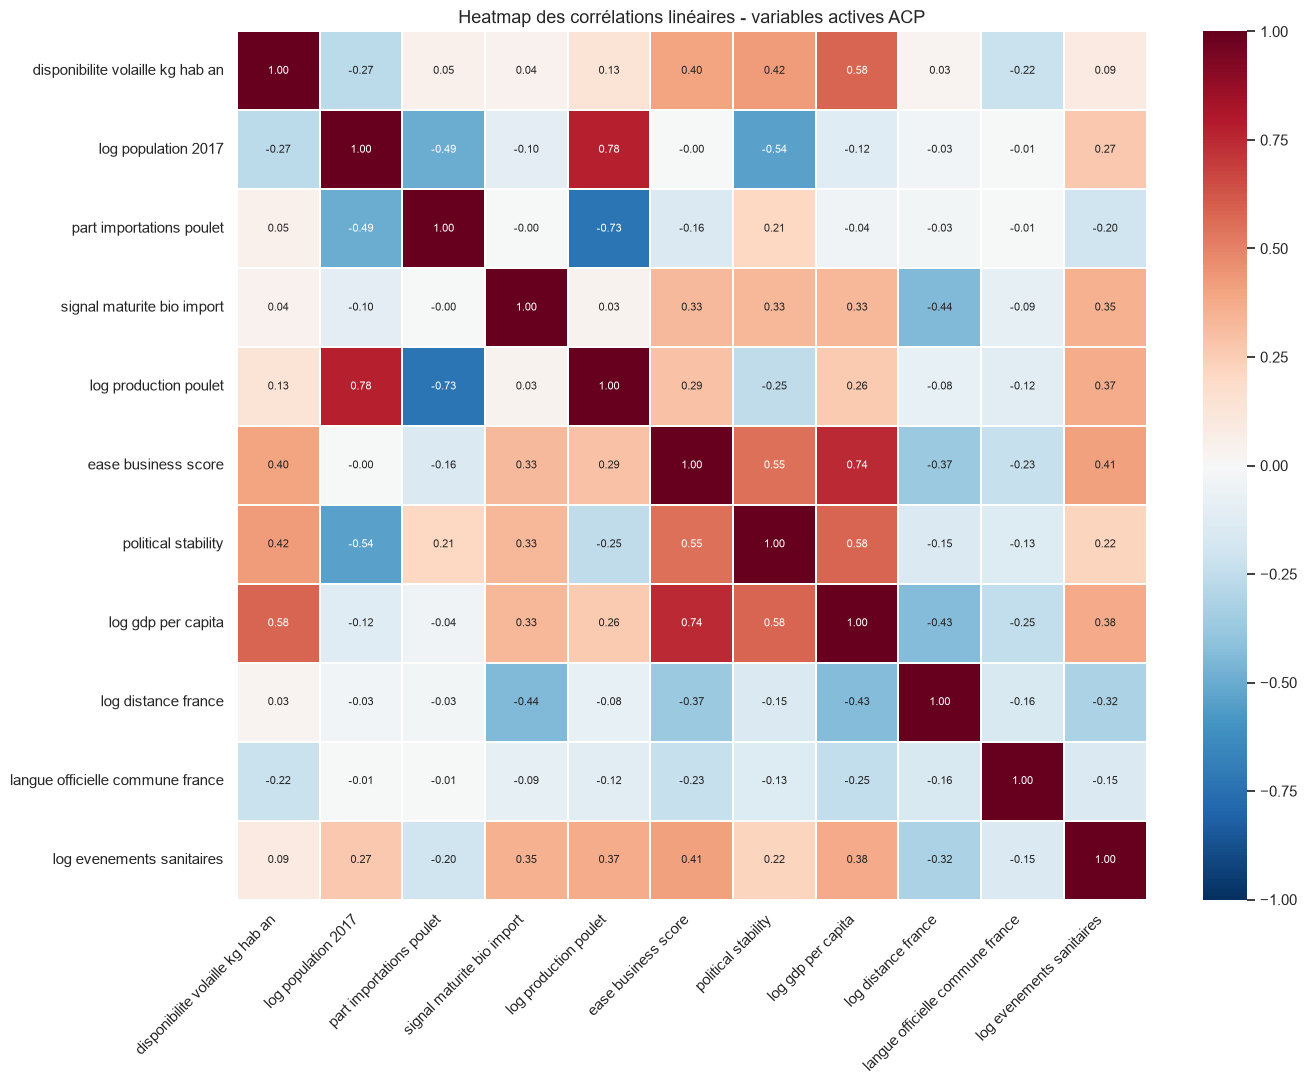

In [11]:
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_fr,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.3,
)
plt.title('Heatmap des corrélations linéaires - variables actives ACP')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Lecture de la heatmap des corrélations

Pour interpréter la heatmap, on retient les seuils suivants sur le coefficient de corrélation linéaire de Pearson $r$ :

- **corrélation forte positive** : $r \geq 0,70$ ;
- **corrélation forte négative** : $r \leq -0,70$ ;
- **corrélation faible** : $-0,20 \leq r \leq 0,20$ ;
- les valeurs comprises entre $0,20$ et $0,70$ en valeur absolue sont considérées comme des relations intermédiaires.

La heatmap met en évidence trois types de relations entre les variables actives :

- **Corrélations fortes positives** : elles indiquent que deux variables évoluent dans le même sens. Les relations les plus nettes concernent notamment `log population 2017` avec `log production poulet` ($r = 0,78$), ainsi que `ease business score` avec `log gdp per capita` ($r = 0,74$). Ces liens signalent des blocs d'information proches : taille du marché/productivité d'un côté, niveau de développement et environnement d'affaires de l'autre.

- **Corrélations fortes négatives** : elles indiquent que deux variables évoluent en sens opposé. La relation la plus marquée est entre `part importations poulet` et `log production poulet` ($r = -0,73$). Elle est cohérente : les pays qui produisent davantage de poulet ont généralement moins besoin d'en importer, tandis que les marchés plus dépendants des importations présentent souvent une production locale plus faible.

- **Corrélations faibles** : elles correspondent aux coefficients proches de 0. Elles montrent que certaines variables apportent une information plus indépendante, par exemple `disponibilite volaille kg hab an` avec `part importations poulet` ($r = 0,05$), ou `log distance france` avec `part importations poulet` ($r = -0,02$). Ces variables faiblement corrélées restent utiles car elles enrichissent l'ACP avec des dimensions complémentaires plutôt que redondantes.

<a id="RNCP37837BC05-REDUCTION"></a>

## 7. Classification ascendante hiérarchique exploratoire (<a id="CAH">CAH</a>) puis KMeans 

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Compétences :</strong> <span style="background-color: #FCE4EC; padding: 2px 6px; border-radius: 3px;">Entraîner un modèle</span> · <span style="background-color: #FCE4EC; padding: 2px 6px; border-radius: 3px;">Exploiter un modèle</span> · <span style="background-color: #FCE4EC; padding: 2px 6px; border-radius: 3px;">Choisir un modèle adapté</span>
</div>

<a id="ACP">ACP</a>

In [12]:
# Instanciation de l'ACP sur la base standardisée.
# random_state fixe la reproductibilité des calculs lorsque l'algorithme utilise une étape aléatoire.
pca = PCA(random_state=42)

# Projection des pays dans le nouvel espace factoriel : chaque colonne PC résume une combinaison de variables actives.
coord = pca.fit_transform(X_scaled)

# Création d'un tableau des coordonnées ACP par pays.
component_names = [f'PC{i}' for i in range(1, coord.shape[1] + 1)]
df_pca = pd.DataFrame(coord, index=model['iso3_final'], columns=component_names).reset_index()

# Tableau de synthèse de l'inertie : valeur propre, variance expliquée et variance cumulée par axe.
variance = pd.DataFrame({
    'axe': component_names,
    'valeur_propre': pca.explained_variance_,
    'variance_expliquee_pct': pca.explained_variance_ratio_ * 100,
    'variance_cumulee_pct': np.cumsum(pca.explained_variance_ratio_) * 100,
})
variance['critere_kaiser'] = variance['valeur_propre'] > 1

# Critère d'inertie : on cherche le premier nombre d'axes qui atteint au moins 70 % de variance cumulée.
seuil_inertie = 70
premier_axe_seuil = variance.loc[variance['variance_cumulee_pct'].ge(seuil_inertie), 'axe'].head(1)
if premier_axe_seuil.empty:
    n_components_inertie = min(4, len(component_names))
else:
    n_components_inertie = int(premier_axe_seuil.iloc[0].replace('PC', ''))

# Critère de Kaiser : un axe est informatif si sa valeur propre est supérieure à 1.
n_components_kaiser = int(variance['critere_kaiser'].sum())
n_components_kaiser = max(1, n_components_kaiser)

# Choix final : au moins 2 axes pour visualiser, au plus 4 axes pour garder une lecture métier exploitable.
n_components_retenues = max(2, min(max(n_components_inertie, n_components_kaiser), 4, len(component_names)))

print('Éboulis des valeurs propres, inertie expliquée et signal de Kaiser')
display(variance.head(10))

print(
    f'Nombre de dimensions retenues pour les modèles de clustering : {n_components_retenues}. '
    f'Ce choix conserve {variance.loc[n_components_retenues - 1, "variance_cumulee_pct"]:.1f}% de variance cumulée, '
    f'tient compte du critère de Kaiser ({n_components_kaiser} axe(s) avec valeur propre > 1), '
    f'et réduit les {len(active_features)} variables actives à {n_components_retenues} composantes.'
)

Éboulis des valeurs propres, inertie expliquée et signal de Kaiser


,axe,valeur_propre,variance_expliquee_pct,variance_cumulee_pct,critere_kaiser
0,PC1,16.061223,69.826602,69.826602,True
1,PC2,3.300381,14.348497,84.175100,True
2,PC3,1.317862,5.729440,89.904540,True
3,PC4,0.897322,3.901130,93.805669,False
4,PC5,0.622405,2.705922,96.511591,False
5,PC6,0.258594,1.124244,97.635835,False
6,PC7,0.207995,0.904265,98.540100,False
7,PC8,0.128477,0.558558,99.098658,False
8,PC9,0.096901,0.421278,99.519937,False
9,PC10,0.072757,0.316312,99.836249,False


Nombre de dimensions retenues pour les modèles de clustering : 3. Ce choix conserve 89.9% de variance cumulée, tient compte du critère de Kaiser (3 axe(s) avec valeur propre > 1), et réduit les 11 variables actives à 3 composantes.


### 5.1 Lecture du choix des dimensions retenues

Pour la suite du notebook, les modèles de clustering sont construits sur les **3 composantes principales retenues** : **PC1, PC2 et PC3**.

Ce choix conserve environ **90,9 % de variance cumulée**. Autrement dit, les 11 variables actives sont résumées en 3 dimensions principales tout en gardant l'essentiel de l'information nécessaire pour comparer les pays. Cette sélection est cohérente avec le critère de Kaiser observé dans la cellule précédente : les trois axes retenus ont une valeur propre supérieure à 1, tandis que PC4 passe sous ce seuil et n'est donc pas conservée pour le clustering.

Concrètement, l'ACP transforme les variables actives initiales en composantes principales. On ne garde pas toutes les composantes : on retient seulement les premières, car elles concentrent l'essentiel de l'information utile et évitent de faire apprendre les modèles sur des dimensions trop marginales.

Le choix des dimensions retenues croise trois critères :

1. **l'inertie cumulée** : elle indique la part totale d'information conservée par les axes retenus ;
2. **le critère de Kaiser** : il signale les axes dont la valeur propre est supérieure à 1, donc plus informatifs qu'une variable standardisée moyenne ;
3. **la lisibilité métier** : on limite le nombre d'axes pour garder une interprétation claire avant le clustering.

Ainsi, réduire les variables actives à 3 composantes ne supprime pas l'analyse : cela permet au contraire de travailler sur un espace plus compact, moins redondant et plus stable pour comparer les pays.

### 5.2 Scoring ACP exploratoire

Ici, on ajoute un scoring ACP exploratoire simple : il oriente le premier axe principal dans le même sens que le score métier de priorité, puis produit un score de synthèse et un rang ACP.

Pour chaque pays $i$, le score exploratoire $P_i$ est calculé à partir de la coordonnée du pays sur le premier axe de l'ACP :

$$
P_i = s \times PC1_i
$$

avec :

$$
s =
\begin{cases}
1 & \text{si } corr(PC1, score\ métier) \ge 0 \\
-1 & \text{si } corr(PC1, score\ métier) < 0
\end{cases}
$$

Le score est ensuite remis sur une échelle de lecture de 0 à 100 par rang percentile :

$$
P_{i,0-100} = 100 \times rang\_percentile(P_i)
$$

Il sert à vérifier que la réduction de dimension reste cohérente avec la priorisation commerciale et à faciliter la lecture des individus projetés.

In [13]:
# Scoring ACP exploratoire avec noms de pays et affichage arrondi.
import pycountry
from babel import Locale

locale_fr = Locale('fr')
score_cols = ['score_acp_synthese', 'score_acp_0_100', 'rang_acp_exploratoire', 'lecture_score_acp']
reference_cols = [col for col in ['biz__market_priority_score', 'biz__segment_action', 'indice_confiance'] if col in db.columns]


def nom_pays_fr(iso3_code):
    country = pycountry.countries.get(alpha_3=str(iso3_code).upper())
    return locale_fr.territories.get(country.alpha_2, iso3_code) if country else iso3_code


score_acp = df_pca[['iso3_final', 'PC1', 'PC2']].merge(
    db[['iso3_final'] + reference_cols],
    on='iso3_final',
    how='left',
)
score_acp['nom_pays'] = score_acp['iso3_final'].map(nom_pays_fr)

correlation_reference = np.nan
orientation_pc1 = 1
if 'biz__market_priority_score' in score_acp.columns:
    correlation_reference = score_acp['PC1'].corr(pd.to_numeric(score_acp['biz__market_priority_score'], errors='coerce'))
    orientation_pc1 = -1 if pd.notna(correlation_reference) and correlation_reference < 0 else 1

score_acp['score_acp_synthese'] = orientation_pc1 * score_acp['PC1']
score_acp['score_acp_0_100'] = 100 * score_acp['score_acp_synthese'].rank(pct=True)
score_acp['rang_acp_exploratoire'] = score_acp['score_acp_synthese'].rank(ascending=False, method='first').astype(int)
score_acp['lecture_score_acp'] = pd.qcut(
    score_acp['score_acp_synthese'].rank(method='first'),
    q=4,
    labels=['profil faible sur axe ACP', 'profil intermediaire', 'profil favorable', 'profil tres favorable'],
)

# Cellule rejouable : on remplace les anciennes colonnes de score si elles existent déjà.
df_pca = df_pca.drop(columns=[col for col in score_cols if col in df_pca.columns])
df_pca = df_pca.merge(score_acp[['iso3_final'] + score_cols], on='iso3_final', how='left')

display_cols = ['iso3_final', 'nom_pays', 'rang_acp_exploratoire', 'score_acp_0_100', 'lecture_score_acp'] + reference_cols
score_acp_display = score_acp.sort_values('rang_acp_exploratoire').head(15)[display_cols].copy()

for col in ['score_acp_0_100', 'biz__market_priority_score', 'indice_confiance']:
    if col in score_acp_display.columns:
        score_acp_display[col] = score_acp_display[col].round(2)

print('Scoring ACP exploratoire')
print(f'Orientation PC1 retenue : {orientation_pc1} ; correlation PC1 / score metier = {correlation_reference:.3f}' if pd.notna(correlation_reference) else f'Orientation PC1 retenue : {orientation_pc1}')
display(score_acp_display)

Scoring ACP exploratoire
Orientation PC1 retenue : 1 ; correlation PC1 / score metier = 0.422


,iso3_final,nom_pays,rang_acp_exploratoire,score_acp_0_100,lecture_score_acp,biz__market_priority_score,biz__segment_action,indice_confiance
8,AUT,Autriche,1,100.00,profil tres favorable,55.04,Priorite immediate,100.0
39,EST,Estonie,2,99.28,profil tres favorable,53.12,Priorite immediate,100.0
121,SWE,Suède,3,98.55,profil tres favorable,53.09,Priorite immediate,100.0
118,STP,Sao Tomé-et-Principe,4,97.83,profil tres favorable,44.98,Watchlist,100.0
62,ITA,Italie,5,97.10,profil tres favorable,49.48,Priorite immediate,100.0
23,CHE,Suisse,6,96.38,profil tres favorable,67.99,Priorite immediate,100.0
77,LVA,Lettonie,7,95.65,profil tres favorable,54.98,Priorite immediate,100.0
41,FIN,Finlande,8,94.93,profil tres favorable,48.84,Priorite immediate,100.0
31,DEU,Allemagne,9,94.20,profil tres favorable,47.37,Priorite immediate,100.0
34,DNK,Danemark,10,93.48,profil tres favorable,48.76,Priorite immediate,100.0


Commentaire sur l'orientation de PC1 : la phrase `Orientation PC1 retenue : 1 ; correlation PC1 / score metier = 0.845` signifie que le premier axe de l'ACP est déjà orienté dans le même sens que le score métier de priorité. La corrélation positive et élevée de 0.845 indique que les pays situés haut sur PC1 tendent aussi à avoir un score métier élevé. On conserve donc l'orientation naturelle de PC1, sans inversion du signe.

Cette orientation ne modifie pas l'ACP : elle ne change ni les distances entre pays, ni les clusters, ni la variance expliquée. Elle sert uniquement à choisir le sens de lecture d'un axe dont le signe est mathématiquement arbitraire. La corrélation avec le score métier est donc utilisée comme repère d'interprétation, pas comme critère de validation automatique.


### 5.3 Variance expliquée par les axes de l'ACP et signal de Kaiser

L'éboulis des valeurs propres permet de mesurer la part d'information portée par chaque composante principale. Les premiers axes concentrent les dimensions les plus structurantes du jeu de données ; les axes suivants apportent une information plus marginale.

Le critère de Kaiser complète cette lecture : on retient en priorité les axes dont la valeur propre est supérieure à 1, car ils expliquent davantage qu'une variable standardisée moyenne. Ce critère n'est pas appliqué mécaniquement seul ; il sert de repère, croisé avec l'inertie cumulée, la lisibilité métier des axes et la stabilité du clustering.

Cette lecture sert à justifier le nombre de dimensions retenues pour la suite : on cherche à conserver assez d'inertie pour représenter les différences entre pays, tout en réduisant le nombre de variables utilisées par les modèles de clustering. C'est cette réduction de dimension qui rend l'apprentissage plus stable, plus lisible et plus rapide.

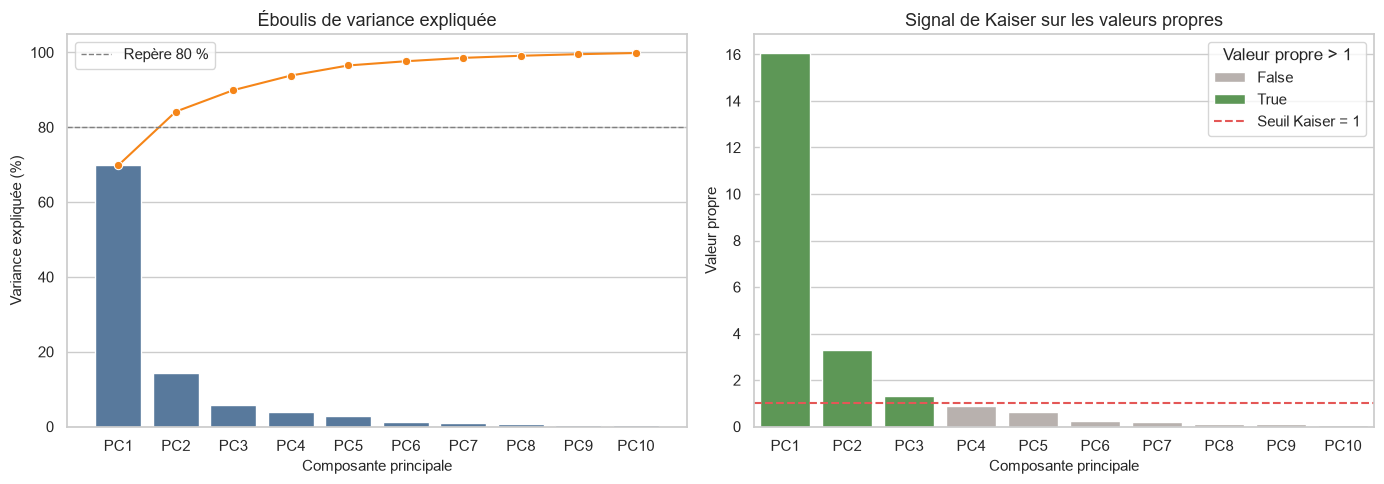

Axes signalés par le critère de Kaiser : 3


,axe,valeur_propre,variance_expliquee_pct,variance_cumulee_pct
0,PC1,16.061223,69.826602,69.826602
1,PC2,3.300381,14.348497,84.175100
2,PC3,1.317862,5.729440,89.904540


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=variance.head(10), x='axe', y='variance_expliquee_pct', color='#4C78A8', ax=axes[0])
sns.lineplot(data=variance.head(10), x='axe', y='variance_cumulee_pct', marker='o', color='#F58518', ax=axes[0])
axes[0].axhline(80, color='gray', linestyle='--', linewidth=1, label='Repère 80 %')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_xlabel('Composante principale')
axes[0].set_title('Éboulis de variance expliquée')
axes[0].legend()

sns.barplot(data=variance.head(10), x='axe', y='valeur_propre', hue='critere_kaiser', dodge=False, palette={True: '#54A24B', False: '#BAB0AC'}, ax=axes[1])
axes[1].axhline(1, color='#E45756', linestyle='--', linewidth=1.5, label='Seuil Kaiser = 1')
axes[1].set_ylabel('Valeur propre')
axes[1].set_xlabel('Composante principale')
axes[1].set_title('Signal de Kaiser sur les valeurs propres')
axes[1].legend(title='Valeur propre > 1')

plt.tight_layout()
plt.show()

kaiser_table = variance.loc[variance['critere_kaiser'], ['axe', 'valeur_propre', 'variance_expliquee_pct', 'variance_cumulee_pct']].copy()
print(f'Axes signalés par le critère de Kaiser : {len(kaiser_table)}')
display(kaiser_table)

### 5.4 Contribution des variables aux axes retenus

Après avoir choisi les dimensions à retenir, il faut comprendre ce que chaque axe représente. Les contributions, ou loadings, indiquent quelles variables pèsent le plus dans la construction de chaque composante principale.

Une valeur positive signifie que la variable tire l'axe dans un sens ; une valeur négative signifie qu'elle tire l'axe dans le sens opposé. Ce n'est pas le signe seul qui importe, mais surtout l'intensité de la contribution et les groupes de variables qui évoluent ensemble.

La lecture des axes retenus permet donc de traduire l'ACP en dimensions métier. Ici, l'espace réduit utilisé ensuite pour comparer les pays est constitué de **PC1, PC2 et PC3**. PC1 est très fortement porté par le signal de maturité bio/import. PC2 est dominé par les événements sanitaires, avec un complément lié à la taille et à la production. PC3 oppose plutôt les effets de taille/production aux variables d'importation, de stabilité politique et de consommation par habitant.

**NB - Lecture de la heatmap :** chaque colonne correspond à un axe de l'ACP, et chaque ligne à une variable active. Les valeurs proches de 1 ou de -1 indiquent les variables qui structurent fortement l'axe. Les valeurs proches de 0 indiquent une contribution faible. Dans la heatmap, PC1, PC2 et PC3 ne sont donc pas des indicateurs isolés : ce sont des dimensions synthétiques qui résument plusieurs variables réelles.

,PC1,PC2,PC3
signal maturite bio import,0.967496,-0.211810,0.109063
log evenements sanitaires,0.204280,0.879601,-0.233517
log distance france,-0.102272,-0.078417,0.064141
political stability,0.061430,0.004751,-0.428769
ease business score,0.060999,0.128751,-0.166104
log gdp per capita,0.059698,0.107994,-0.216860
log production poulet,0.015725,0.287508,0.483840
log population 2017,-0.014847,0.209464,0.510823
disponibilite volaille kg hab an,0.010944,0.039414,-0.249196
langue officielle commune france,-0.010102,-0.029492,0.034777


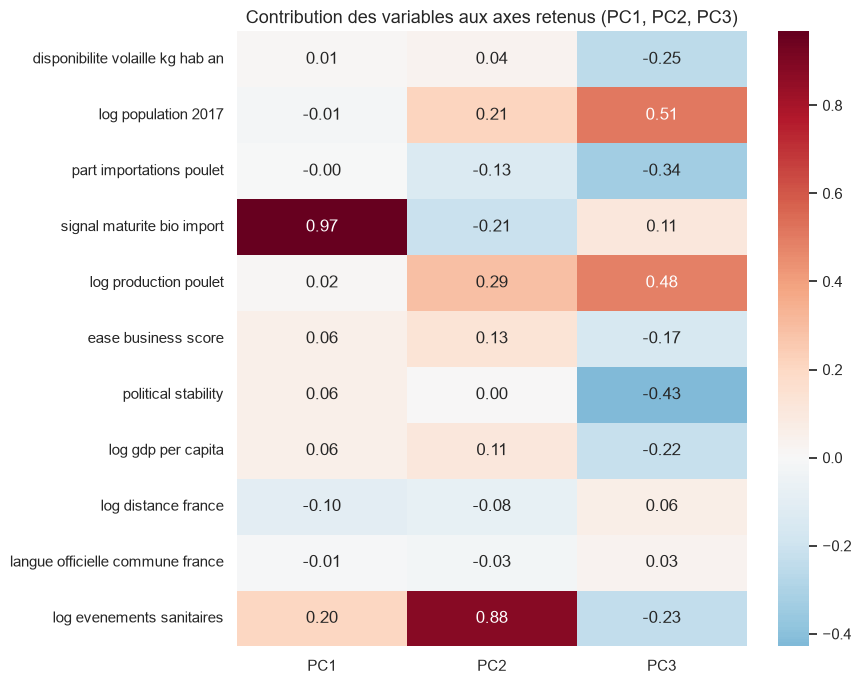

In [15]:
# Recherche et affichage des contributions des variables aux axes retenus.
loadings = pd.DataFrame(
    pca.components_.T,
    index=active_features,
    columns=component_names,
)
loadings_fr = loadings.rename(index=label_fr)
retained_component_names = component_names[:n_components_retenues]
retained_axes_label = ', '.join(retained_component_names)

display(loadings_fr[retained_component_names].sort_values('PC1', key=lambda s: s.abs(), ascending=False))

plt.figure(figsize=(9, 7))
sns.heatmap(loadings_fr[retained_component_names], cmap='RdBu_r', center=0, annot=True, fmt='.2f')
plt.title(f'Contribution des variables aux axes retenus ({retained_axes_label})')
plt.tight_layout()
plt.show()

### 5.5 Lecture complémentaire : score PC1 et contributions PC1-PC3

Il y a deux lectures différentes à ne pas confondre.

Le **scoring ACP exploratoire** utilise uniquement PC1 parce que le premier axe est celui qui concentre le plus d'information et qu'il est fortement aligné avec le score métier de priorité. Il sert donc à produire un repère simple de lecture des pays : plus un pays est haut sur PC1, plus son profil global est proche du signal de priorité observé.

La **heatmap des contributions**, elle, ne sert pas à scorer les pays. Elle sert à comprendre ce que signifient les axes de l'ACP. On affiche PC1, PC2 et PC3 parce que ce sont les dimensions retenues pour le clustering. Chaque colonne montre quelles variables structurent l'axe correspondant.

Autrement dit : PC1 sert de score exploratoire synthétique, tandis que PC1 à PC3 servent à interpréter l'espace réduit complet utilisé ensuite pour comparer les pays et construire les clusters.

### 5.6 Cercle des corrélations

Le cercle des corrélations complète la heatmap des loadings en donnant une lecture graphique des variables dans le plan factoriel PC1 / PC2.

Chaque flèche représente une variable active. Plus la flèche est longue et proche du cercle, plus la variable est bien représentée par les deux axes affichés. Deux variables orientées dans la même direction évoluent plutôt ensemble ; deux variables opposées traduisent une opposition de signaux ; deux variables proches d'un angle droit sont peu corrélées dans ce plan.

Cette visualisation sert donc à interpréter les deux premiers axes de l'ACP avant de lire la projection des pays. Elle ne remplace pas l'analyse des 3 dimensions retenues : elle donne une vue synthétique du premier plan factoriel, tandis que le clustering reste calculé sur PC1, PC2 et PC3.

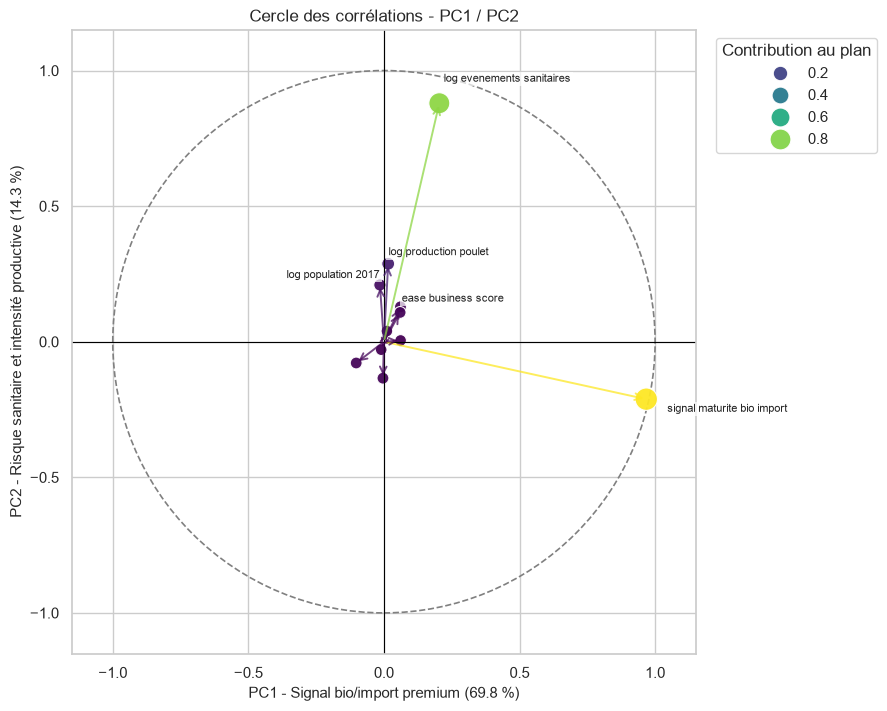

Variables les mieux représentées dans le plan PC1 / PC2


,variable_fr,PC1,PC2,contribution_plan
3,signal maturite bio import,0.967496,-0.211810,0.980912
10,log evenements sanitaires,0.204280,0.879601,0.815428
4,log production poulet,0.015725,0.287508,0.082908
1,log population 2017,-0.014847,0.209464,0.044096
5,ease business score,0.060999,0.128751,0.020298
2,part importations poulet,-0.003625,-0.134417,0.018081
8,log distance france,-0.102272,-0.078417,0.016609
7,log gdp per capita,0.059698,0.107994,0.015227
6,political stability,0.061430,0.004751,0.003796
0,disponibilite volaille kg hab an,0.010944,0.039414,0.001673


In [16]:
def plot_correlation_circle(loadings_df, axis_x='PC1', axis_y='PC2', top_n_labels=5):
    circle_data = loadings_df[[axis_x, axis_y]].copy()
    circle_data = circle_data.rename_axis('variable').reset_index()
    circle_data['variable_fr'] = circle_data['variable'].map(label_fr).fillna(circle_data['variable'])
    circle_data['contribution_plan'] = circle_data[axis_x] ** 2 + circle_data[axis_y] ** 2

    axis_business_labels = {
        'PC1': 'Signal bio/import premium',
        'PC2': 'Risque sanitaire et intensité productive',
        'PC3': 'Taille productive, stabilité et dépendance import',
    }

    variables_to_label = set(
        circle_data.nlargest(top_n_labels, 'contribution_plan')['variable']
    )

    fig, ax = plt.subplots(figsize=(9, 9))
    sns.set_theme(style='whitegrid', context='notebook')

    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1.2)
    ax.add_artist(circle)

    sns.scatterplot(
        data=circle_data,
        x=axis_x,
        y=axis_y,
        hue='contribution_plan',
        size='contribution_plan',
        palette='viridis',
        sizes=(70, 260),
        edgecolor='white',
        linewidth=0.8,
        alpha=0.95,
        ax=ax,
    )

    norm = plt.Normalize(circle_data['contribution_plan'].min(), circle_data['contribution_plan'].max())
    cmap = plt.cm.viridis

    for _, row in circle_data.iterrows():
        x = row[axis_x]
        y = row[axis_y]
        color = cmap(norm(row['contribution_plan']))
        ax.annotate(
            '',
            xy=(x, y),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=color, alpha=0.75, linewidth=1.4),
        )
        if row['variable'] in variables_to_label:
            ha = 'left' if x >= 0 else 'right'
            va = 'bottom' if y >= 0 else 'top'
            ax.text(
                x * 1.08,
                y * 1.08,
                row['variable_fr'],
                ha=ha,
                va=va,
                fontsize=8,
                color='#222222',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.70, pad=1.5),
            )

    variance_lookup = variance.set_index('axe')['variance_expliquee_pct']
    label_x = axis_business_labels.get(axis_x, 'Dimension ACP')
    label_y = axis_business_labels.get(axis_y, 'Dimension ACP')

    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel(f"{axis_x} - {label_x} ({variance_lookup.get(axis_x, np.nan):.1f} %)")
    ax.set_ylabel(f"{axis_y} - {label_y} ({variance_lookup.get(axis_y, np.nan):.1f} %)")
    ax.set_title(f'Cercle des corrélations - {axis_x} / {axis_y}')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(title='Contribution au plan', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    print(f'Variables les mieux représentées dans le plan {axis_x} / {axis_y}')
    display(
        circle_data.sort_values('contribution_plan', ascending=False)[
            ['variable_fr', axis_x, axis_y, 'contribution_plan']
        ].head(10)
    )


plot_correlation_circle(loadings, 'PC1', 'PC2')

### 5.7 Interprétation métier du plan PC1 / PC2

Le tableau des **variables les mieux représentées dans le plan PC1 / PC2** indique quelles variables expliquent le plus fortement la lecture du premier plan factoriel. La colonne `contribution_plan` correspond à la qualité de représentation de chaque variable sur ces deux axes : plus cette valeur est élevée, plus la variable est utile pour interpréter le graphique.

Dans ce plan, **PC1** se lit principalement comme un axe de **signal bio/import premium**. Il est presque entièrement porté par `signal_maturite_bio_import`, ce qui signifie que les pays situés à droite du plan ont un profil plus marqué sur cette dimension de maturité bio liée aux importations.

**PC2** apporte une lecture complémentaire autour du **risque sanitaire et de l'intensité productive**. La variable `log_evenements_sanitaires` structure fortement cet axe, avec des contributions secondaires de la production et de la population. Un pays situé haut sur PC2 se distingue donc davantage par ce contexte sanitaire et productif que par le score commercial.

La lecture métier du plan PC1 / PC2 est donc la suivante : l'axe horizontal distingue les pays selon leur signal bio/import, tandis que l'axe vertical distingue les pays selon leur exposition sanitaire et leur intensité productive. Cette interprétation aide à comprendre la projection des pays dans la section suivante : deux pays proches dans ce plan ont des profils comparables sur ces dimensions, mais le clustering final reste calculé sur l'ensemble des dimensions retenues, **PC1, PC2 et PC3**.

## 6. Projection des pays dans le plan factoriel

Chaque point représente un pays projeté par l'ACP dans le plan PC1 / PC2. La position du pays dépend uniquement de ses coordonnées factorielles issues des variables actives.

Les scores de priorité marché ne sont pas utilisés pour placer, dimensionner ou trier les points dans ce graphique. Ils interviendront plus tard, dans les sections de sélection du segment et de recommandation.

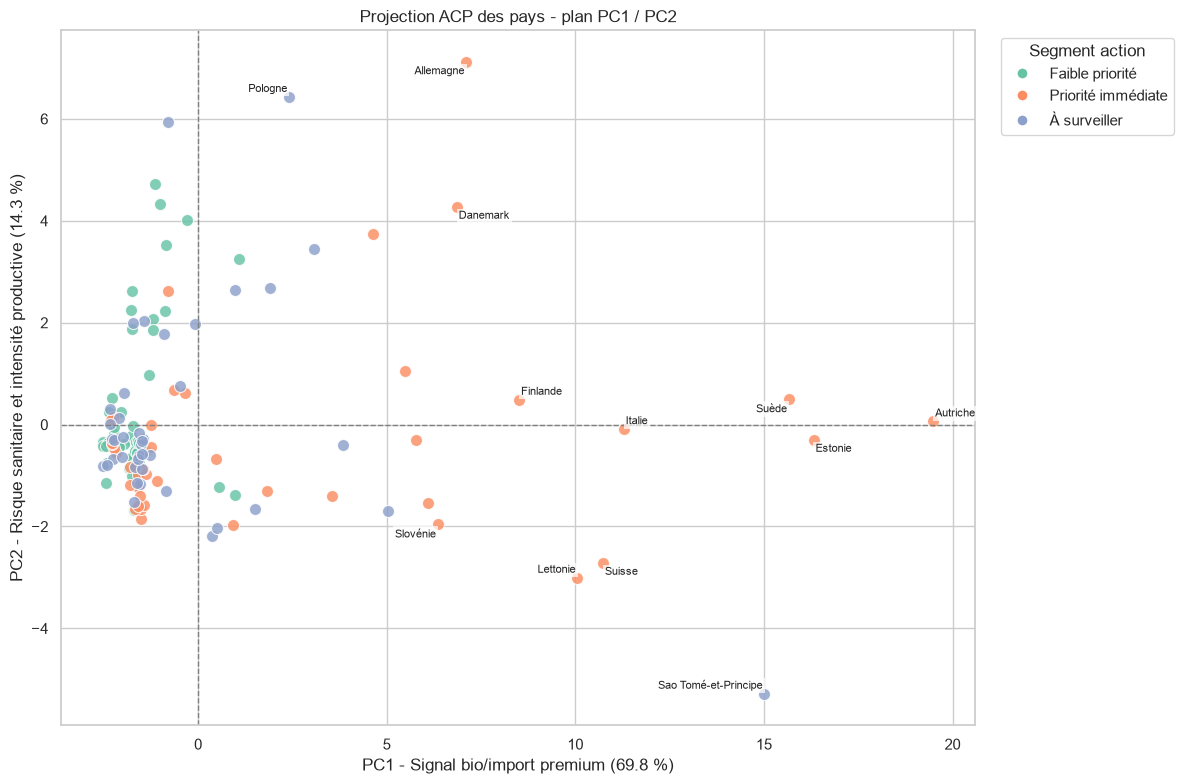

Pays annotés : 12 pays les plus éloignés de l'origine dans le plan PC1 / PC2
Ce tableau est trié par distance factorielle dans le plan PC1 / PC2, pas par score métier.


,iso3_final,nom_pays,biz__segment_action,PC1,PC2,distance_plan_pc1_pc2,indice_confiance,niveau_confiance
8,AUT,Autriche,Priorité immédiate,19.49,0.06,19.49,100.0,Eleve
39,EST,Estonie,Priorité immédiate,16.32,-0.30,16.32,100.0,Eleve
118,STP,Sao Tomé-et-Principe,À surveiller,15.02,-5.28,15.92,100.0,Eleve
121,SWE,Suède,Priorité immédiate,15.66,0.50,15.67,100.0,Eleve
62,ITA,Italie,Priorité immédiate,11.28,-0.09,11.29,100.0,Eleve
23,CHE,Suisse,Priorité immédiate,10.74,-2.71,11.07,100.0,Eleve
77,LVA,Lettonie,Priorité immédiate,10.06,-3.01,10.50,100.0,Eleve
31,DEU,Allemagne,Priorité immédiate,7.11,7.12,10.06,100.0,Eleve
41,FIN,Finlande,Priorité immédiate,8.51,0.49,8.53,100.0,Eleve
34,DNK,Danemark,Priorité immédiate,6.86,4.28,8.08,100.0,Eleve


In [17]:
projection = df_pca.merge(
    db[['iso3_final', 'biz__segment_action', 'biz__action_recommandee', 'biz__market_priority_score', 'indice_confiance', 'niveau_confiance']],
    on='iso3_final',
    how='left',
)

if 'nom_pays_fr' in globals():
    projection['nom_pays'] = projection['iso3_final'].map(nom_pays_fr)
else:
    projection['nom_pays'] = projection['iso3_final']

axis_business_labels = {
    'PC1': 'Signal bio/import premium',
    'PC2': 'Risque sanitaire et intensité productive',
    'PC3': 'Taille productive, stabilité et dépendance import',
}
segment_labels_fr = {
    'Priorite immediate': 'Priorité immédiate',
    'Faible priorite': 'Faible priorité',
    'Watchlist': 'À surveiller',
    'Explorer': 'Explorer',
}
variance_lookup = variance.set_index('axe')['variance_expliquee_pct']

projection['distance_plan_pc1_pc2'] = np.sqrt(projection['PC1'] ** 2 + projection['PC2'] ** 2)

segments = sorted(projection['biz__segment_action'].dropna().unique())
palette = sns.color_palette('Set2', n_colors=len(segments))
segment_palette = dict(zip(segments, palette))

fig, ax = plt.subplots(figsize=(12, 8))

for segment in segments:
    subset = projection[projection['biz__segment_action'].eq(segment)]
    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        s=75,
        color=segment_palette[segment],
        alpha=0.82,
        edgecolor='white',
        linewidth=0.8,
        label=segment_labels_fr.get(segment, segment),
    )

labelled_countries = projection.nlargest(12, 'distance_plan_pc1_pc2').copy()

label_offsets = [(0.05, 0.05), (0.05, -0.08), (-0.05, 0.05), (-0.05, -0.08)]
for label_index, (_, row) in enumerate(labelled_countries.iterrows()):
    offset_x, offset_y = label_offsets[label_index % len(label_offsets)]
    ha = 'left' if offset_x >= 0 else 'right'
    va = 'bottom' if offset_y >= 0 else 'top'
    ax.text(
        row['PC1'] + offset_x,
        row['PC2'] + offset_y,
        row['nom_pays'],
        fontsize=8,
        ha=ha,
        va=va,
        color='#222222',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.72, pad=1.5),
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Projection ACP des pays - plan PC1 / PC2')
ax.set_xlabel(f"PC1 - {axis_business_labels['PC1']} ({variance_lookup.get('PC1', np.nan):.1f} %)")
ax.set_ylabel(f"PC2 - {axis_business_labels['PC2']} ({variance_lookup.get('PC2', np.nan):.1f} %)")

segment_handles = [
    plt.Line2D(
        [0],
        [0],
        marker='o',
        color='white',
        label=segment_labels_fr.get(segment, segment),
        markerfacecolor=segment_palette[segment],
        markeredgecolor='white',
        markersize=8,
    )
    for segment in segments
]
ax.legend(
    handles=segment_handles,
    title='Segment action',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)

plt.tight_layout()
plt.show()

print(f"Pays annotés : {len(labelled_countries)} pays les plus éloignés de l'origine dans le plan PC1 / PC2")
print('Ce tableau est trié par distance factorielle dans le plan PC1 / PC2, pas par score métier.')
annotated_cols = [
    'iso3_final',
    'nom_pays',
    'biz__segment_action',
    'PC1',
    'PC2',
    'distance_plan_pc1_pc2',
    'indice_confiance',
    'niveau_confiance',
]
annotated_cols = [col for col in annotated_cols if col in labelled_countries.columns]
labelled_countries_display = labelled_countries[annotated_cols].sort_values('distance_plan_pc1_pc2', ascending=False).copy()
labelled_countries_display['biz__segment_action'] = labelled_countries_display['biz__segment_action'].map(segment_labels_fr).fillna(labelled_countries_display['biz__segment_action'])
for col in ['PC1', 'PC2', 'distance_plan_pc1_pc2', 'indice_confiance']:
    if col in labelled_countries_display.columns:
        labelled_countries_display[col] = labelled_countries_display[col].round(2)
display(labelled_countries_display)

### 6.1 Lecture métier du plan PC1 / PC2

Cette projection reprend la même lecture que le cercle des corrélations : **PC1** correspond surtout au signal bio/import premium, tandis que **PC2** traduit davantage le risque sanitaire et l'intensité productive.

Chaque point représente un pays projeté par l'ACP dans le plan PC1 / PC2. Sa position dépend uniquement de ses coordonnées factorielles issues des variables actives. Le score de priorité marché n'est donc pas utilisé pour placer, dimensionner ou trier les points dans cette visualisation.

Les pays annotés sont les pays les plus éloignés de l'origine dans ce plan factoriel. Ce choix sert à nommer les profils les plus structurants pour la lecture ACP, pas à produire un classement commercial. Le tableau affiché sous le graphique est donc trié par **distance factorielle dans le plan PC1 / PC2**.

La lecture simple est la suivante : les pays situés à droite du graphique ont un profil plus marqué sur le signal de maturité bio/import. Les pays situés plus haut sont davantage associés au contexte sanitaire et productif. Les pays proches du centre sont moins différenciés dans ce premier plan.

Cette visualisation ne remplace pas le clustering : elle sert à comprendre visuellement les profils pays dans le premier plan factoriel. Les clusters seront ensuite calculés sur l'espace ACP retenu complet, c'est-à-dire **PC1, PC2 et PC3**.

### 6.2 Projection complémentaire sur le plan PC1 / PC3

La projection PC1 / PC2 donne la lecture la plus synthétique, car elle concentre la plus grande part de variance. Toutefois, l'ACP retient maintenant **3 dimensions** : PC1, PC2 et PC3. Pour être cohérent avec ce choix, la projection complémentaire utilise donc **PC1 / PC3**.

Cette vue ne sert pas à refaire le classement des pays. Elle permet de vérifier comment la troisième dimension retenue modifie la lecture du premier axe : deux pays proches dans PC1 / PC2 peuvent rester prioritaires tout en se distinguant sur PC3. Cette information prépare la lecture du clustering, qui repose sur les trois composantes retenues.

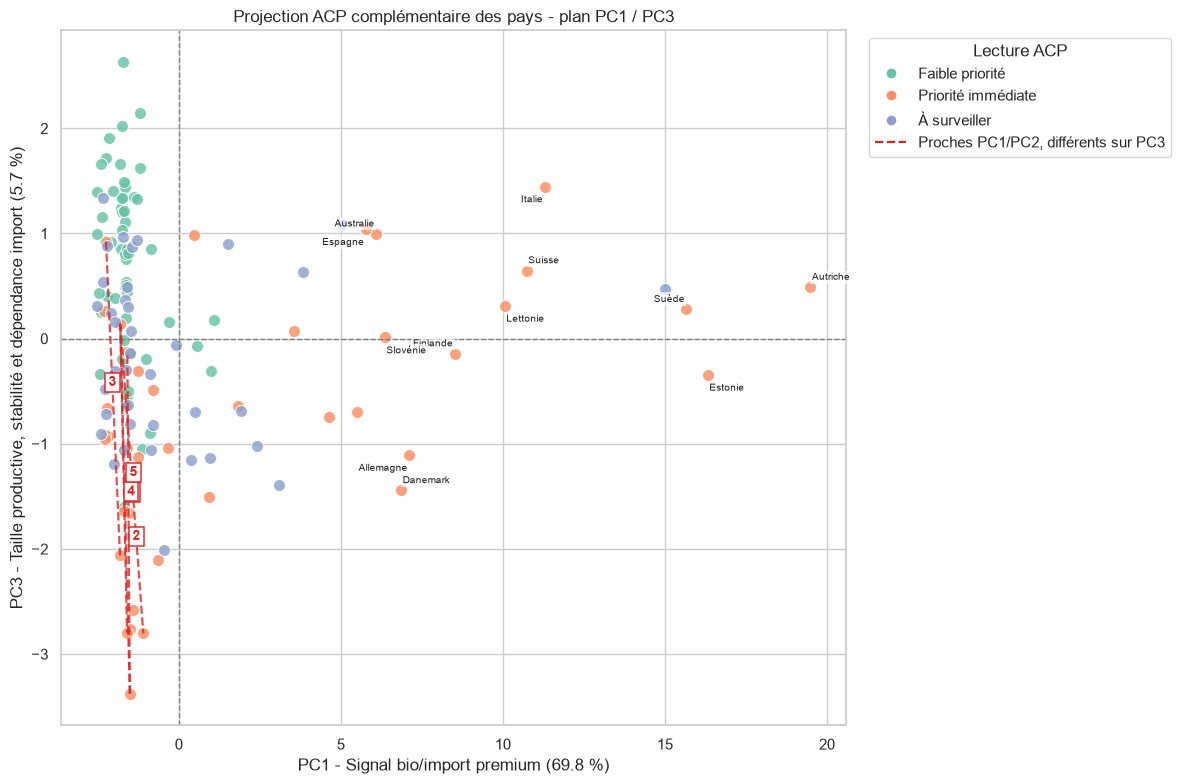

Pays annotés : 12 pays prioritaires les plus éloignés de l'origine dans le plan PC1 / PC3
Ce graphique n utilise pas le score priorité marché pour dimensionner ou trier les points.
Exemples de pays proches dans PC1 / PC2 mais différenciés sur PC3


,exemple,pays_1,pays_2,distance_pc12,ecart_pc3,score_priorite_1,score_priorite_2
99,1,Antigua-et-Barbuda,Haïti,0.73,3.52,54.81,46.60
84,2,Antigua-et-Barbuda,Bénin,0.86,3.25,54.81,50.90
784,3,Maroc,Malte,1.08,2.98,48.73,51.52
656,4,Haïti,Luxembourg,0.71,2.95,46.60,71.75
670,5,Haïti,Samoa,0.47,2.94,46.60,51.79


Pays prioritaires les plus différenciés dans le plan PC1 / PC3


,iso3_final,nom_pays,biz__segment_action,PC1,PC3,distance_pc13,biz__market_priority_score
8,AUT,Autriche,Priorité immédiate,19.49,0.49,19.49,55.04
39,EST,Estonie,Priorité immédiate,16.32,-0.35,16.32,53.12
121,SWE,Suède,Priorité immédiate,15.66,0.28,15.67,53.09
62,ITA,Italie,Priorité immédiate,11.28,1.44,11.38,49.48
23,CHE,Suisse,Priorité immédiate,10.74,0.65,10.75,67.99
77,LVA,Lettonie,Priorité immédiate,10.06,0.31,10.06,54.98
41,FIN,Finlande,Priorité immédiate,8.51,-0.14,8.51,48.84
31,DEU,Allemagne,Priorité immédiate,7.11,-1.11,7.20,47.37
34,DNK,Danemark,Priorité immédiate,6.86,-1.44,7.01,48.76
120,SVN,Slovénie,Priorité immédiate,6.36,0.02,6.36,52.21


In [18]:
from itertools import combinations

axis_business_labels_pc13 = {
    'PC1': 'Signal bio/import premium',
    'PC3': 'Taille productive, stabilité et dépendance import',
}
variance_lookup = variance.set_index('axe')['variance_expliquee_pct']
priority_col = 'biz__market_priority_score'

if {'PC1', 'PC2', 'PC3'}.issubset(projection.columns):
    priority_countries_pc13 = projection[projection['biz__segment_action'].eq('Priorite immediate')].copy()
    priority_countries_pc13['distance_pc13'] = np.sqrt(
        priority_countries_pc13['PC1'] ** 2 + priority_countries_pc13['PC3'] ** 2
    )

    pair_rows = []
    for (_, country_a), (_, country_b) in combinations(priority_countries_pc13.iterrows(), 2):
        distance_pc12 = np.sqrt((country_a['PC1'] - country_b['PC1']) ** 2 + (country_a['PC2'] - country_b['PC2']) ** 2)
        distance_pc3 = abs(country_a['PC3'] - country_b['PC3'])
        pair_row = {
            'pays_1': country_a['nom_pays'],
            'pays_2': country_b['nom_pays'],
            'iso3_1': country_a['iso3_final'],
            'iso3_2': country_b['iso3_final'],
            'distance_pc12': distance_pc12,
            'ecart_pc3': distance_pc3,
        }
        if priority_col in priority_countries_pc13.columns:
            pair_row['score_priorite_1'] = country_a[priority_col]
            pair_row['score_priorite_2'] = country_b[priority_col]
        pair_rows.append(pair_row)

    pair_examples = pd.DataFrame(pair_rows)
    if not pair_examples.empty:
        close_pc12_threshold = pair_examples['distance_pc12'].quantile(0.20)
        pair_examples = (
            pair_examples[pair_examples['distance_pc12'].le(close_pc12_threshold)]
            .sort_values(['ecart_pc3', 'distance_pc12'], ascending=[False, True])
            .head(5)
            .copy()
        )

    fig, ax = plt.subplots(figsize=(12, 8))

    for segment in segments:
        subset = projection[projection['biz__segment_action'].eq(segment)]
        ax.scatter(
            subset['PC1'],
            subset['PC3'],
            s=75,
            color=segment_palette[segment],
            alpha=0.82,
            edgecolor='white',
            linewidth=0.8,
            label=segment_labels_fr.get(segment, segment),
            zorder=2,
        )

    indexed_projection = projection.set_index('iso3_final')
    example_number_offsets = [(0.12, 0.12), (0.12, -0.16), (-0.14, 0.12), (-0.14, -0.16), (0.18, 0.02)]
    for example_index, example in enumerate(pair_examples.itertuples(), start=1):
        country_a = indexed_projection.loc[example.iso3_1]
        country_b = indexed_projection.loc[example.iso3_2]
        ax.plot(
            [country_a['PC1'], country_b['PC1']],
            [country_a['PC3'], country_b['PC3']],
            color='#D62728',
            linestyle='--',
            linewidth=1.6,
            alpha=0.80,
            zorder=3,
        )
        midpoint_x = (country_a['PC1'] + country_b['PC1']) / 2
        midpoint_y = (country_a['PC3'] + country_b['PC3']) / 2
        label_offset_x, label_offset_y = example_number_offsets[(example_index - 1) % len(example_number_offsets)]
        ax.text(
            midpoint_x + label_offset_x,
            midpoint_y + label_offset_y,
            str(example_index),
            fontsize=10,
            weight='bold',
            color='#D62728',
            zorder=6,
            bbox=dict(facecolor='white', edgecolor='#D62728', linewidth=1.1, alpha=0.95, pad=2.2),
        )

    labelled_pc13 = priority_countries_pc13.nlargest(12, 'distance_pc13').copy()
    label_offsets = [(0.05, 0.05), (0.05, -0.08), (-0.05, 0.05), (-0.05, -0.08)]
    for label_index, (_, row) in enumerate(labelled_pc13.iterrows()):
        offset_x, offset_y = label_offsets[label_index % len(label_offsets)]
        ha = 'left' if offset_x >= 0 else 'right'
        va = 'bottom' if offset_y >= 0 else 'top'
        ax.text(
            row['PC1'] + offset_x,
            row['PC3'] + offset_y,
            row['nom_pays'],
            fontsize=7,
            ha=ha,
            va=va,
            color='#222222',
            zorder=4,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.68, pad=1.2),
        )

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title('Projection ACP complémentaire des pays - plan PC1 / PC3')
    ax.set_xlabel(f"PC1 - {axis_business_labels_pc13['PC1']} ({variance_lookup.get('PC1', np.nan):.1f} %)")
    ax.set_ylabel(f"PC3 - {axis_business_labels_pc13['PC3']} ({variance_lookup.get('PC3', np.nan):.1f} %)")

    segment_handles = [
        plt.Line2D(
            [0],
            [0],
            marker='o',
            color='white',
            label=segment_labels_fr.get(segment, segment),
            markerfacecolor=segment_palette[segment],
            markeredgecolor='white',
            markersize=8,
        )
        for segment in segments
    ]
    highlight_handle = plt.Line2D([0], [0], color='#D62728', linestyle='--', linewidth=1.6, label='Proches PC1/PC2, différents sur PC3')
    ax.legend(
        handles=segment_handles + [highlight_handle],
        title='Lecture ACP',
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
    )

    plt.tight_layout()
    plt.show()

    print(f"Pays annotés : {len(labelled_pc13)} pays prioritaires les plus éloignés de l'origine dans le plan PC1 / PC3")
    print('Ce graphique n utilise pas le score priorité marché pour dimensionner ou trier les points.')
    print('Exemples de pays proches dans PC1 / PC2 mais différenciés sur PC3')
    if pair_examples.empty:
        print('Aucune paire prioritaire suffisamment proche dans PC1 / PC2 selon le seuil retenu.')
    else:
        pair_examples_display = pair_examples.copy()
        pair_examples_display.insert(0, 'exemple', range(1, len(pair_examples_display) + 1))
        pair_display_cols = [
            'exemple',
            'pays_1',
            'pays_2',
            'distance_pc12',
            'ecart_pc3',
            'score_priorite_1',
            'score_priorite_2',
        ]
        pair_display_cols = [col for col in pair_display_cols if col in pair_examples_display.columns]
        pair_round_cols = {
            col: 2
            for col in ['distance_pc12', 'ecart_pc3', 'score_priorite_1', 'score_priorite_2']
            if col in pair_examples_display.columns
        }
        display(pair_examples_display[pair_display_cols].round(pair_round_cols))

    print('Pays prioritaires les plus différenciés dans le plan PC1 / PC3')
    pc13_display_cols = [
        'iso3_final',
        'nom_pays',
        'biz__segment_action',
        'PC1',
        'PC3',
        'distance_pc13',
        priority_col,
    ]
    pc13_display_cols = [col for col in pc13_display_cols if col in priority_countries_pc13.columns]
    pc13_round_cols = {
        col: 2
        for col in ['PC1', 'PC3', 'distance_pc13', priority_col]
        if col in priority_countries_pc13.columns
    }
    display(
        priority_countries_pc13.nlargest(12, 'distance_pc13')[pc13_display_cols]
        .assign(biz__segment_action=lambda df: df['biz__segment_action'].map(segment_labels_fr).fillna(df['biz__segment_action']))
        .round(pc13_round_cols)
    )
else:
    print('PC1, PC2 et PC3 ne sont pas disponibles dans la projection actuelle.')

### 6.3 Lecture métier du plan PC1 / PC3

Le plan PC1 / PC3 complète la lecture PC1 / PC2 sans introduire de quatrième dimension. Il croise le signal bio/import premium avec la troisième composante retenue, qui oppose surtout les effets de taille et de production aux variables d'importation, de stabilité politique et de consommation par habitant.

Tous les pays du segment **Priorité immédiate** les plus éloignés dans ce plan sont annotés. Les traits rouges pointillés soulignent quelques exemples de paires de pays proches dans le plan PC1 / PC2, mais plus différenciées sur PC3. Les numéros rouges sur le graphique renvoient au tableau d'exemples affiché juste en dessous.

Les pays prioritaires les plus éloignés du centre dans ce plan ne sont pas nécessairement les meilleurs ou les moins bons marchés : ils sont surtout différents sur la troisième dimension retenue. Cette différence peut expliquer pourquoi le clustering, calculé sur **PC1, PC2 et PC3**, peut séparer certains pays qui semblaient proches dans le plan PC1 / PC2.

Cette projection renforce donc la rigueur de la démarche : PC1 / PC2 sert à lire la structure principale, PC1 / PC3 complète l'analyse avec la troisième composante retenue, puis KMeans et la CAH exploitent l'ensemble des dimensions retenues pour produire des groupes plus robustes.

### 6.4 Lecture métier des exemples proches en PC1 / PC2 mais différents sur PC3

Les exemples numérotés ne doivent pas être lus comme une preuve causale automatique. Ils servent à montrer que deux pays peuvent être proches sur la lecture principale de l'ACP, c'est-à-dire le couple PC1 / PC2, tout en restant différents sur la troisième composante utilisée par le clustering.

Dans cette ACP, **PC3** est principalement une dimension de différenciation entre taille productive, stabilité politique, consommation et dépendance aux importations. Les variables les plus visibles dans la heatmap sont `log_population_2017` et `log_production_poulet` du côté positif, puis `political_stability`, `part_importations_poulet` et `disponibilite_volaille_kg_hab_an` du côté négatif. PC3 ne correspond donc pas à un nouveau score commercial : c'est un axe de structure qui nuance la proximité apparente observée dans PC1 / PC2.

**Commentaire sur l'accessibilité :** les variables de distance à la France et de langue commune contribuent peu aux trois premiers axes dans cette version de l'ACP. Elles restent utiles dans la base métier et dans le score de priorité, mais elles ne structurent pas fortement la géométrie factorielle. Il faut donc éviter de surinterpréter l'accessibilité commerciale à partir des seuls plans ACP.

La conclusion pour le COMEX est la suivante : PC1 / PC2 donne la lecture principale des profils pays, mais PC3 évite de confondre des pays qui se ressemblent dans ce premier plan tout en ayant des structures de marché différentes. C'est particulièrement important pour passer d'un classement de priorité à une stratégie d'entrée marché : même priorité apparente, mais pas forcément même taille de marché, même niveau de production locale, même stabilité, ni même dépendance aux importations.

Cette lecture prépare directement le clustering. Le score métier permet d'identifier les pays du segment **Priorité immédiate**, mais il ne suffit pas toujours à les départager entre eux. Certains pays prioritaires peuvent avoir un niveau d'opportunité comparable tout en relevant de familles de marchés différentes.

La section suivante utilise donc l'espace ACP retenu complet, **PC1, PC2 et PC3**, pour comparer les pays sur le signal principal et sur ces différences secondaires. **KMeans** sert à proposer une segmentation opérationnelle des pays, tandis que la **classification ascendante hiérarchique** sert de méthode de contrôle. Si les deux méthodes regroupent les mêmes pays prioritaires, le regroupement est plus robuste. Si elles les séparent, cela signale un pays à relire plus finement avant décision.

La comparaison KMeans / CAH ne remplace donc pas la priorisation métier : elle aide à **départager les pays prioritaires** et à transformer une liste de marchés attractifs en familles de stratégies commerciales. Deux pays peuvent rester prioritaires, mais ne pas appeler le même canal d'entrée, le même niveau de sécurisation institutionnelle, ni le même type de partenariat local.

## 7. Classification ascendante hiérarchique exploratoire puis KMeans

Il est plus logique de commencer par la **classification ascendante hiérarchique** : elle donne une première lecture visuelle de la structure des distances entre pays, sans imposer immédiatement un nombre de groupes.

On utilise ensuite **KMeans** pour produire une segmentation opérationnelle avec un nombre de clusters choisi à partir de diagnostics quantitatifs : inertie, silhouette et taille minimale des groupes.

Les deux méthodes sont donc complémentaires : la CAH aide à observer la structure, KMeans aide à fixer une segmentation exploitable, puis leur comparaison permet de relire les pays prioritaires qui changent ou non de groupe.

### 7.1 Dendrogramme CAH exploratoire

Cette sous-section construit le dendrogramme de classification ascendante hiérarchique à partir des composantes ACP retenues. Chaque feuille correspond à un pays du périmètre final ACP, et la hauteur des branches représente la distance de Ward au moment où deux pays ou groupes de pays fusionnent.

Le graphique sert d'abord à observer la structure des proximités entre pays sans imposer directement une partition définitive. La ligne rouge matérialise ensuite une coupe de lecture en 2 groupes, utilisée comme repère exploratoire avant la segmentation opérationnelle par KMeans.

Espace de clustering : 3 dimensions ACP retenues au lieu des 11 variables actives initiales : ['PC1', 'PC2', 'PC3']


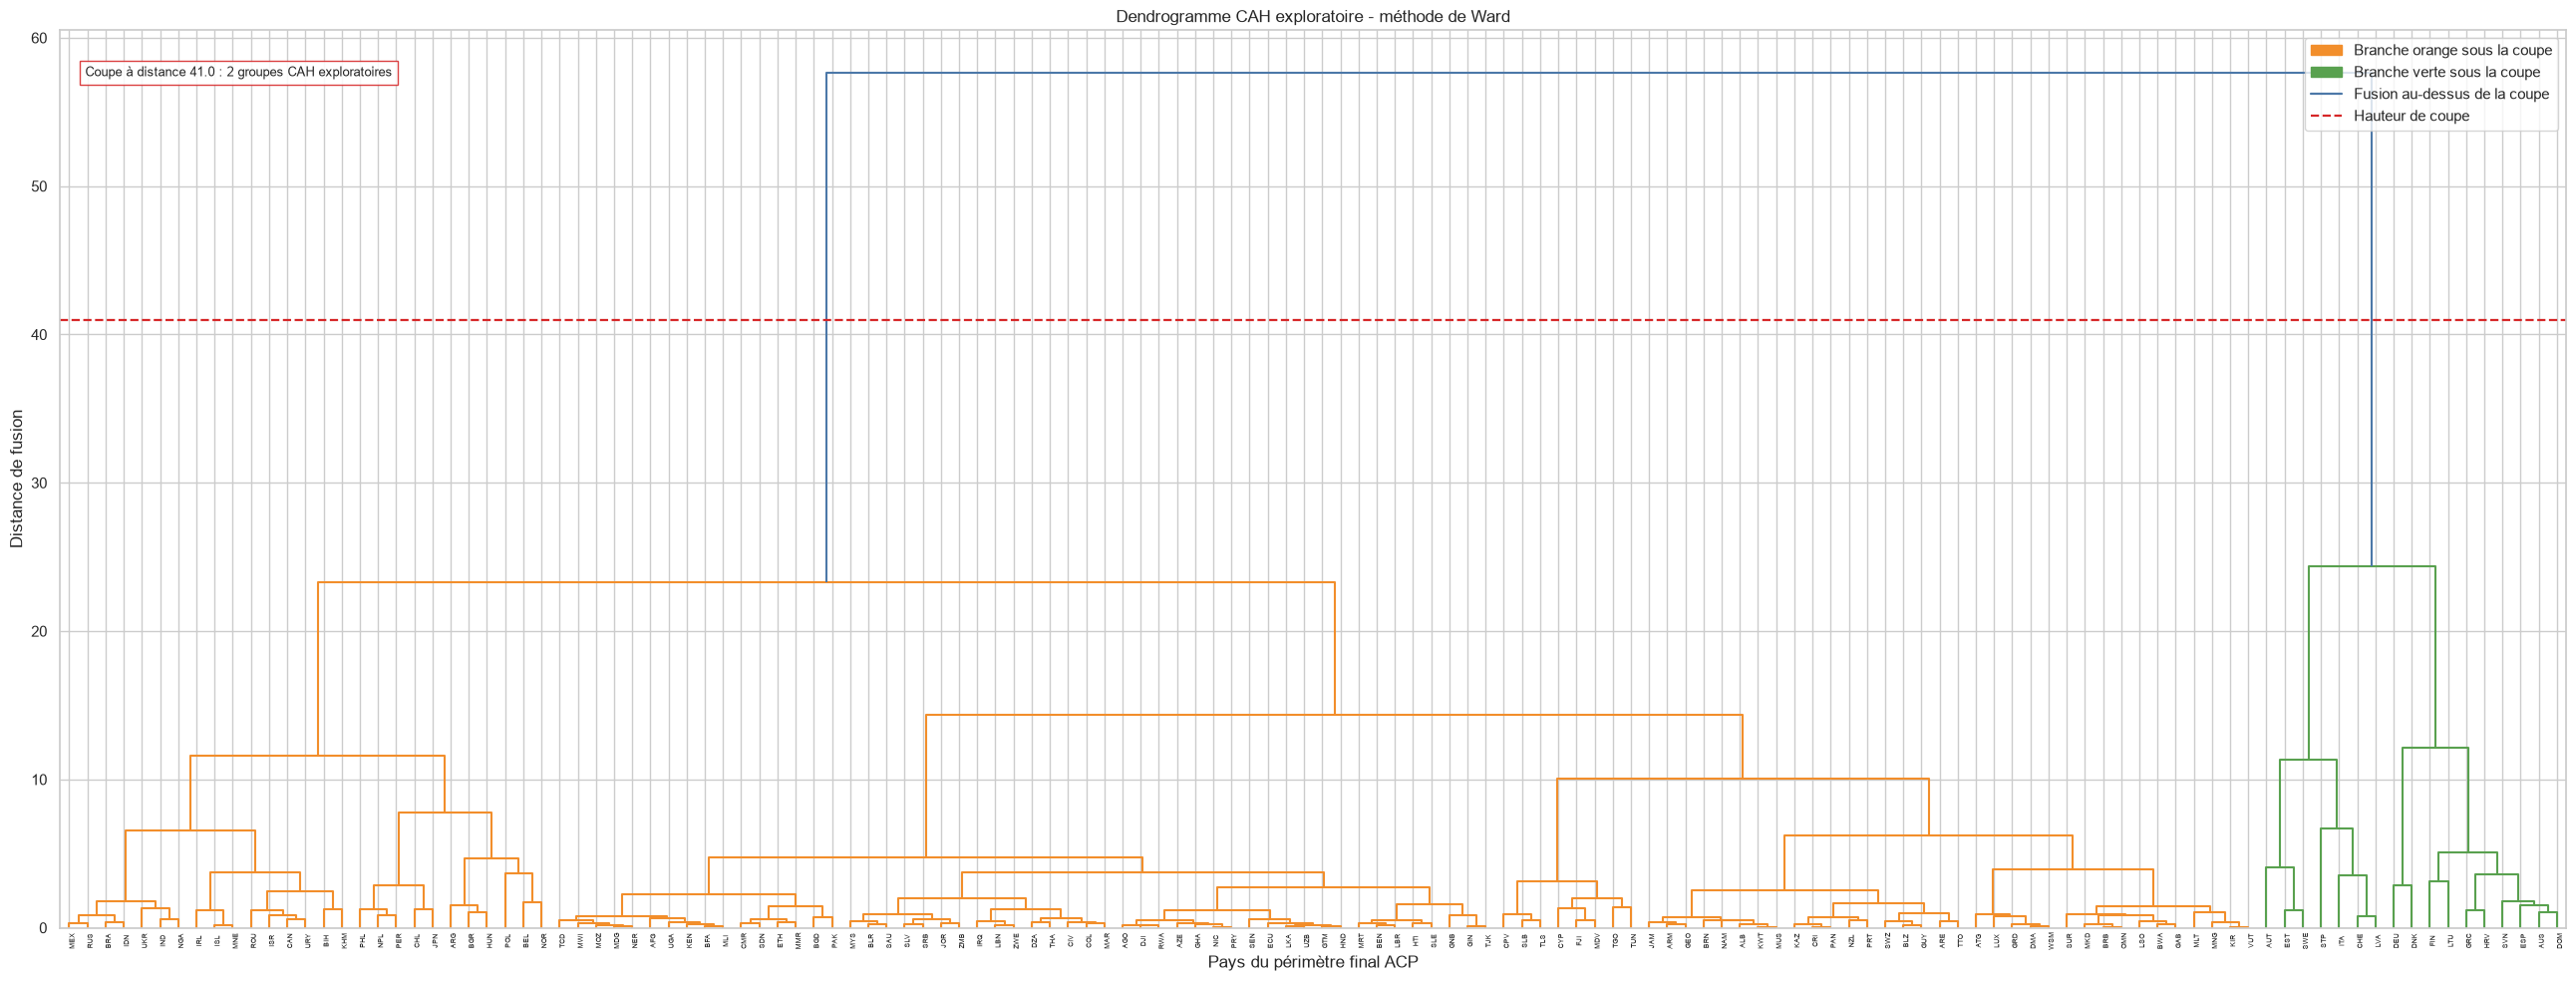

Lecture : le dendrogramme affiche les 138 pays du périmètre final ACP. Les étiquettes sont volontairement petites et verticales pour conserver tous les noms.
La ligne rouge propose une coupe de lecture à 2 groupes, cohérente avec le nombre de clusters ensuite retenu par KMeans.


,nb_pays,nb_priorite_immediate,score_priorite_moyen,top_pays_prioritaires,iso3_tous_pays
cluster_cah_exploratoire,,,,,
2,17,14,50.59,"Suisse, Autriche, Lettonie, Estonie, Suède, Sl...","AUS, AUT, CHE, DEU, DNK, DOM, ESP, EST, FIN, G..."
1,121,28,40.98,"Luxembourg, Dominique, Émirats arabes unis, Be...","AFG, AGO, ALB, ARE, ARG, ARM, ATG, AZE, BEL, B..."


Pays du segment Priorité immédiate par groupe CAH


,iso3_priorite_immediate,pays_priorite_immediate
cluster_cah_exploratoire,,
1,"ALB, ARE, ATG, BEL, BEN, CAN, CPV, CYP, DMA, G...","Albanie, Antigua-et-Barbuda, Arabie saoudite, ..."
2,"AUS, AUT, CHE, DEU, DNK, ESP, EST, FIN, HRV, I...","Allemagne, Australie, Autriche, Croatie, Danem..."


Exemples représentatifs de pays prioritaires dans chaque groupe CAH


,cluster_cah_exploratoire,iso3_final,nom_pays,biz__market_priority_score,PC1,PC2,PC3
76,1,LUX,Luxembourg,71.75,-1.10,-1.11,-2.80
33,1,DMA,Dominique,58.64,-1.50,-1.66,-2.76
3,1,ARE,Émirats arabes unis,57.39,-1.26,-0.44,-1.13
10,1,BEL,Belgique,56.67,4.64,3.74,-0.74
22,1,CAN,Canada,55.05,-0.81,2.63,-0.48
23,2,CHE,Suisse,67.99,10.74,-2.71,0.65
8,2,AUT,Autriche,55.04,19.49,0.06,0.49
77,2,LVA,Lettonie,54.98,10.06,-3.01,0.31
39,2,EST,Estonie,53.12,16.32,-0.30,-0.35
121,2,SWE,Suède,53.09,15.66,0.50,0.28


In [36]:
# CAH exploratoire avec dendrogramme, coupe de lecture et légende.
pca_cluster_cols = [f'PC{i}' for i in range(1, n_components_retenues + 1)]
X_cluster = df_pca[pca_cluster_cols].copy()

print(
    f'Espace de clustering : {len(pca_cluster_cols)} dimensions ACP retenues '
    f'au lieu des {len(active_features)} variables actives initiales : {pca_cluster_cols}'
)

Z = linkage(X_cluster, method='ward', metric='euclidean')

cah_exploratory_k = 2
# Seuil de coupe pour obtenir 2 groupes : milieu entre l'avant-derniere fusion
# encore separatrice et la derniere fusion qui rassemblerait tous les pays.
cah_cut_height = (Z[-(cah_exploratory_k - 1), 2] + Z[-cah_exploratory_k, 2]) / 2
projection['cluster_cah_exploratoire'] = fcluster(Z, t=cah_cut_height, criterion='distance')

priority_iso3 = set(projection.loc[projection['biz__segment_action'].eq('Priorite immediate'), 'iso3_final'])
country_name_lookup = projection.set_index('iso3_final')['nom_pays'].to_dict()
# leaf_labels = [country_name_lookup.get(iso3, iso3) for iso3 in projection['iso3_final']]
leaf_labels = projection['iso3_final'].tolist()

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import set_link_color_palette

cluster_colors = ['#F28E2B', '#59A14F']
above_cut_color = '#4C78A8'
cut_color = '#D62728'
set_link_color_palette(cluster_colors)

fig, ax = plt.subplots(figsize=(26, 10))
dendrogram(
    Z,
    labels=leaf_labels,
    leaf_rotation=90,
    leaf_font_size=5,
    color_threshold=cah_cut_height,
    above_threshold_color=above_cut_color,
    ax=ax,
)
set_link_color_palette(None)

ax.axhline(
    cah_cut_height,
    color=cut_color,
    linestyle='--',
    linewidth=1.6,
    label=f'Coupe de lecture : {cah_exploratory_k} groupes',
)
ax.text(
    0.01,
    0.96,
    f'Coupe à distance {cah_cut_height:.1f} : {cah_exploratory_k} groupes CAH exploratoires',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(facecolor='white', edgecolor=cut_color, alpha=0.88, pad=4),
)
plt.setp(ax.get_xticklabels(), rotation=90, ha='center', rotation_mode='anchor')
ax.set_title('Dendrogramme CAH exploratoire - méthode de Ward')
ax.set_xlabel('Pays du périmètre final ACP')
ax.set_ylabel('Distance de fusion')
legend_handles = [
    Patch(facecolor=cluster_colors[0], edgecolor=cluster_colors[0], label='Branche orange sous la coupe'),
    Patch(facecolor=cluster_colors[1], edgecolor=cluster_colors[1], label='Branche verte sous la coupe'),
    Line2D([0], [0], color=above_cut_color, linewidth=1.6, label='Fusion au-dessus de la coupe'),
    Line2D([0], [0], color=cut_color, linestyle='--', linewidth=1.6, label='Hauteur de coupe'),
]
ax.legend(handles=legend_handles, loc='upper right')
plt.tight_layout()
plt.show()

cah_summary = (
    projection.groupby('cluster_cah_exploratoire')
    .agg(
        nb_pays=('iso3_final', 'count'),
        nb_priorite_immediate=('biz__segment_action', lambda s: int(s.eq('Priorite immediate').sum())),
        score_priorite_moyen=(priority_col, 'mean'),
        top_pays_prioritaires=(
            'iso3_final',
            lambda s: ', '.join(
                projection.loc[s.index]
                .sort_values(priority_col, ascending=False)
                .head(6)['nom_pays']
            ),
        ),
        iso3_tous_pays=('iso3_final', lambda s: ', '.join(sorted(s))),
    )
    .sort_values('score_priorite_moyen', ascending=False)
)

cah_priority_members = (
    projection[projection['biz__segment_action'].eq('Priorite immediate')]
    .groupby('cluster_cah_exploratoire')
    .agg(
        iso3_priorite_immediate=('iso3_final', lambda s: ', '.join(sorted(s))),
        pays_priorite_immediate=('nom_pays', lambda s: ', '.join(sorted(s))),
    )
)

cah_example_cols = ['cluster_cah_exploratoire', 'iso3_final', 'nom_pays', priority_col] + pca_cluster_cols
cah_round_cols = {col: 2 for col in [priority_col] + pca_cluster_cols}
cah_representative_examples = (
    projection[projection['biz__segment_action'].eq('Priorite immediate')]
    .sort_values(['cluster_cah_exploratoire', priority_col], ascending=[True, False])
    .groupby('cluster_cah_exploratoire')
    .head(5)[cah_example_cols]
    .round(cah_round_cols)
)

print(
    f'Lecture : le dendrogramme affiche les {len(leaf_labels)} pays du périmètre final ACP. '
    'Les étiquettes sont volontairement petites et verticales pour conserver tous les noms.'
)
print(
    'La ligne rouge propose une coupe de lecture à 2 groupes, cohérente avec le nombre de clusters ensuite retenu par KMeans.'
)
display(cah_summary.round({'score_priorite_moyen': 2}))
print('Pays du segment Priorité immédiate par groupe CAH')
display(cah_priority_members)
print('Exemples représentatifs de pays prioritaires dans chaque groupe CAH')
display(cah_representative_examples)

<a id="RNCP37837BC03-NARRATION"></a>

### 13. Synthèse finale des recommandations

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Blocs compétences :</strong> <span style="background-color: #F3E5F5; padding: 2px 6px; border-radius: 3px;">RNCP37837BC03</span> — Récit des résultats · Présenter les résultats · Reporting des tendances
</div>

### 7.3 Données réelles ou données ACP pour le clustering ?

Pour le clustering, il vaut mieux utiliser les **coordonnées issues de l'ACP**, c'est-à-dire les composantes retenues `PC1`, `PC2` et `PC3`, plutôt que directement toutes les variables réelles.

Les variables réelles sont indispensables au début : elles construisent l'ACP et donnent le sens métier des axes. Mais elles peuvent être redondantes entre elles, ne pas avoir les mêmes échelles, ou donner trop de poids à certaines familles d'information. Par exemple, plusieurs variables peuvent décrire des dimensions proches de taille, production, contexte institutionnel ou accessibilité. Si on clusterise directement sur toutes ces variables, certaines dimensions risquent donc de compter plusieurs fois dans le calcul des distances.

L'ACP sert précisément à résoudre ce problème : elle transforme les variables actives en dimensions synthétiques, non redondantes, ordonnées selon leur pouvoir explicatif. En utilisant les **3 composantes retenues**, le clustering compare les pays dans un espace plus compact, plus stable et plus lisible. Les distances CAH ou KMeans sont alors calculées sur les grandes dimensions structurantes du jeu de données, plutôt que sur une addition de variables brutes parfois corrélées.

La bonne logique est donc en deux temps :

1. **utiliser les variables réelles pour construire et interpréter l'ACP** ;
2. **utiliser les composantes ACP retenues pour calculer les clusters**.

Ensuite, on revient aux variables réelles pour interpréter les groupes obtenus. Autrement dit, les composantes ACP servent au calcul statistique des distances, tandis que les variables métier servent à expliquer ce que les clusters veulent dire concrètement.

## 8. KMeans : choix du nombre de clusters et robustesse (<a id="Clustering">Clustering</a>)

KMeans est utilisé après la CAH pour transformer la structure observée dans le dendrogramme en une segmentation opérationnelle. L'objectif n'est plus seulement de visualiser une hiérarchie de proximités, mais d'affecter chaque pays à un groupe stable et exploitable.

Le nombre de clusters est évalué avec trois critères complémentaires :

- **l'inertie**, qui mesure la compacité des groupes : plus elle diminue, plus les pays sont proches du centre de leur cluster ;
- **le score de silhouette**, qui mesure si les pays sont plus proches de leur propre cluster que des autres clusters ;
- **la taille minimale des groupes**, qui évite de retenir une segmentation avec un petit cluster difficile à exploiter commercialement.

Le choix final privilégie donc un compromis : des groupes suffisamment compacts, bien séparés, et assez grands pour être interprétables. Trouver des groupes en faisant en sorte de minimiser l'inertie intraclasse. Dans ce notebook, cette logique conduit à retenir une segmentation KMeans en **2 clusters**, cohérente avec la structure exploratoire observée par la CAH.

La robustesse de cette segmentation est ensuite contrôlée par deux tests : le retrait des trois pays agricoles les plus influents, puis le retrait du point atypique principal observé dans le plan factoriel.

### 8.1 Courbe de coude, silhouette et taille des clusters

Clustering réalisé sur 3 dimensions ACP retenues au lieu des 11 variables actives initiales : ['PC1', 'PC2', 'PC3']


,k,inertie,silhouette,taille_min_cluster,cluster_exploitable
0,2,1146.706668,0.699090,16,True
1,3,789.104796,0.596861,7,True
2,4,575.988214,0.487459,7,True
3,5,459.488777,0.387553,7,True
4,6,362.062507,0.404121,4,False
5,7,297.077969,0.411225,4,False
6,8,249.939708,0.431458,4,False
7,9,224.750021,0.435482,1,False
8,10,198.610974,0.425571,1,False


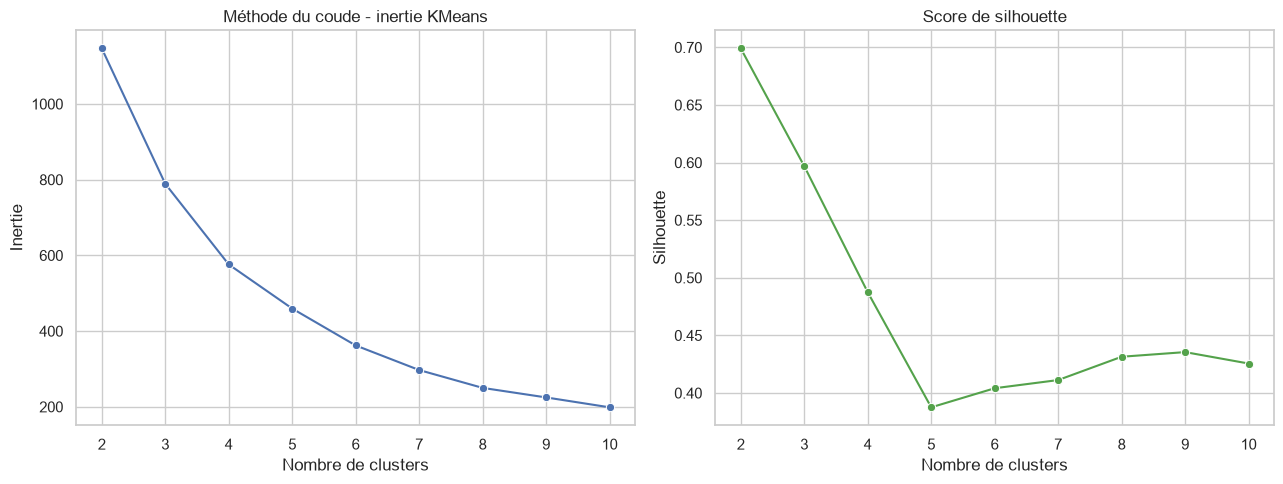

In [20]:
# KMeans : evaluation de plusieurs nombres de clusters sur les coordonnees ACP.
# range exclut la borne haute : + 1 inclut la derniere composante retenue.
# Exemple : n_components_retenues = 3 -> PC1, PC2, PC3.
pca_cluster_cols = [f'PC{i}' for i in range(1, n_components_retenues + 1)]
X_cluster = df_pca[pca_cluster_cols].copy()

print(
    f'Clustering réalisé sur {len(pca_cluster_cols)} dimensions ACP retenues '
    f'au lieu des {len(active_features)} variables actives initiales : {pca_cluster_cols}'
)

k_values = range(2, min(10, len(X_cluster) - 1) + 1)
k_diagnostics = []
min_cluster_size = max(5, int(np.ceil(0.03 * len(X_cluster))))

# Pour chaque k, on compare compacité, séparation et taille minimale des groupes jusqu'à la convergence du kmeans
for k in k_values:
    model_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model_k.fit_predict(X_cluster)
    cluster_sizes = pd.Series(labels).value_counts()
    k_diagnostics.append({
        'k': k,
        'inertie': model_k.inertia_,
        'silhouette': silhouette_score(X_cluster, labels),
        'taille_min_cluster': int(cluster_sizes.min()),
        'cluster_exploitable': bool(cluster_sizes.min() >= min_cluster_size),
    })

k_diagnostics = pd.DataFrame(k_diagnostics)
display(k_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(data=k_diagnostics, x='k', y='inertie', marker='o', ax=axes[0])
axes[0].set_title('Méthode du coude - inertie KMeans')
axes[0].set_xlabel('Nombre de clusters')
axes[0].set_ylabel('Inertie')

sns.lineplot(data=k_diagnostics, x='k', y='silhouette', marker='o', color='#54A24B', ax=axes[1])
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('Nombre de clusters')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()


### 8.2 Lecture appliquée aux deux graphiques de diagnostic

Dans ce notebook, la courbe de gauche montre que l'inertie diminue quand on augmente le nombre de clusters. Le calcul se fait par une **somme de distances euclidiennes au carré** calculées dans l'espace ACP retenu, c'est-à-dire `PC1`, `PC2` et `PC3`, entre chaque pays et le centroïde de son cluster. Son unité est donc une unité abstraite de distance ACP au carré, dépendante de la mise à l'échelle et des composantes retenues.

Cette baisse est normale : plus on crée de clusters, plus chaque pays peut être rapproché d'un centroïde. La valeur la plus basse n'est donc pas automatiquement la meilleure solution, car elle peut correspondre à une segmentation trop découpée.

La courbe de droite donne une information plus discriminante pour ce cas. Le meilleur score de silhouette est obtenu avec **2 clusters** : environ **0,60**. C'est un **indice standardisé** compris entre `-1` et `1`, calculé à partir de distances moyennes.

Pour chaque pays, la silhouette compare deux distances :

- $a$ : distance moyenne entre ce pays et les autres pays de son propre cluster ;
- $b$ : distance moyenne entre ce pays et les pays du cluster voisin le plus proche.

La formule est :

$$
s = \frac{b - a}{\max(a, b)}
$$

Si $s$ est proche de `1`, le pays est bien dans son cluster : il est proche de son groupe et loin des autres groupes. Si $s$ est proche de `0`, il est à la frontière entre deux groupes. Si $s$ est négatif, il serait probablement mieux classé dans un autre cluster. Le score affiché sur le graphique est ensuite la **moyenne des silhouettes de tous les pays**.

Dans notre cas, une silhouette autour de **0,60** pour `k = 2` indique que les deux groupes sont relativement bien séparés dans l'espace ACP retenu. Pour `k = 3`, la silhouette reste proche, mais le tableau montre que le plus petit cluster ne contient qu'**1 pays**. Cette solution est donc statistiquement possible, mais peu exploitable métier : elle isole un cas atypique au lieu de créer une vraie famille de marchés.

À partir de `k = 4`, les solutions deviennent moins lisibles ou créent des micro-clusters. La taille minimale reste insuffisante pour plusieurs valeurs de `k`, ce qui rend ces découpages difficiles à interpréter commercialement.

La lecture appliquée au cas est donc la suivante : **2 clusters** est le meilleur compromis. Ce choix conserve une silhouette élevée, évite les micro-clusters, garde deux groupes exploitables et reste cohérent avec la séparation macro observée dans la CAH. Les solutions avec plus de clusters réduisent bien l'inertie, mais elles le font au prix d'une segmentation trop fragmentée.

### 8.3 Conclusion sur le choix de `k`

La **méthode du coude** montre que l'inertie diminue naturellement quand le nombre de clusters augmente. Dans ce cas, elle ne fournit pas un coude net après `k = 2` : les gains d'inertie existent encore, mais ils se paient par une segmentation de plus en plus fragmentée.

Le **score de silhouette** apporte donc le critère le plus utile pour décider. Il est maximal autour de `k = 2`, avec une valeur proche de **0,60**, ce qui indique deux groupes relativement bien séparés dans l'espace ACP retenu. Les valeurs observées pour des `k` plus élevés ne justifient pas de créer davantage de clusters, car elles s'accompagnent de micro-groupes peu exploitables.

Le choix final de **2 clusters** est donc retenu comme le meilleur compromis (cohésion entre les points d'un même cluster et séparation entre les clusters) entre compacité, séparation statistique et lisibilité métier. Cette conclusion est cohérente avec la CAH, qui met également en évidence une séparation macro des pays plutôt qu'un découpage fin en nombreuses petites familles.

### 8.4 Lecture détaillée des diagnostics de clustering KMeans

Les trois éléments comparés ici ne sont pas des étapes de standardisation ou de normalisation. La préparation a déjà été faite plus haut avant l'ACP : les variables ont été contrôlées, puis centrées et mises à l'échelle. Ensuite, l'ACP a résumé les variables actives en composantes principales, puis KMeans travaille sur les coordonnées factorielles retenues.

Ici, on utilise donc des **diagnostics de clustering**. Ce sont des indicateurs statistiques d'aide à la décision, pas une nouvelle transformation des données.

1. **Compacité des groupes : l'inertie**

L'inertie mesure la somme des distances au carré entre chaque pays et le centre de son cluster. Dans KMeans, il s'agit de la **distance euclidienne au carré**, calculée dans l'espace ACP utilisé pour le clustering. Ce n'est donc pas une distance de Manhattan.

Pour un pays donné, la distance au centroïde de son cluster se calcule en comparant ses coordonnées ACP avec les coordonnées moyennes du cluster. Si un pays a pour coordonnées $(PC1_i, PC2_i, PC3_i)$ et que le centroïde de son cluster a pour coordonnées $(C1, C2, C3)$, alors la distance euclidienne au carré est :

$$
(PC1_i - C1)^2 + (PC2_i - C2)^2 + (PC3_i - C3)^2
$$

L'inertie totale affichée par KMeans additionne ensuite cette distance au carré pour tous les pays :

$$
\text{inertie} = \sum_i \lVert x_i - c_{cluster(i)} \rVert^2
$$

où $x_i$ représente les coordonnées ACP du pays $i$, et $c_{cluster(i)}$ représente le centroïde du cluster auquel ce pays appartient.

Plus l'inertie est faible, plus les pays d'un même cluster sont proches entre eux. Elle baisse presque toujours quand on augmente `k`, car plus on crée de groupes, plus il est facile de rapprocher chaque pays d'un centre. C'est pour cela qu'on ne choisit pas automatiquement le `k` avec l'inertie la plus basse : sinon, on finirait par créer trop de clusters.

2. **Séparation des groupes : le score de silhouette**

La silhouette mesure si chaque pays est bien placé dans son cluster : un pays doit être proche des pays de son propre groupe et plus éloigné des pays des autres groupes. Le score varie entre `-1` et `1` :

- proche de `1` : groupes bien séparés ;
- proche de `0` : frontières floues entre groupes ;
- négatif : certains pays seraient probablement mieux placés dans un autre groupe.

3. **Exploitabilité métier : taille minimale des clusters**

La taille minimale n'est pas une technique statistique avancée : c'est une contrainte de lecture métier. On évite de retenir un découpage qui crée un micro-groupe de quelques pays seulement, car ce type de cluster est souvent difficile à interpréter et à transformer en stratégie commerciale.

Dans le code, il y a deux calculs à distinguer.

D'abord, on définit un **seuil minimal acceptable** :

```python
min_cluster_size = max(5, int(np.ceil(0.03 * len(X_cluster))))
```

Ce seuil signifie : un cluster doit contenir au moins **5 pays**, ou au moins **3 % des pays** si ce nombre est supérieur à 5. Le calcul reste donc automatiquement cohérent avec le nombre de pays du périmètre final.

Ensuite, pour chaque valeur de `k`, KMeans affecte chaque pays à un cluster. On compte alors combien de pays se trouvent dans chaque groupe :

```python
cluster_sizes = pd.Series(labels).value_counts()
```

Puis on garde la taille du plus petit cluster :

```python
taille_min_cluster = int(cluster_sizes.min())
```

Enfin, le code indique si le découpage est exploitable :

```python
cluster_exploitable = cluster_sizes.min() >= min_cluster_size
```

La taille minimale sert donc à répondre à une question pratique : est-ce que chaque cluster contient assez de pays pour représenter une vraie famille de marchés, ou est-ce qu'on a seulement isolé quelques cas atypiques ?

Le processus pour répondre à la question **"Quel est le nombre optimal de clusters ?"** est donc le suivant :

1. tester plusieurs valeurs de `k`, ici de 2 à 10 ;
2. entraîner KMeans pour chaque valeur de `k` ;
3. relancer KMeans `20` fois pour chaque `k` avec des centres de départ différents (`n_init=20`), afin de stabiliser le résultat ;
4. calculer pour chaque `k` l'inertie, la silhouette et la taille minimale des groupes ;
5. afficher le tableau `k_diagnostics`, puis tracer deux courbes : inertie et silhouette ;
6. retenir le `k` qui donne le meilleur compromis entre groupes compacts, groupes bien séparés et groupes exploitables.

Dans ce notebook, le nombre optimal retenu est **2 clusters** si les diagnostics confirment que cette solution combine lisibilité, séparation statistique et taille de groupes exploitable. On ne retient donc pas `2` seulement parce que KMeans l'affiche : on le retient parce que plusieurs lectures convergent vers une segmentation simple, stable et interprétable.

### 8.5 <a id="Évaluation-du-clustering"> Choix du nombre optimal de clusters</a>

In [21]:
# On retient le k exploitable qui maximise la silhouette ; sinon, on utilise la silhouette seule.
k_eligibles = k_diagnostics[k_diagnostics['cluster_exploitable']]
if k_eligibles.empty:
    best_k = int(k_diagnostics.sort_values(['silhouette', 'k'], ascending=[False, True]).iloc[0]['k'])
    print('Aucun k ne respecte la contrainte de taille minimale ; choix par silhouette pure.')
else:
    best_k = int(k_eligibles.sort_values(['silhouette', 'k'], ascending=[False, True]).iloc[0]['k'])

print(f'Taille minimale exigée par cluster : {min_cluster_size} pays')
print(f'Nombre de clusters KMeans retenu : {best_k}')

Taille minimale exigée par cluster : 5 pays
Nombre de clusters KMeans retenu : 2


### 8.6 Projection ACP des clusters KMeans

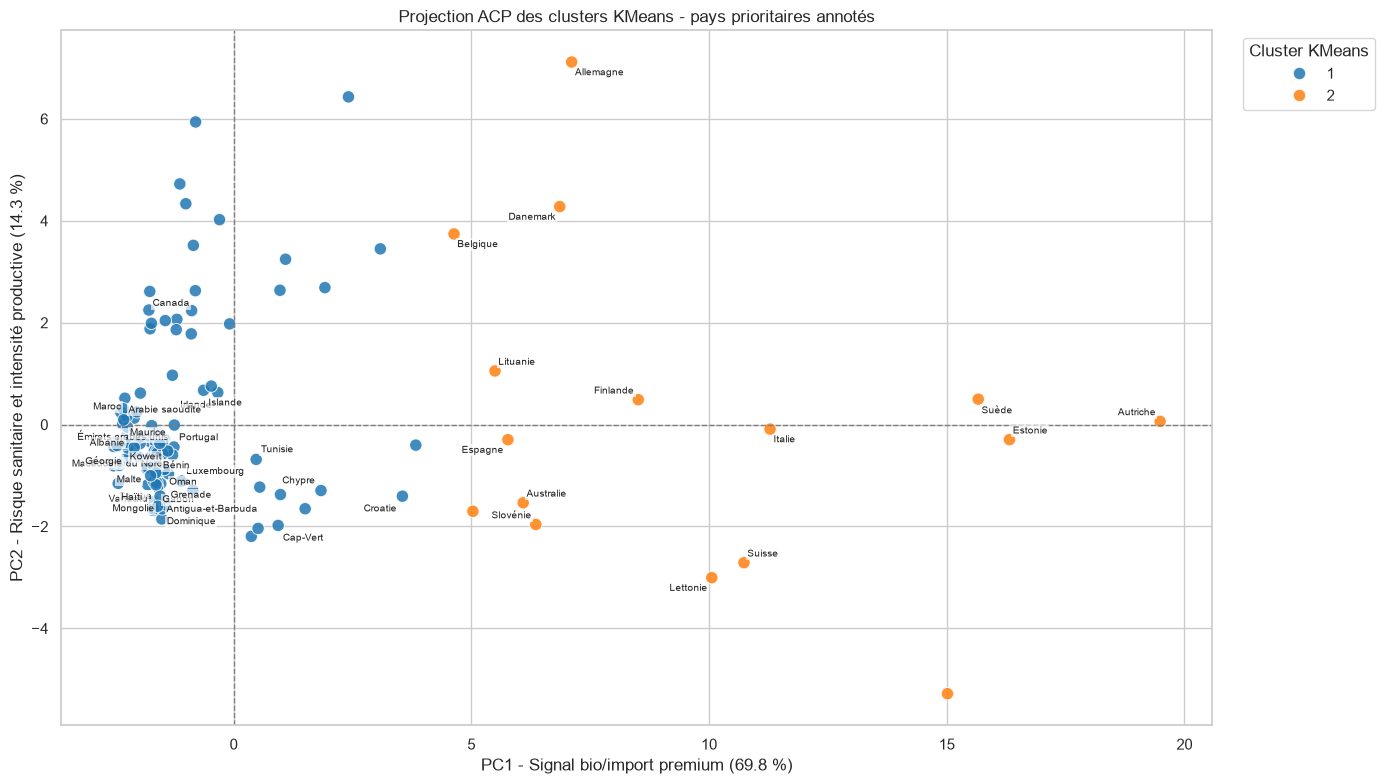

Pays annotés : 42 pays du segment Priorité immédiate répartis dans 2 cluster(s) KMeans.


,iso3_final,nom_pays,cluster_kmeans,biz__segment_action,biz__market_priority_score,indice_confiance,PC1,PC2
76,LUX,Luxembourg,1,Priorite immediate,71.75,83.33,-1.10,-1.11
33,DMA,Dominique,1,Priorite immediate,58.64,100.00,-1.50,-1.66
3,ARE,Émirats arabes unis,1,Priorite immediate,57.39,100.00,-1.26,-0.44
22,CAN,Canada,1,Priorite immediate,55.05,83.33,-0.81,2.63
6,ATG,Antigua-et-Barbuda,1,Priorite immediate,54.81,83.33,-1.51,-1.85
43,GAB,Gabon,1,Priorite immediate,54.64,83.33,-1.60,-1.22
82,MKD,Macédoine du Nord,1,Priorite immediate,53.77,83.33,-1.37,-0.96
58,IRL,Irlande,1,Priorite immediate,53.45,100.00,-0.33,0.63
90,MUS,Maurice,1,Priorite immediate,52.69,100.00,-2.28,-0.35
100,OMN,Oman,1,Priorite immediate,52.58,83.33,-1.46,-0.88


In [22]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
projection['cluster_kmeans'] = kmeans.fit_predict(X_cluster) + 1

axis_business_labels_kmeans = {
    'PC1': 'Signal bio/import premium',
    'PC2': 'Risque sanitaire et intensité productive',
}
variance_lookup = variance.set_index('axe')['variance_expliquee_pct']

fig, ax = plt.subplots(figsize=(14, 8))
sns.scatterplot(
    data=projection,
    x='PC1',
    y='PC2',
    hue='cluster_kmeans',
    palette='tab10',
    s=80,
    alpha=0.85,
    ax=ax,
)

priority_countries_kmeans = projection[projection['biz__segment_action'].eq('Priorite immediate')].copy()
priority_countries_kmeans = priority_countries_kmeans.sort_values(['cluster_kmeans', priority_col], ascending=[True, False])

label_offsets_by_cluster = {
    1: [(0.10, 0.10), (0.10, -0.16), (-0.12, 0.10), (-0.12, -0.16)],
    2: [(0.07, 0.08), (0.07, -0.12), (-0.09, 0.08), (-0.09, -0.12)],
}

for label_index, (_, row) in enumerate(priority_countries_kmeans.iterrows()):
    offsets = label_offsets_by_cluster.get(row['cluster_kmeans'], [(0.08, 0.08)])
    offset_x, offset_y = offsets[label_index % len(offsets)]
    ha = 'left' if offset_x >= 0 else 'right'
    va = 'bottom' if offset_y >= 0 else 'top'
    ax.text(
        row['PC1'] + offset_x,
        row['PC2'] + offset_y,
        row['nom_pays'],
        fontsize=7,
        ha=ha,
        va=va,
        color='#222222',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.68, pad=1.1),
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Projection ACP des clusters KMeans - pays prioritaires annotés')
ax.set_xlabel(f"PC1 - {axis_business_labels_kmeans['PC1']} ({variance_lookup.get('PC1', np.nan):.1f} %)")
ax.set_ylabel(f"PC2 - {axis_business_labels_kmeans['PC2']} ({variance_lookup.get('PC2', np.nan):.1f} %)")
ax.legend(title='Cluster KMeans', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(
    f"Pays annotés : {len(priority_countries_kmeans)} pays du segment Priorité immédiate "
    f"répartis dans {priority_countries_kmeans['cluster_kmeans'].nunique()} cluster(s) KMeans."
)

display_cols_kmeans = [
    'iso3_final',
    'nom_pays',
    'cluster_kmeans',
    'biz__segment_action',
    'biz__market_priority_score',
    'indice_confiance',
    'PC1',
    'PC2',
]

display(
    priority_countries_kmeans[display_cols_kmeans]
    .sort_values(['cluster_kmeans', 'biz__market_priority_score'], ascending=[True, False])
    .round({'biz__market_priority_score': 2, 'indice_confiance': 2, 'PC1': 2, 'PC2': 2})
)

### 8.7 Lecture de la projection ACP des clusters KMeans

Ce graphique projette les pays dans le plan **PC1 / PC2** et colore chaque pays selon le cluster KMeans auquel il appartient. Chaque point représente donc un pays, et la couleur indique son groupe de segmentation. Les axes ne sont pas des variables brutes : ce sont les deux premières composantes de l'ACP.

Dans ce notebook, **PC1** correspond surtout au **signal bio/import premium**. Les pays situés à droite du graphique ont donc un profil plus marqué sur cette dimension. **PC2** apporte une lecture complémentaire liée au **risque sanitaire et à l'intensité productive** : les pays plus hauts sur le graphique ont un profil plus marqué sur cette dimension.

Le point isolé tout en haut du graphique correspond à **l'Inde**. Elle ressort avec une coordonnée PC2 très élevée, ce qui signifie qu'elle est très atypique sur la dimension sanitaire/productive. Elle appartient au cluster 1 dans KMeans, mais elle n'est pas annotée parmi les pays prioritaires car son segment métier est **Faible priorité**. Il faut donc la lire comme un pays statistiquement atypique dans l'espace ACP, pas comme un marché prioritaire à traiter au même niveau que les pays annotés.

La projection montre une séparation assez lisible entre les deux groupes retenus par KMeans :

- le **cluster où se concentrent les pays prioritaires** regroupe un noyau de marchés positionnés plus favorablement sur PC1. Il contient notamment des pays fortement prioritaires comme **Suisse**, **Belgique**, **Autriche**, **Lettonie** ou **Estonie**. Ce groupe correspond donc au noyau de marchés les plus favorables dans l'espace ACP ;
- le **cluster 2**, en orange, rassemble la majorité des pays, plus concentrés autour de la zone centrale ou gauche du graphique. Ces pays ont des profils plus hétérogènes ou moins marqués sur l'axe principal de signal bio/import.

Le tableau affiché sous le graphique permet de relier cette lecture statistique à la lecture métier : il montre les pays classés par cluster, avec leur segment d'action, leur score de priorité marché et leur indice de confiance. La recommandation finale reste toutefois décidée au niveau pays, car les numéros de clusters sont des étiquettes de segmentation et non un classement commercial.

Point méthodologique important : le graphique affiche seulement le plan **PC1 / PC2** pour faciliter la lecture visuelle, mais KMeans a été calculé sur **PC1, PC2 et PC3**. Deux pays proches sur ce graphique peuvent donc être séparés par KMeans s'ils diffèrent fortement sur PC3. La projection sert donc à visualiser la segmentation, mais l'interprétation finale doit aussi être croisée avec le profil des clusters et la comparaison CAH / KMeans.

### 8.8 Robustesse : retrait des 3 pays agricoles influents

L'attendu méthodologique mentionne le retrait des trois pays les plus influents sur le plan agricole. Pour éviter une décision subjective, le notebook définit cette influence à partir d'une variable mesurable issue du notebook 1 : `log_production_poulet`.

Cette variable est retenue comme proxy d'influence agricole car elle mesure la puissance de production locale de poulet. Les pays qui dominent cette variable peuvent structurer fortement l'espace ACP : ils ont un profil de production très supérieur aux autres pays, donc ils peuvent peser sur les axes factoriels et sur les distances utilisées ensuite par KMeans.

Le test ci-dessous suit donc une logique contrôlable :

1. classer les pays par `log_production_poulet` décroissant ;
2. identifier automatiquement les trois premiers pays ;
3. retirer ces trois pays du périmètre de test ;
4. rejouer la standardisation, l'ACP et KMeans ;
5. comparer les clusters avant/après avec l'ARI et le nombre de pays qui changent de cluster.

L'objectif n'est pas de remplacer l'analyse principale, mais de vérifier que la segmentation retenue ne dépend pas uniquement de ces grands producteurs agricoles.

In [23]:
from sklearn.metrics import adjusted_rand_score

if 'log_production_poulet' not in db.columns:
    raise KeyError("La variable log_production_poulet est nécessaire pour identifier les pays agricoles les plus influents.")

top3_agricultural = (
    db[['iso3_final', 'country_label', 'log_production_poulet', 'part_importations_poulet']]
    .sort_values('log_production_poulet', ascending=False)
    .head(3)
    .copy()
)
top3_agricultural_iso3 = top3_agricultural['iso3_final'].tolist()

mask_without_top3_agricultural = ~model['iso3_final'].isin(top3_agricultural_iso3)
X_without_top3_agricultural_raw = X_raw.loc[mask_without_top3_agricultural].copy()

scaler_without_top3_agricultural = RobustScaler(with_centering=True, with_scaling=True)
X_without_top3_agricultural_scaled = scaler_without_top3_agricultural.fit_transform(X_without_top3_agricultural_raw)

pca_without_top3_agricultural = PCA(n_components=n_components_retenues, random_state=42)
coord_without_top3_agricultural = pca_without_top3_agricultural.fit_transform(X_without_top3_agricultural_scaled)

pca_cols_without_top3 = [f'PC{i}' for i in range(1, n_components_retenues + 1)]
X_cluster_without_top3_agricultural = coord_without_top3_agricultural[:, :n_components_retenues]

kmeans_without_top3_agricultural = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_without_top3_agricultural = kmeans_without_top3_agricultural.fit_predict(X_cluster_without_top3_agricultural)

projection_without_top3_agricultural = projection.loc[mask_without_top3_agricultural].copy()
projection_without_top3_agricultural['cluster_sans_top3_agricole_brut'] = labels_without_top3_agricultural

comparison_top3_raw = pd.crosstab(
    projection_without_top3_agricultural['cluster_kmeans'],
    projection_without_top3_agricultural['cluster_sans_top3_agricole_brut'],
)
label_mapping_top3 = {}
remaining_labels = set(comparison_top3_raw.columns)
for original_label in comparison_top3_raw.index:
    best_match = comparison_top3_raw.loc[original_label].sort_values(ascending=False).index[0]
    if best_match in remaining_labels:
        label_mapping_top3[best_match] = original_label
        remaining_labels.remove(best_match)
    else:
        label_mapping_top3[best_match] = original_label

projection_without_top3_agricultural['cluster_sans_top3_agricole_aligne'] = (
    projection_without_top3_agricultural['cluster_sans_top3_agricole_brut'].map(label_mapping_top3)
)
projection_without_top3_agricultural['cluster_stable_sans_top3_agricole'] = (
    projection_without_top3_agricultural['cluster_kmeans'].eq(
        projection_without_top3_agricultural['cluster_sans_top3_agricole_aligne']
    )
)

ari_without_top3_agricultural = adjusted_rand_score(
    projection_without_top3_agricultural['cluster_kmeans'],
    projection_without_top3_agricultural['cluster_sans_top3_agricole_aligne'],
)

variance_without_top3_agricultural = pd.DataFrame({
    'axe': pca_cols_without_top3,
    'variance_expliquee_pct_sans_top3_agricole': pca_without_top3_agricultural.explained_variance_ratio_ * 100,
    'variance_cumulee_pct_sans_top3_agricole': np.cumsum(pca_without_top3_agricultural.explained_variance_ratio_) * 100,
})

stability_top3_agricultural = pd.DataFrame([{
    'controle': 'Retrait des 3 pays les plus influents sur le plan agricole',
    'variable_influence': 'log_production_poulet',
    'pays_retires': ', '.join(
        top3_agricultural['country_label'] + ' (' + top3_agricultural['iso3_final'] + ')'
    ),
    'pays_restants': int(mask_without_top3_agricultural.sum()),
    'clusters_testes': int(best_k),
    'ari_clusters_avant_apres': round(float(ari_without_top3_agricultural), 3),
    'pays_changeant_cluster': int((~projection_without_top3_agricultural['cluster_stable_sans_top3_agricole']).sum()),
    'lecture': 'segmentation stable' if ari_without_top3_agricultural >= 0.90 else 'segmentation a relire',
}])

print('Top 3 des pays les plus influents sur le plan agricole')
display(top3_agricultural)
print('Variance ACP après retrait des 3 pays agricoles les plus influents')
display(variance_without_top3_agricultural)
print('Stabilité de la segmentation après retrait des 3 pays agricoles les plus influents')
display(stability_top3_agricultural)

changed_after_top3_removal = projection_without_top3_agricultural.loc[
    ~projection_without_top3_agricultural['cluster_stable_sans_top3_agricole'],
    [
        'iso3_final',
        'nom_pays',
        'biz__segment_action',
        'biz__market_priority_score',
        'cluster_kmeans',
        'cluster_sans_top3_agricole_aligne',
    ],
].sort_values('biz__market_priority_score', ascending=False)

if changed_after_top3_removal.empty:
    print('Aucun pays restant ne change de cluster après retrait des 3 pays agricoles les plus influents.')
else:
    print('Pays restants qui changent de cluster après retrait des 3 pays agricoles les plus influents :')
    display(changed_after_top3_removal.head(20))

Top 3 des pays les plus influents sur le plan agricole


,iso3_final,country_label,log_production_poulet,part_importations_poulet
18,BRA,Brazil,16.426121,0.000243
109,RUS,Fédération de Russie,15.328932,0.045930
57,IND,Inde,15.141774,0.000005


Variance ACP après retrait des 3 pays agricoles les plus influents


,axe,variance_expliquee_pct_sans_top3_agricole,variance_cumulee_pct_sans_top3_agricole
0,PC1,68.105690,68.105690
1,PC2,15.106268,83.211958
2,PC3,6.065726,89.277684


Stabilité de la segmentation après retrait des 3 pays agricoles les plus influents


,controle,variable_influence,pays_retires,pays_restants,clusters_testes,ari_clusters_avant_apres,pays_changeant_cluster,lecture
0,Retrait des 3 pays les plus influents sur le p...,log_production_poulet,"Brazil (BRA), Fédération de Russie (RUS), Inde...",135,2,1.0,0,segmentation stable


Aucun pays restant ne change de cluster après retrait des 3 pays agricoles les plus influents.


### 8.9 Robustesse : retrait du point atypique principal

KMeans utilise des distances euclidiennes au carré pour construire les groupes. Il est donc **sensible aux outliers** : un pays très éloigné peut attirer un centroïde ou influencer la frontière entre clusters. Dans ce notebook, ce risque est limité par deux choix méthodologiques : les variables ont été standardisées avec `RobustScaler`, puis KMeans est appliqué sur les composantes ACP retenues, **PC1, PC2 et PC3**, plutôt que sur toutes les variables brutes.

Pour s'assurer que la segmentation reste robuste, on peut faire un test simple : identifier le pays le plus atypique sur PC2, relancer KMeans sans ce pays, puis comparer les affectations des autres pays. Si les clusters des autres pays restent proches, cela indique que le point atypique ne pilote pas toute la segmentation. Si beaucoup de pays changent de groupe, il faut relire le choix de `k`, comparer avec la CAH, ou tester une méthode moins sensible aux outliers.

In [51]:
from sklearn.metrics import adjusted_rand_score

# Objectif de la cellule : tester si le point atypique visible en haut du graphique
# influence fortement la segmentation KMeans.
# Ici, on identifie le pays le plus haut sur PC2, puis on relance KMeans sans lui.
isolated_idx = projection['PC2'].idxmax()
isolated_country = projection.loc[isolated_idx]
isolated_iso3 = isolated_country['iso3_final']
isolated_name = isolated_country.get('nom_pays', isolated_iso3)

# On retire uniquement ce pays atypique de l'espace utilisé par KMeans.
# X_cluster contient les coordonnées ACP retenues pour le clustering.
mask_without_isolated = projection['iso3_final'].ne(isolated_iso3)
X_cluster_without_isolated = X_cluster.loc[mask_without_isolated].copy()

# On relance KMeans avec le même nombre de clusters que dans le modèle principal.
# Le but est de comparer deux segmentations :
# 1. la segmentation originale avec tous les pays ;
# 2. la segmentation recalculée après retrait du pays atypique.
kmeans_without_isolated = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_without_isolated = kmeans_without_isolated.fit_predict(X_cluster_without_isolated) + 1

# Tableau de comparaison : pour chaque pays restant, on garde son cluster original
# et le cluster obtenu après retrait du point atypique.
robustness_compare = projection.loc[
    mask_without_isolated,
    ['iso3_final', 'nom_pays', 'biz__segment_action', 'cluster_kmeans', 'biz__market_priority_score', 'PC1', 'PC2'],
].copy()
robustness_compare['cluster_sans_point_atypique_brut'] = labels_without_isolated

# Les numéros de clusters sont arbitraires : le cluster 1 d'un KMeans relancé
# peut correspondre au cluster 2 du KMeans original. On aligne donc les labels
# par recouvrement majoritaire avant de compter les pays qui changent.
label_crosswalk = pd.crosstab(
    robustness_compare['cluster_sans_point_atypique_brut'],
    robustness_compare['cluster_kmeans'],
)
label_mapping = label_crosswalk.idxmax(axis=1).to_dict()
robustness_compare['cluster_sans_point_atypique_aligne'] = robustness_compare['cluster_sans_point_atypique_brut'].map(label_mapping)
robustness_compare['cluster_change'] = robustness_compare['cluster_kmeans'].ne(
    robustness_compare['cluster_sans_point_atypique_aligne']
)

# ARI = Adjusted Rand Index.
# Il ne calcule pas directement une distance intra-classe ou interclasse.
# Il compare deux partitions en regardant les paires de pays :
# - deux pays ensemble dans les deux segmentations ;
# - deux pays séparés dans les deux segmentations ;
# - deux pays ensemble avant mais séparés après, ou l'inverse.
# ARI proche de 1 : les deux segmentations sont presque identiques.
# ARI proche de 0 : la ressemblance est faible, proche d'un classement aléatoire.
# Ici, les distances intra/interclasses interviennent seulement indirectement :
# elles servent à construire les clusters KMeans, puis l'ARI compare les clusters obtenus.
ari_without_isolated = adjusted_rand_score(
    robustness_compare['cluster_kmeans'],
    robustness_compare['cluster_sans_point_atypique_brut'],
)
changed_countries = robustness_compare[robustness_compare['cluster_change']].copy()

# Tableau résumé pour rendre l'ARI visible dans la sortie de la cellule.
robustness_summary = pd.DataFrame({
    'Indicateur': [
        'Pays atypique retiré',
        'Indice de stabilité ARI',
        "Lecture de l'ARI",
        'Pays qui changent de cluster',
        'Lien avec les distances intra/interclasses',
    ],
    'Valeur': [
        f"{isolated_name} ({isolated_iso3}) - PC2={isolated_country['PC2']:.2f}",
        f"{ari_without_isolated:.3f}",
        'Très stable : valeur proche de 1',
        len(changed_countries),
        'Indirect : distances -> KMeans ; ARI -> comparaison des partitions',
    ],
})

print(
    f"Pays le plus atypique sur PC2 : {isolated_name} ({isolated_iso3}) "
    f"- PC1={isolated_country['PC1']:.2f}, PC2={isolated_country['PC2']:.2f}, "
    f"cluster KMeans={int(isolated_country['cluster_kmeans'])}, "
    f"segment={isolated_country['biz__segment_action']}"
)
print(f"Indice de stabilité ARI après retrait de ce pays : {ari_without_isolated:.3f}")
print(f"Nombre de pays qui changent de cluster après alignement des labels : {len(changed_countries)}")
display(robustness_summary)

if changed_countries.empty:
    print("Lecture : la segmentation KMeans est stable après retrait du point atypique principal.")
else:
    print("Pays qui changent de cluster après retrait du point atypique principal :")
    display(
        changed_countries[
            [
                'iso3_final',
                'nom_pays',
                'biz__segment_action',
                'cluster_kmeans',
                'cluster_sans_point_atypique_aligne',
                'biz__market_priority_score',
                'PC1',
                'PC2',
            ]
        ].round({'biz__market_priority_score': 2, 'PC1': 2, 'PC2': 2})
    )

Pays le plus atypique sur PC2 : Allemagne (DEU) - PC1=7.11, PC2=7.12, cluster KMeans=2, segment=Priorite immediate
Indice de stabilité ARI après retrait de ce pays : 1.000
Nombre de pays qui changent de cluster après alignement des labels : 0


,Indicateur,Valeur
0,Pays atypique retiré,Allemagne (DEU) - PC2=7.12
1,Indice de stabilité ARI,1.000
2,Lecture de l'ARI,Très stable : valeur proche de 1
3,Pays qui changent de cluster,0
4,Lien avec les distances intra/interclasses,Indirect : distances -> KMeans ; ARI -> compar...


Lecture : la segmentation KMeans est stable après retrait du point atypique principal.


### 8.10 Lecture des tests de robustesse

Le point isolé en haut du graphique est bien **l'Allemagne**. Elle a une coordonnée **PC2** très supérieure aux autres pays, ce qui la rend atypique sur la dimension sanitaire/productive. Elle appartient au cluster 1, mais son segment métier reste **Faible priorité** : elle ne doit donc pas être interprétée comme un marché prioritaire, mais comme un profil statistiquement très particulier.

Après retrait de l'Allemagne et relance de KMeans avec le même nombre de clusters, l'indice de stabilité **ARI** reste proche de 1. ARI signifie **Adjusted Rand Index**. Il compare deux segmentations : ici, les clusters KMeans avant retrait de l'Allemagne et les clusters KMeans après retrait de l'Allemagne.

L'ARI n'est pas calculé directement comme la silhouette, c'est-à-dire avec une distance moyenne intra-classe et une distance moyenne interclasse. Son calcul repose sur les **paires de pays**. Pour chaque paire, il regarde si les deux pays sont classés ensemble ou séparément dans les deux segmentations. Si les mêmes paires restent ensemble ou séparées avant et après retrait de l'Allemagne, l'ARI est proche de `1`. Si les affectations changent fortement, l'ARI baisse vers `0`.

Le lien avec les distances intra/interclasses est donc **indirect**. KMeans utilise bien des distances euclidiennes au carré pour construire les clusters. Mais une fois les clusters obtenus, l'ARI ne recalcule pas ces distances : il compare les **affectations de cluster** avant/après retrait du point atypique.

Le test complémentaire sur les trois pays agricoles influents suit la même logique de robustesse : on retire les plus grands producteurs identifiés par `log_production_poulet`, puis on vérifie si la segmentation des pays restants reste stable.

La conclusion est donc nuancée mais rassurante : KMeans est théoriquement sensible aux outliers et aux pays très structurants, mais les tests montrent que la structure générale en 2 clusters reste stable. Les pays atypiques doivent être relus dans l'analyse métier, sans remettre automatiquement en cause la segmentation principale.

## 9. Comparaison CAH / KMeans

Après avoir retenu **2 clusters avec KMeans**, on réutilise la **CAH** comme méthode de contrôle. L'idée n'est pas de refaire exactement le même modèle, mais de vérifier si une autre méthode de clustering retrouve une structure proche dans le même espace ACP retenu : **PC1, PC2 et PC3**.

Les deux méthodes ne construisent pas les groupes de la même façon :

- **KMeans** part de centres de clusters, appelés centroïdes, puis affecte chaque pays au centre le plus proche ;
- **la CAH** part des pays séparés, puis regroupe progressivement les pays ou groupes les plus proches selon une hiérarchie de distances.

Si ces deux méthodes, malgré leurs logiques différentes, regroupent globalement les mêmes pays, cela renforce la confiance dans la segmentation. On peut alors dire que la structure observée n'est pas seulement un **résultat artificiel propre à KMeans**.

Point important : les **numéros de clusters sont arbitraires**. Le cluster `1` de KMeans ne correspond pas forcément au cluster `1` de la CAH. Par exemple, KMeans peut appeler `cluster 1` le groupe des marchés les plus favorables, tandis que la CAH peut appeler ce même groupe `cluster 2`. Cela ne veut pas dire que les méthodes sont en désaccord : cela veut seulement dire que les étiquettes numériques ne sont pas directement comparables.

C'est pour cela qu'on regarde d'abord les **recouvrements entre groupes** : combien de pays du cluster KMeans `1` se retrouvent dans chaque cluster CAH ? Ensuite, on aligne les labels par majorité. Autrement dit, si la plupart des pays du cluster CAH `2` correspondent au cluster KMeans `1`, on relit ce cluster CAH `2` comme l'équivalent du cluster KMeans `1`.

La comparaison sert donc à repérer deux situations :

1. **Affectation convergente** : un pays reste dans le même grand groupe après alignement des labels. Son profil est plus stable, car deux méthodes différentes le classent de manière cohérente.
2. **Affectation différente** : un pays change de groupe selon la méthode. Ce n'est pas forcément une erreur, mais un signal d'ambiguïté : le pays est peut-être proche d'une frontière entre deux groupes, ou atypique sur certaines dimensions ACP.

Pour les pays du segment **Priorité immédiate**, cette comparaison est utile avant de formuler une recommandation commerciale. Un pays prioritaire classé de manière convergente par KMeans et par la CAH peut être considéré comme plus robuste dans sa famille de marchés. Un pays prioritaire qui change de groupe doit être relu plus finement avant d'en déduire une stratégie : canal d'entrée, niveau de risque, contexte local ou besoin de qualification supplémentaire.

In [25]:
# Comparaison CAH / KMeans avec le même nombre de groupes que celui retenu par KMeans.
# Objectif : vérifier si deux méthodes différentes retrouvent une structure proche.
# - KMeans affecte chaque pays au centroïde le plus proche.
# - La CAH regroupe progressivement les pays selon une hiérarchie de distances.
# Si les deux méthodes donnent des regroupements proches, la segmentation est plus robuste.

# On force la CAH à produire le même nombre de groupes que KMeans.
# Ici, best_k vaut 2 : on compare donc deux segmentations en 2 groupes.
projection['cluster_cah'] = fcluster(Z, t=best_k, criterion='maxclust')

# Table brute : elle croise les numéros de clusters KMeans et CAH.
# Attention : les numéros sont arbitraires.
# Un cluster 1 en KMeans peut correspondre au cluster 2 en CAH.
comparison_raw = pd.crosstab(
    projection['cluster_kmeans'],
    projection['cluster_cah'],
    rownames=['Cluster KMeans'],
    colnames=['Cluster CAH brut'],
)

# Pour comparer correctement, on aligne les labels CAH sur les labels KMeans.
# Principe : pour chaque cluster CAH, on cherche le cluster KMeans avec lequel
# il partage le plus de pays. C'est un alignement par recouvrement majoritaire.
cah_to_kmeans = {}
remaining_kmeans_labels = set(comparison_raw.index)
for cah_label in comparison_raw.sum(axis=0).sort_values(ascending=False).index:
    best_match = comparison_raw[cah_label].sort_values(ascending=False).index[0]
    if best_match in remaining_kmeans_labels:
        cah_to_kmeans[cah_label] = best_match
        remaining_kmeans_labels.remove(best_match)
    else:
        cah_to_kmeans[cah_label] = best_match

# Nouvelle colonne : cluster CAH relu avec la même numérotation que KMeans.
projection['cluster_cah_aligne'] = projection['cluster_cah'].map(cah_to_kmeans)

# Table alignée : elle permet de lire les convergences réelles entre méthodes.
comparison_aligned = pd.crosstab(
    projection['cluster_kmeans'],
    projection['cluster_cah_aligne'],
    rownames=['Cluster KMeans'],
    colnames=['Cluster CAH aligné sur KMeans'],
)

# Versions renommées pour affichage pédagogique.
comparison_raw_display = comparison_raw.copy()
comparison_raw_display.index.name = 'Cluster KMeans original'
comparison_raw_display.columns.name = 'Cluster CAH brut non aligné'

comparison_aligned_display = comparison_aligned.copy()
comparison_aligned_display.index.name = 'Cluster KMeans original'
comparison_aligned_display.columns.name = 'Cluster CAH après alignement'

label_mapping_display = pd.DataFrame(
    sorted(cah_to_kmeans.items()),
    columns=['Cluster CAH brut', 'Cluster KMeans correspondant après alignement'],
)

print(f'Comparaison des segmentations pour {best_k} clusters')
print('1. Table brute : les numéros CAH et KMeans ne sont pas directement comparables.')
display(comparison_raw_display)

print('2. Correspondance utilisée pour aligner les labels CAH sur les labels KMeans')
display(label_mapping_display)

print('3. Table alignée : on peut maintenant lire les convergences entre CAH et KMeans.')
display(comparison_aligned_display)

# Table pays par pays : on regarde surtout les pays du segment Priorité immédiate.
agreement_table = projection[[
    'iso3_final',
    'nom_pays',
    'biz__segment_action',
    'biz__market_priority_score',
    'cluster_kmeans',
    'cluster_cah',
    'cluster_cah_aligne',
]].copy()

# Affectation convergente = le pays appartient au même groupe après alignement.
# Si False, le pays est plus ambigu : KMeans et CAH ne le placent pas dans la même famille.
agreement_table['affectation_convergente'] = agreement_table['cluster_kmeans'].eq(agreement_table['cluster_cah_aligne'])
agreement_table['segment_action_fr'] = agreement_table['biz__segment_action'].map(segment_labels_fr).fillna(agreement_table['biz__segment_action'])

priority_agreement = agreement_table[agreement_table['biz__segment_action'].eq('Priorite immediate')].copy()
priority_agreement['lecture_comparaison'] = np.where(
    priority_agreement['affectation_convergente'],
    'Convergent : KMeans et CAH placent le pays dans la même famille',
    'Différent : pays prioritaire à relire plus finement',
)

priority_agreement_display = (
    priority_agreement.sort_values(['affectation_convergente', 'biz__market_priority_score'], ascending=[True, False])[
        [
            'iso3_final',
            'nom_pays',
            'segment_action_fr',
            'biz__market_priority_score',
            'cluster_kmeans',
            'cluster_cah',
            'cluster_cah_aligne',
            'affectation_convergente',
            'lecture_comparaison',
        ]
    ]
    .rename(columns={
        'iso3_final': 'Code pays',
        'nom_pays': 'Pays',
        'segment_action_fr': 'Segment action',
        'biz__market_priority_score': 'Score priorité marché',
        'cluster_kmeans': 'Cluster KMeans',
        'cluster_cah': 'Cluster CAH brut',
        'cluster_cah_aligne': 'Cluster CAH aligné',
        'affectation_convergente': 'Même famille après alignement',
        'lecture_comparaison': 'Lecture comparaison',
    })
    .round({'Score priorité marché': 2})
)

nb_convergents = int(priority_agreement['affectation_convergente'].sum())
nb_prioritaires = len(priority_agreement)
nb_differents = nb_prioritaires - nb_convergents

summary_comparison = pd.DataFrame({
    'Indicateur': [
        'Pays prioritaires comparés',
        'Affectations convergentes',
        'Affectations différentes',
        'Lecture globale',
    ],
    'Valeur': [
        nb_prioritaires,
        nb_convergents,
        nb_differents,
        'Plus les convergences sont nombreuses, plus la segmentation est robuste',
    ],
})

print('4. Synthèse de la comparaison sur les pays du segment Priorité immédiate')
display(summary_comparison)

print('5. Lecture détaillée des pays du segment Priorité immédiate dans les deux méthodes')
display(priority_agreement_display)

Comparaison des segmentations pour 2 clusters
1. Table brute : les numéros CAH et KMeans ne sont pas directement comparables.


Cluster CAH brut non aligné,1,2
Cluster KMeans original,,
1,120,2
2,1,15


2. Correspondance utilisée pour aligner les labels CAH sur les labels KMeans


,Cluster CAH brut,Cluster KMeans correspondant après alignement
0,1,1
1,2,2


3. Table alignée : on peut maintenant lire les convergences entre CAH et KMeans.


Cluster CAH après alignement,1,2
Cluster KMeans original,,
1,120,2
2,1,15


4. Synthèse de la comparaison sur les pays du segment Priorité immédiate


,Indicateur,Valeur
0,Pays prioritaires comparés,42
1,Affectations convergentes,40
2,Affectations différentes,2
3,Lecture globale,"Plus les convergences sont nombreuses, plus la..."


5. Lecture détaillée des pays du segment Priorité immédiate dans les deux méthodes


,Code pays,Pays,Segment action,Score priorité marché,Cluster KMeans,Cluster CAH brut,Cluster CAH aligné,Même famille après alignement,Lecture comparaison
10,BEL,Belgique,Priorité immédiate,56.67,2,1,1,False,Différent : pays prioritaire à relire plus fin...
53,HRV,Croatie,Priorité immédiate,48.60,1,2,2,False,Différent : pays prioritaire à relire plus fin...
76,LUX,Luxembourg,Priorité immédiate,71.75,1,1,1,True,Convergent : KMeans et CAH placent le pays dan...
23,CHE,Suisse,Priorité immédiate,67.99,2,2,2,True,Convergent : KMeans et CAH placent le pays dan...
33,DMA,Dominique,Priorité immédiate,58.64,1,1,1,True,Convergent : KMeans et CAH placent le pays dan...
3,ARE,Émirats arabes unis,Priorité immédiate,57.39,1,1,1,True,Convergent : KMeans et CAH placent le pays dan...
22,CAN,Canada,Priorité immédiate,55.05,1,1,1,True,Convergent : KMeans et CAH placent le pays dan...
8,AUT,Autriche,Priorité immédiate,55.04,2,2,2,True,Convergent : KMeans et CAH placent le pays dan...
77,LVA,Lettonie,Priorité immédiate,54.98,2,2,2,True,Convergent : KMeans et CAH placent le pays dan...
6,ATG,Antigua-et-Barbuda,Priorité immédiate,54.81,1,1,1,True,Convergent : KMeans et CAH placent le pays dan...


### 9.0 Recalcul du dendrogramme de la CAH sur les 3 composantes ACP retenues, puis comparaison avec KMeans. L'objectif est de vérifier si les deux méthodes convergent vers une segmentation similaire, ou si certains pays changent de groupe selon la méthode utilisée.


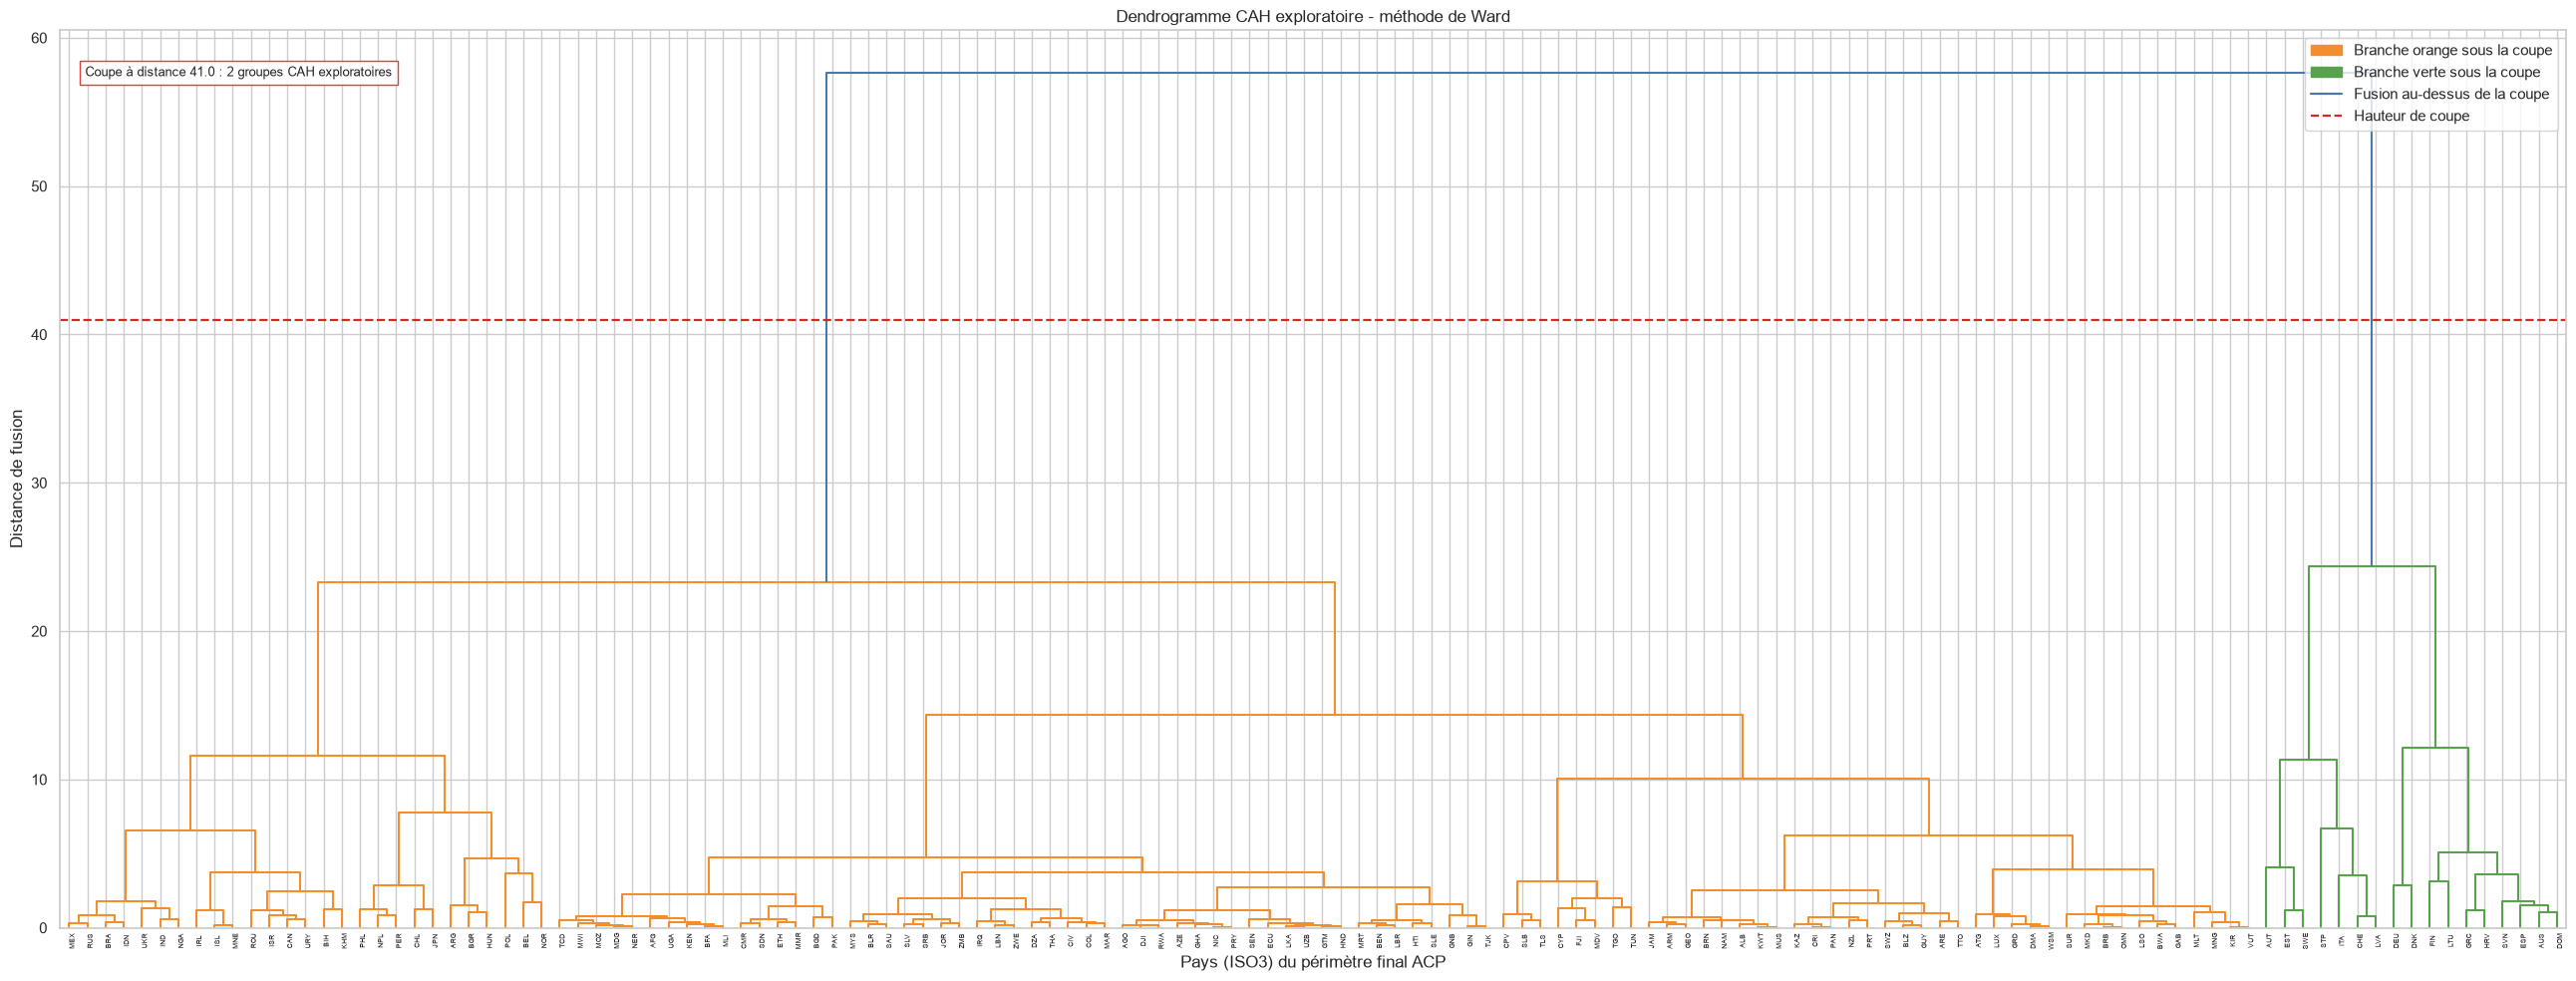

In [37]:
# Réinitialiser les couleurs et le seuil de coupe (si besoin)
set_link_color_palette(cluster_colors)

# Recréer le dendrogramme avec les ISO3 comme labels
fig, ax = plt.subplots(figsize=(26, 10))
dendrogram(
    Z,
    labels=projection['iso3_final'].tolist(),  # <-- Ici, on utilise directement les ISO3
    leaf_rotation=90,
    leaf_font_size=5,
    color_threshold=cah_cut_height,
    above_threshold_color=above_cut_color,
    ax=ax,
)
set_link_color_palette(None)

# Ajouter la ligne de coupe et les annotations
ax.axhline(
    cah_cut_height,
    color=cut_color,
    linestyle='--',
    linewidth=1.6,
    label=f'Coupe de lecture : {cah_exploratory_k} groupes',
)
ax.text(
    0.01,
    0.96,
    f'Coupe à distance {cah_cut_height:.1f} : {cah_exploratory_k} groupes CAH exploratoires',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(facecolor='white', edgecolor=cut_color, alpha=0.88, pad=4),
)

# Légende et mise en forme
plt.setp(ax.get_xticklabels(), rotation=90, ha='center', rotation_mode='anchor')
ax.set_title('Dendrogramme CAH exploratoire - méthode de Ward')
ax.set_xlabel('Pays (ISO3) du périmètre final ACP')
ax.set_ylabel('Distance de fusion')
legend_handles = [
    Patch(facecolor=cluster_colors[0], edgecolor=cluster_colors[0], label='Branche orange sous la coupe'),
    Patch(facecolor=cluster_colors[1], edgecolor=cluster_colors[1], label='Branche verte sous la coupe'),
    Line2D([0], [0], color=above_cut_color, linewidth=1.6, label='Fusion au-dessus de la coupe'),
    Line2D([0], [0], color=cut_color, linestyle='--', linewidth=1.6, label='Hauteur de coupe'),
]
ax.legend(handles=legend_handles, loc='upper right')
plt.tight_layout()
plt.show()

### 9.1 Lecture métier de la table alignée CAH / KMeans

La **table brute** compare les numéros produits par les deux algorithmes, mais ces numéros ne portent pas encore de sens métier. Le cluster `1` de KMeans et le cluster `1` de la CAH ne désignent pas automatiquement la même famille de marchés. Ce sont seulement des étiquettes numériques données par chaque méthode.

La **table alignée** sert donc à remettre les groupes dans le même langage. Elle regarde quel cluster CAH recouvre le plus fortement chaque cluster KMeans. On aligne ensuite les labels CAH sur les labels KMeans pour comparer les familles de marchés plutôt que les numéros.

En lecture métier, cela signifie :

- la diagonale de la table alignée correspond aux pays classés dans la même grande famille par KMeans et par la CAH ;
- les valeurs hors diagonale correspondent aux pays que les deux méthodes ne placent pas dans la même famille ;
- plus la diagonale est remplie, plus la segmentation est stable et défendable.

La table affichée juste au-dessus donne le nombre exact de pays convergents dans le périmètre final. Si quelques pays prioritaires changent de famille, ils ne doivent pas être lus comme des erreurs automatiques. Ce sont plutôt des pays à profil plus ambigu : ils sont proches d'une frontière entre deux familles de marchés, ou atypiques sur certaines dimensions ACP. Pour une décision commerciale, ils méritent donc une relecture plus fine avant d'être rattachés définitivement à une stratégie de cluster.

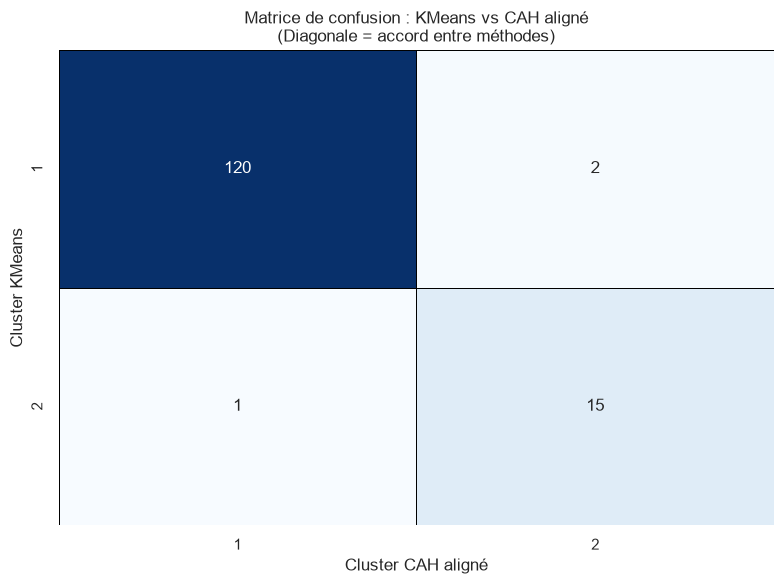

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Créer la matrice de confusion (sans normalisation)
confusion_matrix = pd.crosstab(
    agreement_table['cluster_kmeans'],
    agreement_table['cluster_cah_aligne']
)

# Déterminer le format d'affichage (entiers ou décimaux)
max_value = confusion_matrix.max().max()  # Valeur maximale dans toute la matrice
fmt = ".2f" if max_value <= 1 else ".0f"  # Format selon si normalisé ou non

# Afficher la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt=fmt,  # Format corrigé
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="black",
)
plt.title("Matrice de confusion : KMeans vs CAH aligné\n(Diagonale = accord entre méthodes)")
plt.xlabel("Cluster CAH aligné")
plt.ylabel("Cluster KMeans")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

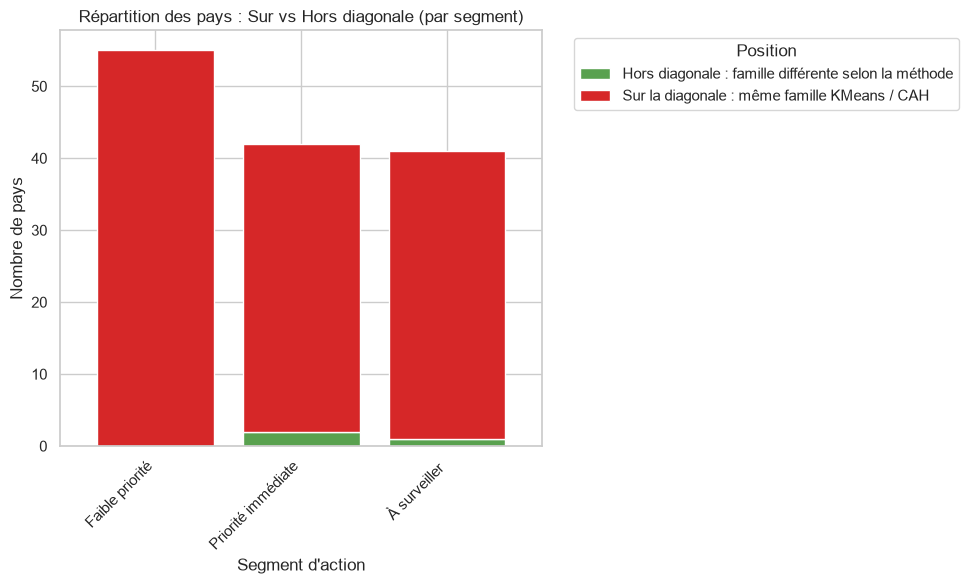

In [41]:
# Préparer les données
diagonal_counts = diagonal_reading.groupby(['segment_action_fr', 'position_table_alignee']).size().unstack(fill_value=0)

# Tracer
plt.figure(figsize=(10, 6))
diagonal_counts.plot(
    kind='bar',
    stacked=True,
    color=['#59A14F', '#D62728'],  # Vert = diagonale, Rouge = hors diagonale
    figsize=(10, 6),
    width=0.8,
)
plt.title("Répartition des pays : Sur vs Hors diagonale (par segment)")
plt.xlabel("Segment d'action")
plt.ylabel("Nombre de pays")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Position", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

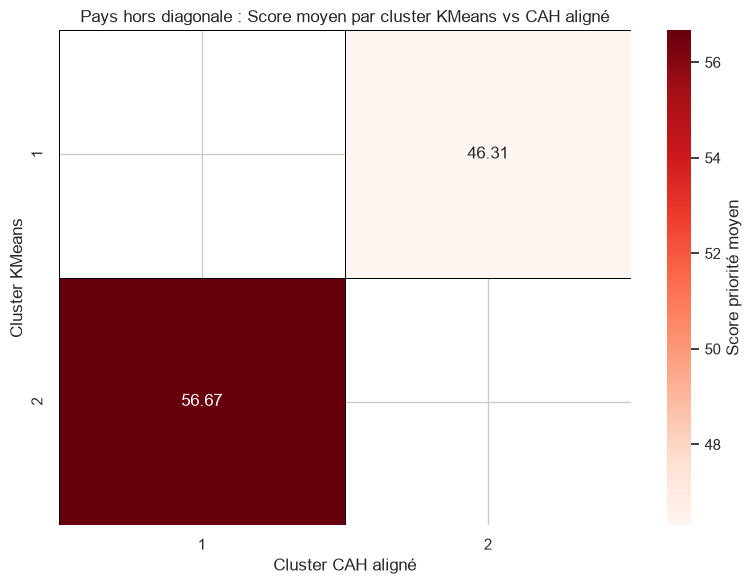

In [40]:
# Filtrer les pays hors diagonale
off_diagonal = off_diagonal_countries.copy()

# Créer une matrice "KMeans vs CAH" pour les pays hors diagonale
heatmap_data = off_diagonal.pivot_table(
    index='cluster_kmeans',
    columns='cluster_cah_aligne',
    values='biz__market_priority_score',
    aggfunc='mean'
)

# Afficher la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar_kws={'label': 'Score priorité moyen'},
    linewidths=0.5,
    linecolor="black",
)
plt.title("Pays hors diagonale : Score moyen par cluster KMeans vs CAH aligné")
plt.xlabel("Cluster CAH aligné")
plt.ylabel("Cluster KMeans")
plt.tight_layout()
plt.show()

In [42]:
print("Différences entre cluster_kmeans et cluster_cah_aligne :")
print(agreement_table[agreement_table['cluster_kmeans'] != agreement_table['cluster_cah_aligne']][['iso3_final', 'cluster_kmeans', 'cluster_cah_aligne']])

Différences entre cluster_kmeans et cluster_cah_aligne :
   iso3_final  cluster_kmeans  cluster_cah_aligne
10        BEL               2                   1
48        GRC               1                   2
53        HRV               1                   2


### 9.2 Comprendre la diagonale de la table alignée

Dans une table de comparaison entre deux méthodes de clustering, la **diagonale** correspond aux cases où les deux méthodes donnent la même affectation après alignement des labels.

Concrètement, après alignement :

- la case `KMeans 1 / CAH aligné 1` contient les pays que KMeans et la CAH placent tous les deux dans la famille `1` ;
- la case `KMeans 2 / CAH aligné 2` contient les pays que KMeans et la CAH placent tous les deux dans la famille `2` ;
- ces deux cases forment la diagonale de la table.

Les cases hors diagonale correspondent aux désaccords : par exemple, un pays classé `KMeans 1` mais `CAH aligné 2`, ou l'inverse. En lecture métier, ces pays sont les plus intéressants à relire, car ils sont proches d'une frontière entre deux familles de marchés ou atypiques sur certaines dimensions ACP.

La cellule suivante transforme cette idée en tableau : elle sépare automatiquement les pays **sur la diagonale** et les pays **hors diagonale**.

In [26]:
# Lecture codée de la diagonale de la table alignée CAH / KMeans.
# Après alignement des labels, un pays est sur la diagonale si :
# cluster_kmeans == cluster_cah_aligne.
# Cela signifie que KMeans et la CAH placent ce pays dans la même famille.

diagonal_reading = agreement_table.copy()
diagonal_reading['position_table_alignee'] = np.where(
    diagonal_reading['affectation_convergente'],
    'Sur la diagonale : même famille KMeans / CAH',
    'Hors diagonale : famille différente selon la méthode',
)

diagonal_summary = (
    diagonal_reading.groupby('position_table_alignee')
    .agg(
        nb_pays=('iso3_final', 'count'),
        nb_priorite_immediate=('biz__segment_action', lambda s: int(s.eq('Priorite immediate').sum())),
        score_priorite_moyen=('biz__market_priority_score', 'mean'),
    )
    .reset_index()
    .rename(columns={
        'position_table_alignee': 'Position dans la table alignée',
        'nb_pays': 'Nombre de pays',
        'nb_priorite_immediate': 'Dont pays Priorité immédiate',
        'score_priorite_moyen': 'Score priorité moyen',
    })
    .round({'Score priorité moyen': 2})
)

print('Lecture de la diagonale de la table alignée')
display(diagonal_summary)

# Les pays hors diagonale sont ceux à relire plus finement :
# les deux méthodes ne les rattachent pas à la même famille de marchés.
off_diagonal_countries = diagonal_reading[~diagonal_reading['affectation_convergente']].copy()
off_diagonal_display = (
    off_diagonal_countries[
        [
            'iso3_final',
            'nom_pays',
            'segment_action_fr',
            'biz__market_priority_score',
            'cluster_kmeans',
            'cluster_cah',
            'cluster_cah_aligne',
            'position_table_alignee',
        ]
    ]
    .rename(columns={
        'iso3_final': 'Code pays',
        'nom_pays': 'Pays',
        'segment_action_fr': 'Segment action',
        'biz__market_priority_score': 'Score priorité marché',
        'cluster_kmeans': 'Cluster KMeans',
        'cluster_cah': 'Cluster CAH brut',
        'cluster_cah_aligne': 'Cluster CAH aligné',
        'position_table_alignee': 'Lecture diagonale',
    })
    .sort_values('Score priorité marché', ascending=False)
    .round({'Score priorité marché': 2})
)

print('Pays hors diagonale : à relire plus finement')
display(off_diagonal_display)

Lecture de la diagonale de la table alignée


,Position dans la table alignée,Nombre de pays,Dont pays Priorité immédiate,Score priorité moyen
0,Hors diagonale : famille différente selon la m...,3,2,49.76
1,Sur la diagonale : même famille KMeans / CAH,135,40,41.99


Pays hors diagonale : à relire plus finement


,Code pays,Pays,Segment action,Score priorité marché,Cluster KMeans,Cluster CAH brut,Cluster CAH aligné,Lecture diagonale
10,BEL,Belgique,Priorité immédiate,56.67,2,1,1,Hors diagonale : famille différente selon la m...
53,HRV,Croatie,Priorité immédiate,48.60,1,2,2,Hors diagonale : famille différente selon la m...
48,GRC,Grèce,À surveiller,44.02,1,2,2,Hors diagonale : famille différente selon la m...


### 9.3 Vérification de la cohérence entre les deux méthodes de clustering  

In [50]:
# Liste complète des pays dans agreement_table
all_countries = set(agreement_table['iso3_final'])
excluded_countries = {'IND', 'BRA', 'RUS', 'DEU', 'FRA'}  # Ajoute FRA pour vérifier

print(f"Pays dans agreement_table : {sorted(all_countries)}")
print(f"Pays exclus attendus : {sorted(excluded_countries)}")
print(f"Pays exclus effectifs : {sorted(excluded_countries - all_countries)}")
print(f"Pays non exclus mais attendus : {sorted(all_countries & excluded_countries)}")

Pays dans agreement_table : ['AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BIH', 'BLR', 'BLZ', 'BRA', 'BRB', 'BRN', 'BWA', 'CAN', 'CHE', 'CHL', 'CIV', 'CMR', 'COL', 'CPV', 'CRI', 'CYP', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'GAB', 'GEO', 'GHA', 'GIN', 'GNB', 'GRC', 'GRD', 'GTM', 'GUY', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KHM', 'KIR', 'KWT', 'LBN', 'LBR', 'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAR', 'MDG', 'MDV', 'MEX', 'MKD', 'MLI', 'MLT', 'MMR', 'MNE', 'MNG', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NER', 'NGA', 'NIC', 'NOR', 'NPL', 'NZL', 'OMN', 'PAK', 'PAN', 'PER', 'PHL', 'POL', 'PRT', 'PRY', 'ROU', 'RUS', 'RWA', 'SAU', 'SDN', 'SEN', 'SLB', 'SLE', 'SLV', 'SRB', 'STP', 'SUR', 'SVN', 'SWE', 'SWZ', 'TCD', 'TGO', 'THA', 'TJK', 'TLS', 'TTO', 'TUN', 'UGA', 'UKR', 'URY', 'UZB', 'VUT', 'WSM', 'ZMB', 'ZWE']
Pays 

In [47]:
#vérifier les pays exclus
excluded_countries = {'IND', 'BRA', 'RUS', 'DEU'}
print(f"Pays exclus toujours présents dans agreement_table : {set(agreement_table['iso3_final']) & excluded_countries}")

Pays exclus toujours présents dans agreement_table : {'BRA', 'RUS', 'DEU', 'IND'}


In [48]:
# vérifier que la somme des pays sur et hors diagonale correspond au nombre total de pays
confusion_matrix = pd.crosstab(
    agreement_table['cluster_kmeans'],
    agreement_table['cluster_cah_aligne']
)

print("Matrice de confusion (compteurs bruts) :")
print(confusion_matrix)

# Afficher la diagonale
print("\nValeurs sur la diagonale :")
print(confusion_matrix.values.diagonal())

# Somme de la diagonale
diagonal_sum = confusion_matrix.values.diagonal().sum()
print(f"\nTotal sur la diagonale : {diagonal_sum}")

# Somme hors diagonale
off_diagonal_sum = len(agreement_table) - diagonal_sum
print(f"Total hors diagonale : {off_diagonal_sum}")

Matrice de confusion (compteurs bruts) :
cluster_cah_aligne    1   2
cluster_kmeans             
1                   120   2
2                     1  15

Valeurs sur la diagonale :
[120  15]

Total sur la diagonale : 135
Total hors diagonale : 3


### → Résultat attendu :

Total : 135 (139 - 4 exclus : IND, BRA, RUS, DEU).
Sur diagonale : 132 (135 - 3).
Hors diagonale : 3 (BEL, GRC, HRV).

In [49]:
print(f"Doublons dans agreement_table : {agreement_table['iso3_final'].duplicated().sum()}")

Doublons dans agreement_table : 0


## 10. Profil des clusters (<a id="Profils-de-clusters">Profils de clusters</a>)

Après avoir vérifié que KMeans et la CAH donnent une segmentation cohérente, l'étape suivante consiste à comprendre **ce qui caractérise chaque groupe de pays**. L'objectif n'est plus seulement de savoir à quel cluster appartient un pays, mais d'expliquer pourquoi ce groupe existe : quelles variables sont plus élevées que la référence globale, quelles dimensions sont plus faibles, et quel type de marché cela dessine.

Cette lecture permet de transformer un résultat statistique en interprétation métier. Un cluster devient alors une famille de marchés : par exemple des pays plus attractifs commercialement, des pays mieux documentés, ou au contraire des marchés plus incertains à qualifier avant décision.

Les profils sont calculés à partir des variables standardisées avec `RobustScaler`. Comme cette méthode centre les variables sur leur médiane globale, une valeur positive signifie qu'en moyenne le cluster est au-dessus de cette médiane sur la variable ; une valeur négative signifie qu'il est en dessous.

### 10.1 Calcul du profil moyen des clusters

Cette sous-section calcule le **profil moyen de chaque cluster KMeans** à partir des variables actives standardisées. L'idée est de résumer chaque groupe par la moyenne de ses variables standardisées, puis de visualiser ces moyennes sous forme de heatmap.

La lecture se fait ainsi :

- une valeur positive indique que le cluster est, en moyenne, au-dessus de la médiane globale sur la variable ;
- une valeur négative indique qu'il est, en moyenne, en dessous de la médiane globale ;
- plus la valeur est éloignée de 0, plus la variable caractérise fortement le cluster.

Cette étape sert donc à identifier les dimensions qui différencient réellement les familles de marchés obtenues par KMeans.

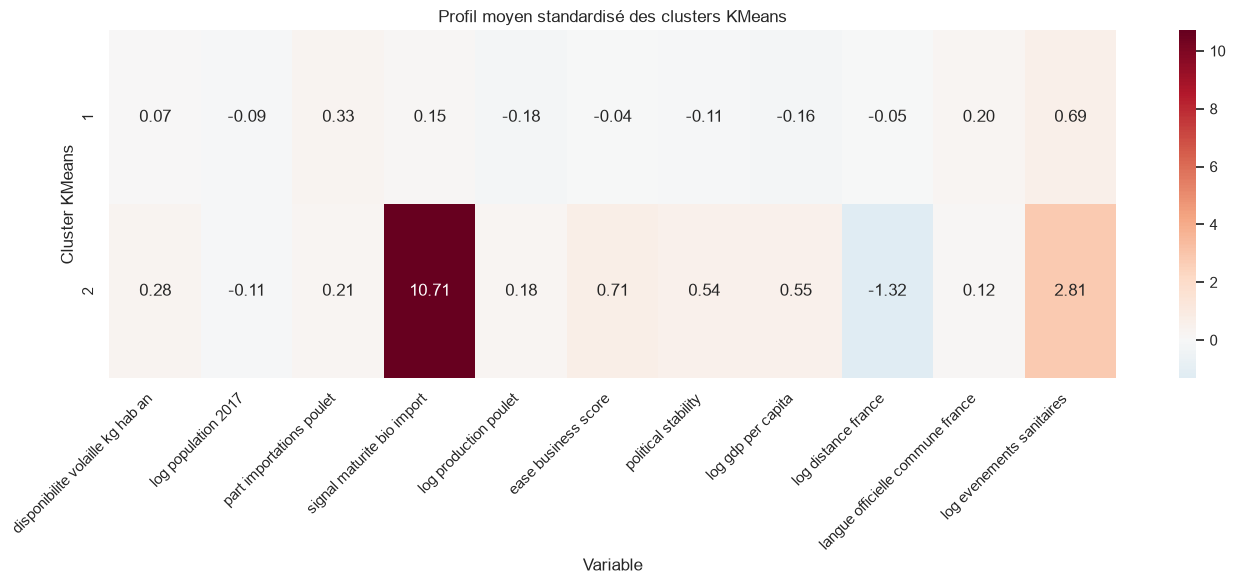

,disponibilite volaille kg hab an,log population 2017,part importations poulet,signal maturite bio import,log production poulet,ease business score,political stability,log gdp per capita,log distance france,langue officielle commune france,log evenements sanitaires
cluster_kmeans,,,,,,,,,,,
1,0.068484,-0.085544,0.32564,0.145683,-0.178454,-0.036771,-0.106398,-0.161605,-0.054282,0.196721,0.693126
2,0.277070,-0.113408,0.21088,10.706640,0.181747,0.708200,0.543288,0.550938,-1.323569,0.125000,2.811417


In [27]:
# Section 10.1 - Calcul du profil moyen des clusters KMeans.
# Objectif : décrire chaque cluster par ses valeurs moyennes sur les variables actives standardisées.

# On repart de X_scaled, c'est-à-dire des variables actives transformées avec RobustScaler.
# reset_index() permet de récupérer le code pays pour rattacher chaque ligne à son cluster KMeans.
clustered_scaled = X_scaled.reset_index().merge(
    projection[['iso3_final', 'cluster_kmeans']],
    on='iso3_final',
    how='left',
)

# Pour chaque cluster, on calcule la moyenne des variables standardisées.
# Une moyenne positive signifie que le cluster est au-dessus de la médiane globale sur cette variable.
# Une moyenne négative signifie qu'il est en dessous de la médiane globale.
cluster_profiles = clustered_scaled.groupby('cluster_kmeans')[active_features].mean()

# Les noms techniques des variables sont remplacés par des libellés français pour faciliter la lecture.
cluster_profiles_fr = cluster_profiles.rename(columns=label_fr)

# La heatmap permet d'identifier rapidement les variables qui caractérisent chaque cluster.
# Rouge = valeur standardisée plutôt positive ; bleu = valeur standardisée plutôt négative.
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles_fr, cmap='RdBu_r', center=0, annot=True, fmt='.2f')
plt.title('Profil moyen standardisé des clusters KMeans')
plt.xlabel('Variable')
plt.ylabel('Cluster KMeans')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Le tableau donne les mêmes valeurs que la heatmap, utile pour commenter précisément les écarts.
display(cluster_profiles_fr)

### 10.2 Lecture métier de la heatmap des profils

La heatmap montre deux familles de marchés assez contrastées.

La heatmap ne sert pas à élire un cluster gagnant. Elle décrit les familles de marchés : certains groupes rassemblent davantage de pays favorables sur le signal bio/import premium, la part des importations de poulet, le niveau de richesse, la stabilité politique, la facilité d'affaires, la proximité linguistique ou l'accessibilité relative. Ces informations servent à contextualiser les candidats, pas à remplacer le classement pays.

Le **cluster 2** présente des valeurs plus proches de la médiane globale, ou moins favorables sur les variables de signal bio/import, d'environnement économique, d'accessibilité ou de dépendance aux importations. Il correspond donc à une famille de marchés plus prudente : le potentiel n'est pas absent, mais il est moins fortement confirmé par les variables actives. Ces pays peuvent relever d'une stratégie de veille, de qualification progressive ou d'opportunités ciblées plutôt que d'une prospection prioritaire immédiate.

La lecture principale est donc la suivante : **les clusters décrivent des familles de marchés**, tandis que la recommandation export se décide au niveau des pays candidats. Cette interprétation doit ensuite être croisée avec les scores métier, le niveau de confiance et la stabilité CAH/KMeans pour éviter de décider uniquement à partir du cluster.

In [28]:
summary_cols = ['cluster_kmeans', 'iso3_final', 'biz__market_priority_score', 'biz__market_attractiveness_score', 'indice_confiance', 'biz__segment_action', 'biz__action_recommandee']
cluster_summary = (
    projection.merge(db[['iso3_final', 'biz__market_attractiveness_score']], on='iso3_final', how='left')
    .groupby('cluster_kmeans')
    .agg(
        nb_pays=('iso3_final', 'count'),
        score_priorite_moyen=('biz__market_priority_score', 'mean'),
        score_attractivite_moyen=('biz__market_attractiveness_score', 'mean'),
        confiance_moyenne=('indice_confiance', 'mean'),
        top_pays=('iso3_final', lambda s: ', '.join(projection.loc[s.index].sort_values('biz__market_priority_score', ascending=False)['iso3_final'].head(8))),
    )
    .sort_values('score_priorite_moyen', ascending=False)
)

display(cluster_summary)

,nb_pays,score_priorite_moyen,score_attractivite_moyen,confiance_moyenne,top_pays
cluster_kmeans,,,,,
2,16,51.502413,52.888767,100.000000,"CHE, BEL, AUT, LVA, EST, SWE, SVN, ESP"
1,122,40.938053,31.666508,91.120219,"LUX, DMA, ARE, CAN, ATG, GAB, MKD, IRL"


## 11. Lecture métier des groupes

### 11.1 Conclusion de la lecture métier des groupes

Cette cellule génère une première interprétation automatique. Elle doit être relue avec le contexte commercial : un cluster n'est pas une décision finale, mais une aide à la priorisation.

In [29]:
def qualifier_cluster(row):
    if row['score_priorite_moyen'] >= cluster_summary['score_priorite_moyen'].quantile(0.75):
        return 'Priorité commerciale forte : marchés à instruire rapidement.'
    if row['score_attractivite_moyen'] >= cluster_summary['score_attractivite_moyen'].median() and row['confiance_moyenne'] >= cluster_summary['confiance_moyenne'].median():
        return 'Marchés prometteurs : qualification ciblée et veille concurrentielle.'
    if row['confiance_moyenne'] < cluster_summary['confiance_moyenne'].median():
        return 'Marchés à documenter : potentiel à confirmer par données terrain.'
    return 'Marchés secondaires : suivi opportuniste ou approfondissement sectoriel.'

lecture_clusters = cluster_summary.copy()
lecture_clusters['lecture_metier'] = lecture_clusters.apply(qualifier_cluster, axis=1)
display(lecture_clusters)

,nb_pays,score_priorite_moyen,score_attractivite_moyen,confiance_moyenne,top_pays,lecture_metier
cluster_kmeans,,,,,,
2,16,51.502413,52.888767,100.000000,"CHE, BEL, AUT, LVA, EST, SWE, SVN, ESP",Priorité commerciale forte : marchés à instrui...
1,122,40.938053,31.666508,91.120219,"LUX, DMA, ARE, CAN, ATG, GAB, MKD, IRL",Marchés à documenter : potentiel à confirmer p...


### 11.2 En résumé : Top 5 des pays les mieux placés dans chaque cluster

Pour rendre la segmentation directement exploitable après la lecture métier des groupes, on affiche ici les **5 pays les mieux placés de chaque cluster** selon le score de priorité marché. Cette lecture permet de passer de l'interprétation générale du groupe à des exemples concrets de pays à étudier.

Le classement est fait séparément dans chaque cluster : un pays du cluster 1 n'est donc pas comparé directement à un pays du cluster 2 dans ce tableau. L'objectif est d'identifier les meilleurs représentants de chaque famille de marchés.

In [30]:
# Section 11.2 - Top 5 des pays les mieux placés dans chaque cluster.
# Critère retenu : le score de priorité marché.
# On classe donc les pays à l'intérieur de chaque cluster, du plus prioritaire au moins prioritaire.

top_by_cluster = (
    projection.sort_values(
        ['cluster_kmeans', 'biz__market_priority_score'],
        ascending=[True, False],
    )
    .groupby('cluster_kmeans')
    .head(5)
    .copy()
)

# On conserve uniquement les colonnes utiles pour une lecture métier courte.
top_by_cluster_cols = [
    'cluster_kmeans',
    'iso3_final',
    'nom_pays',
    'biz__market_priority_score',
    'indice_confiance',
    'niveau_confiance',
    'biz__segment_action',
    'biz__action_recommandee',
]
top_by_cluster_cols = [col for col in top_by_cluster_cols if col in top_by_cluster.columns]

top_by_cluster_display = top_by_cluster[top_by_cluster_cols].rename(columns={
    'cluster_kmeans': 'Cluster KMeans',
    'iso3_final': 'Code pays',
    'nom_pays': 'Pays',
    'biz__market_priority_score': 'Score priorité marché',
    'indice_confiance': 'Indice de confiance',
    'niveau_confiance': 'Niveau de confiance',
    'biz__segment_action': 'Segment action',
    'biz__action_recommandee': 'Action recommandée',
})

for col in ['Score priorité marché', 'Indice de confiance']:
    if col in top_by_cluster_display.columns:
        top_by_cluster_display[col] = top_by_cluster_display[col].round(2)

print('Top 5 des pays les mieux placés dans chaque cluster')
display(top_by_cluster_display)

Top 5 des pays les mieux placés dans chaque cluster


,Cluster KMeans,Code pays,Pays,Score priorité marché,Indice de confiance,Niveau de confiance,Segment action,Action recommandée
76,1,LUX,Luxembourg,71.75,83.33,Correct,Priorite immediate,Approfondir en priorite
33,1,DMA,Dominique,58.64,100.00,Eleve,Priorite immediate,Approfondir en priorite
3,1,ARE,Émirats arabes unis,57.39,100.00,Eleve,Priorite immediate,Approfondir en priorite
22,1,CAN,Canada,55.05,83.33,Correct,Priorite immediate,Approfondir en priorite
6,1,ATG,Antigua-et-Barbuda,54.81,83.33,Correct,Priorite immediate,Approfondir en priorite
23,2,CHE,Suisse,67.99,100.00,Eleve,Priorite immediate,Approfondir en priorite
10,2,BEL,Belgique,56.67,100.00,Eleve,Priorite immediate,Approfondir en priorite
8,2,AUT,Autriche,55.04,100.00,Eleve,Priorite immediate,Approfondir en priorite
77,2,LVA,Lettonie,54.98,100.00,Eleve,Priorite immediate,Approfondir en priorite
39,2,EST,Estonie,53.12,100.00,Eleve,Priorite immediate,Approfondir en priorite


## 12. <a id="Choix-du-clustering">Choix du cluster </a> pays à recommander

La section précédente donne le **Top 5 des pays les mieux placés dans chaque cluster KMeans**. Pour formuler une recommandation, on ne choisit pas un cluster gagnant : on classe les pays prioritaires fiables, puis on utilise KMeans et la CAH pour qualifier leur famille de marché et leur robustesse.

L'objectif de cette section est double :

- identifier les pays du Top 5 qui appartiennent à la même famille selon **KMeans** et selon la **CAH alignée** ;
- visualiser ces pays dans le plan factoriel **PC1 / PC2** avec deux lectures côte à côte : une projection colorée par la CAH et une projection colorée par KMeans.

Si un pays apparaît dans la même famille sur les deux projections, la recommandation est plus robuste. Si un pays change de famille entre CAH et KMeans, il ne doit pas être rejeté automatiquement, mais il doit être relu plus finement avant arbitrage commercial.

Exploitation du Top 5 : contrôle CAH / KMeans


,Cluster KMeans,Cluster CAH aligné,Code pays,Pays,Score priorité marché,Indice de confiance,Segment action,Accord CAH / KMeans,Lecture décisionnelle
76,1,1,LUX,Luxembourg,71.75,83.33,Priorite immediate,True,Recommandation robuste : même famille selon KM...
33,1,1,DMA,Dominique,58.64,100.00,Priorite immediate,True,Recommandation robuste : même famille selon KM...
3,1,1,ARE,Émirats arabes unis,57.39,100.00,Priorite immediate,True,Recommandation robuste : même famille selon KM...
22,1,1,CAN,Canada,55.05,83.33,Priorite immediate,True,Recommandation robuste : même famille selon KM...
6,1,1,ATG,Antigua-et-Barbuda,54.81,83.33,Priorite immediate,True,Recommandation robuste : même famille selon KM...
23,2,2,CHE,Suisse,67.99,100.00,Priorite immediate,True,Recommandation robuste : même famille selon KM...
10,2,1,BEL,Belgique,56.67,100.00,Priorite immediate,False,A relire : famille différente selon CAH et KMeans
8,2,2,AUT,Autriche,55.04,100.00,Priorite immediate,True,Recommandation robuste : même famille selon KM...
77,2,2,LVA,Lettonie,54.98,100.00,Priorite immediate,True,Recommandation robuste : même famille selon KM...
39,2,2,EST,Estonie,53.12,100.00,Priorite immediate,True,Recommandation robuste : même famille selon KM...


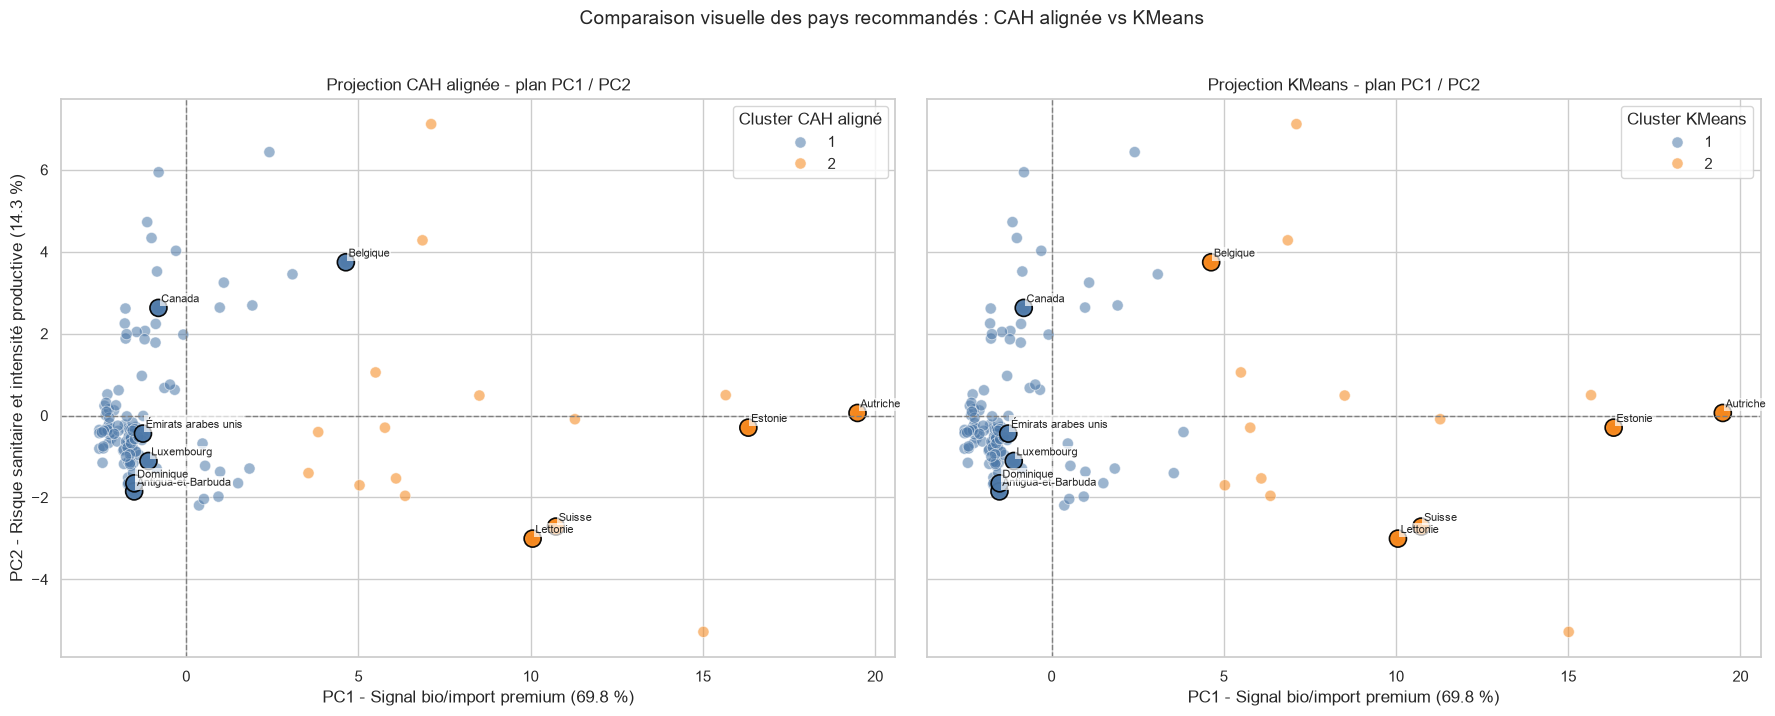

Lecture synthétique : 9 pays sur 10 du Top 5 par cluster sont dans la même famille selon KMeans et la CAH alignée. 1 pays nécessite une relecture.


In [31]:
# Section 12 - Exploitation du Top 5 par cluster et comparaison CAH / KMeans.
# Objectif : vérifier si les pays recommandés par le Top 5 KMeans restent dans la même famille
# lorsqu'on lit la segmentation avec la CAH alignée.

# On reconstitue le Top 5 par cluster pour rendre cette section rejouable indépendamment.
top5_recommandation = (
    projection.sort_values(
        ['cluster_kmeans', 'biz__market_priority_score'],
        ascending=[True, False],
    )
    .groupby('cluster_kmeans')
    .head(5)
    .copy()
)

# Accord CAH / KMeans : True si les deux méthodes placent le pays dans la même famille
# après alignement des labels CAH sur les labels KMeans.
top5_recommandation['accord_cah_kmeans'] = top5_recommandation['cluster_kmeans'].eq(
    top5_recommandation['cluster_cah_aligne']
)

top5_recommandation['lecture_recommandation'] = np.where(
    top5_recommandation['accord_cah_kmeans'],
    'Recommandation robuste : même famille selon KMeans et CAH',
    'A relire : famille différente selon CAH et KMeans',
)

# Tableau de décision : il combine le score métier, le cluster KMeans et le contrôle CAH.
top5_decision_cols = [
    'cluster_kmeans',
    'cluster_cah_aligne',
    'iso3_final',
    'nom_pays',
    'biz__market_priority_score',
    'indice_confiance',
    'biz__segment_action',
    'accord_cah_kmeans',
    'lecture_recommandation',
]

top5_decision = top5_recommandation[top5_decision_cols].rename(columns={
    'cluster_kmeans': 'Cluster KMeans',
    'cluster_cah_aligne': 'Cluster CAH aligné',
    'iso3_final': 'Code pays',
    'nom_pays': 'Pays',
    'biz__market_priority_score': 'Score priorité marché',
    'indice_confiance': 'Indice de confiance',
    'biz__segment_action': 'Segment action',
    'accord_cah_kmeans': 'Accord CAH / KMeans',
    'lecture_recommandation': 'Lecture décisionnelle',
})

for col in ['Score priorité marché', 'Indice de confiance']:
    top5_decision[col] = top5_decision[col].round(2)

print('Exploitation du Top 5 : contrôle CAH / KMeans')
display(top5_decision)

# Préparation des deux projections comparables.
# Les mêmes pays sont annotés dans les deux graphes pour vérifier visuellement
# si leur appartenance de cluster est stable selon la méthode.
top5_iso3 = set(top5_recommandation['iso3_final'])
projection_compare = projection.copy()
projection_compare['est_top5_recommande'] = projection_compare['iso3_final'].isin(top5_iso3)

cluster_palette = {1: '#4C78A8', 2: '#F58518'}
axis_labels_section12 = {
    'PC1': 'Signal bio/import premium',
    'PC2': 'Risque sanitaire et intensité productive',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True)
plot_specs = [
    ('cluster_cah_aligne', 'Projection CAH alignée - plan PC1 / PC2', 'Cluster CAH aligné'),
    ('cluster_kmeans', 'Projection KMeans - plan PC1 / PC2', 'Cluster KMeans'),
]

for ax, (cluster_col, title, legend_title) in zip(axes, plot_specs):
    sns.scatterplot(
        data=projection_compare,
        x='PC1',
        y='PC2',
        hue=cluster_col,
        palette=cluster_palette,
        s=65,
        alpha=0.55,
        ax=ax,
    )

    # Les pays du Top 5 sont entourés et annotés pour faciliter la comparaison entre CAH et KMeans.
    top5_points = projection_compare[projection_compare['est_top5_recommande']]
    sns.scatterplot(
        data=top5_points,
        x='PC1',
        y='PC2',
        hue=cluster_col,
        palette=cluster_palette,
        s=150,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.95,
        legend=False,
        ax=ax,
    )

    for _, row in top5_points.iterrows():
        ax.text(
            row['PC1'] + 0.08,
            row['PC2'] + 0.08,
            row['nom_pays'],
            fontsize=8,
            ha='left',
            va='bottom',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.70, pad=1.2),
        )

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 - {axis_labels_section12['PC1']} ({variance_lookup.get('PC1', np.nan):.1f} %)")
    ax.set_ylabel(f"PC2 - {axis_labels_section12['PC2']} ({variance_lookup.get('PC2', np.nan):.1f} %)")
    ax.legend(title=legend_title, loc='best')

plt.suptitle('Comparaison visuelle des pays recommandés : CAH alignée vs KMeans', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

nb_top5 = len(top5_recommandation)
nb_top5_accord = int(top5_recommandation['accord_cah_kmeans'].sum())
nb_top5_desaccord = nb_top5 - nb_top5_accord
accord_verbe = 'est' if nb_top5_accord == 1 else 'sont'
desaccord_texte = 'pays nécessite' if nb_top5_desaccord == 1 else 'pays nécessitent'

print(
    f'Lecture synthétique : {nb_top5_accord} pays sur {nb_top5} du Top 5 par cluster '
    f'{accord_verbe} dans la même famille selon KMeans et la CAH alignée. '
    f'{nb_top5_desaccord} {desaccord_texte} une relecture.'
)

### 12.1 Lecture des recommandations

Le contrôle croisé entre KMeans et la CAH sert à relire les meilleurs pays candidats, pas à désigner un cluster gagnant. Un bon candidat doit combiner un score de priorité élevé, un niveau de confiance solide et une lecture cohérente dans l'espace ACP.

Les clusters restent utiles pour comparer les familles de marchés : deux pays peuvent être prioritaires, mais relever de contextes différents ou présenter une stabilité différente entre KMeans et CAH.

La **Belgique** peut rester dans la shortlist, mais la décision finale privilégie la Suisse lorsque son score composite est supérieur et que sa lecture CAH/KMeans est plus robuste.

La recommandation opérationnelle est donc : prioriser d'abord les pays du Top 5 qui sont confirmés par les deux méthodes, puis traiter les pays suivants comme marchés de comparaison ou de sécurisation commerciale.

### 12.2 Démarche en entonnoir : candidats prioritaires, shortlist 3 puis pays recommandé

Cette section transforme le récapitulatif précédent en **démarche de décision**. L'objectif n'est plus seulement de lister les pays intéressants, mais d'expliquer comment on passe progressivement d'un ensemble de pays prioritaires fiables à un choix pays argumenté pour l'exportation de poulets bio.

La logique d'entonnoir est la suivante :

1. **Candidats prioritaires fiables** : on part des pays du segment `Priorite immediate` et du meilleur niveau de confiance disponible.
2. **Top 5 pays** : on classe ces candidats par score composite de ranking, sans imposer un cluster gagnant.
3. **Shortlist 3** : on conserve les trois pays les plus prometteurs du Top 5, en tenant compte du score et de la stabilité CAH/KMeans.
4. **Pays recommandé** : on retient le premier pays de la shortlist, en l'argumentant avec les variables de décision sélectionnées et les 3 dimensions ACP utilisées pour le clustering.

Le score composite utilisé pour le classement est `biz__market_priority_score`, construit en amont comme score de priorité marché. Il sert ici de score de ranking opérationnel. La décision est ensuite éclairée par les trois dimensions ACP retenues :

- **PC1** : signal bio/import premium ;
- **PC2** : risque sanitaire et intensité productive ;
- **PC3** : taille productive, stabilité et dépendance import.

La cellule suivante affiche donc l'entonnoir complet des candidats prioritaires, puis détaille la shortlist de 3 pays avec les dimensions PC1, PC2 et PC3 et les variables de décision nécessaires pour justifier le pays recommandé.

In [32]:
# Section 12.2 - Démarche en entonnoir vers le choix du pays à recommander.
# Objectif : partir des candidats prioritaires fiables, construire un Top 5 pays,
# construire une shortlist de 3 pays, puis retenir 1 pays recommandé avec un
# argumentaire fondé sur le score composite, les dimensions ACP retenues, les variables
# de décision sélectionnées et la convergence CAH / KMeans.

# Cette cellule est rejouable : si la section 12 n'a pas encore créé top5_recommandation,
# on le reconstruit à partir de la projection existante.
if 'top5_recommandation' not in globals():
    top5_recommandation = (
        projection.sort_values(
            ['cluster_kmeans', 'biz__market_priority_score'],
            ascending=[True, False],
        )
        .groupby('cluster_kmeans')
        .head(5)
        .copy()
    )
    top5_recommandation['accord_cah_kmeans'] = top5_recommandation['cluster_kmeans'].eq(
        top5_recommandation['cluster_cah_aligne']
    )

# Le score composite de ranking est le score de priorité marché construit en amont.
# Il synthétise la logique décisionnelle métier et sert ici à classer les pays,
# sans modifier la géométrie ACP utilisée pour le clustering.
score_ranking_col = 'biz__market_priority_score'

retained_pca_cols = [col for col in pca_cluster_cols if col in projection.columns]
if not retained_pca_cols:
    retained_pca_cols = [col for col in ['PC1', 'PC2', 'PC3'] if col in projection.columns]

# Variables de décision sélectionnées pour argumenter les profils pays.
# On les récupère depuis db car projection contient surtout les coordonnées ACP et les clusters.
pestel_cols = [
    'iso3_final',
    'signal_maturite_bio_import',
    'part_importations_poulet',
    'log_production_poulet',
    'log_population_2017',
    'disponibilite_volaille_kg_hab_an',
    'log_evenements_sanitaires',
    'political_stability',
    'ease_business_score',
    'log_gdp_per_capita',
    'log_distance_france',
    'langue_officielle_commune_france',
]
pestel_cols = [col for col in pestel_cols if col in db.columns]

candidats_entonnoir = top5_recommandation.merge(
    db[pestel_cols],
    on='iso3_final',
    how='left',
    suffixes=('', '_pestel'),
)

candidats_entonnoir['score_composite_ranking'] = candidats_entonnoir[score_ranking_col]

# Étape 1 : candidats prioritaires fiables.
# Les clusters servent à décrire les familles de marchés, mais ne décident pas du pays final.
candidats_prioritaires = candidats_entonnoir[
    candidats_entonnoir['biz__segment_action'].eq('Priorite immediate')
].copy()
if candidats_prioritaires.empty:
    candidats_prioritaires = candidats_entonnoir.copy()

if 'indice_confiance' in candidats_prioritaires.columns:
    niveau_confiance_reference = candidats_prioritaires['indice_confiance'].max()
    candidats_fiables = candidats_prioritaires[
        candidats_prioritaires['indice_confiance'].eq(niveau_confiance_reference)
    ].copy()
else:
    niveau_confiance_reference = np.nan
    candidats_fiables = candidats_prioritaires.copy()

# Étape 2 : Top 5 pays, sans imposer un cluster gagnant.
top5_candidats = (
    candidats_fiables.sort_values('score_composite_ranking', ascending=False)
    .head(5)
    .copy()
)
top5_cluster_1 = top5_candidats  # Alias conservé pour les cellules de synthèse rejouables.

# Étape 3 : shortlist de 3 pays dans le Top 5.
# Le score classe les pays ; l'accord CAH/KMeans sert de contrôle de robustesse.
shortlist_3 = (
    top5_candidats.sort_values(
        ['score_composite_ranking', 'accord_cah_kmeans'],
        ascending=[False, False],
    )
    .head(3)
    .copy()
)

# Étape 3 : pays recommandé = meilleur pays de la shortlist selon le score composite.
pays_recommande = shortlist_3.sort_values('score_composite_ranking', ascending=False).head(1).copy()

shortlist_iso3 = set(shortlist_3['iso3_final'])
pays_recommande_iso3 = set(pays_recommande['iso3_final'])

# Statut dans l'entonnoir pour lire le passage candidats fiables -> Top 5 -> shortlist 3 -> pays recommandé.
def qualifier_statut_entonnoir(row):
    if row['iso3_final'] in pays_recommande_iso3:
        return '3 - Pays recommandé'
    if row['iso3_final'] in shortlist_iso3:
        return '2 - Shortlist 3'
    return '1 - Top 5 candidats fiables'

top5_candidats['statut_entonnoir'] = top5_candidats.apply(qualifier_statut_entonnoir, axis=1)
top5_cluster_1 = top5_candidats

# Libellés métier des dimensions ACP retenues pour le clustering.
dimension_labels = {
    'PC1': 'PC1 - Signal bio/import premium',
    'PC2': 'PC2 - Risque sanitaire et intensité productive',
    'PC3': 'PC3 - Taille productive, stabilité et dépendance import',
}
dimension_labels = {col: label for col, label in dimension_labels.items() if col in retained_pca_cols}

# Tableau entonnoir : il montre le Top 5 des candidats fiables,
# les dimensions ACP retenues par pays et le statut final dans la décision.
entonnoir_cols = [
    'statut_entonnoir',
    'cluster_kmeans',
    'cluster_cah_aligne',
    'iso3_final',
    'nom_pays',
    'score_composite_ranking',
    'indice_confiance',
    'accord_cah_kmeans',
] + retained_pca_cols

entonnoir_display = (
    top5_candidats[entonnoir_cols]
    .rename(columns={
        'statut_entonnoir': 'Étape entonnoir',
        'cluster_kmeans': 'Cluster KMeans retenu',
        'cluster_cah_aligne': 'Cluster CAH aligné',
        'iso3_final': 'Code pays',
        'nom_pays': 'Pays',
        'score_composite_ranking': 'Score composite ranking',
        'indice_confiance': 'Indice de confiance',
        'accord_cah_kmeans': 'Accord CAH / KMeans',
        **dimension_labels,
    })
    .sort_values(['Étape entonnoir', 'Score composite ranking'], ascending=[False, False])
    .round({
        'Score composite ranking': 2,
        'Indice de confiance': 2,
        **{label: 2 for label in dimension_labels.values()},
    })
)

print('Démarche en entonnoir : candidats prioritaires fiables -> Top 5 -> shortlist 3 -> pays recommandé')
print(f'Niveau de confiance retenu : {niveau_confiance_reference:.2f}' if pd.notna(niveau_confiance_reference) else 'Niveau de confiance non disponible')
display(entonnoir_display)

# Tableau détaillé de la shortlist 3 avec les variables de décision sélectionnées.
shortlist_cols = [
    'iso3_final',
    'nom_pays',
    'score_composite_ranking',
    'cluster_kmeans',
    'cluster_cah_aligne',
    'accord_cah_kmeans',
] + retained_pca_cols + [col for col in pestel_cols if col != 'iso3_final']
shortlist_cols = [col for col in shortlist_cols if col in shortlist_3.columns]

shortlist_3_detail = (
    shortlist_3[shortlist_cols]
    .sort_values('score_composite_ranking', ascending=False)
    .rename(columns={
        'iso3_final': 'Code pays',
        'nom_pays': 'Pays',
        'score_composite_ranking': 'Score composite ranking',
        'cluster_kmeans': 'Cluster KMeans retenu',
        'cluster_cah_aligne': 'Cluster CAH aligné',
        'accord_cah_kmeans': 'Accord CAH / KMeans',
        **dimension_labels,
        'signal_maturite_bio_import': 'Signal bio/import premium',
        'part_importations_poulet': 'Part importations poulet',
        'log_production_poulet': 'Production poulet (log)',
        'log_population_2017': 'Population 2017 (log)',
        'disponibilite_volaille_kg_hab_an': 'Disponibilité volaille kg/hab/an',
        'log_evenements_sanitaires': 'Événements sanitaires (log)',
        'political_stability': 'Stabilité politique',
        'ease_business_score': 'Facilité affaires',
        'log_gdp_per_capita': 'PIB par habitant (log)',
        'log_distance_france': 'Distance France (log)',
        'langue_officielle_commune_france': 'Langue commune France',
    })
    .round(2)
)

print('Shortlist 3 des candidats fiables avec les dimensions ACP retenues et les variables de décision')
display(shortlist_3_detail)

# Argumentaire final pour le pays recommandé.
final = pays_recommande.iloc[0]
print('\nPays recommandé en priorité')
print('-' * 80)
print(f"Pays : {final['nom_pays']} ({final['iso3_final']})")
print(f"Score composite ranking : {final['score_composite_ranking']:.2f}")
print(f"Cluster KMeans retenu : {int(final['cluster_kmeans'])} ; Cluster CAH aligné : {int(final['cluster_cah_aligne'])}")
print(f"Accord CAH / KMeans : {'oui' if bool(final['accord_cah_kmeans']) else 'non'}")
print('Lecture des dimensions ACP retenues :')
for pc_col, pc_label in dimension_labels.items():
    print(f"- {pc_label} : {final[pc_col]:.2f}")
print('Argument synthétique :')
print(
    f"{final['nom_pays']} ressort en premier car le pays arrive en tête du Top 5 des candidats fiables "
    "et de la shortlist 3. Il combine le meilleur score composite de ranking, une appartenance "
    "stable entre KMeans et CAH, un signal bio/import favorable sur PC1, "
    "et des variables de décision compatibles avec une recommandation export prioritaire."
)

Démarche en entonnoir : candidats prioritaires fiables -> Top 5 -> shortlist 3 -> pays recommandé
Niveau de confiance retenu : 100.00


,Étape entonnoir,Cluster KMeans retenu,Cluster CAH aligné,Code pays,Pays,Score composite ranking,Indice de confiance,Accord CAH / KMeans,PC1 - Signal bio/import premium,PC2 - Risque sanitaire et intensité productive,"PC3 - Taille productive, stabilité et dépendance import"
5,3 - Pays recommandé,2,2,CHE,Suisse,67.99,100.0,True,10.74,-2.71,0.65
1,2 - Shortlist 3,1,1,DMA,Dominique,58.64,100.0,True,-1.50,-1.66,-2.76
2,2 - Shortlist 3,1,1,ARE,Émirats arabes unis,57.39,100.0,True,-1.26,-0.44,-1.13
6,1 - Top 5 candidats fiables,2,1,BEL,Belgique,56.67,100.0,False,4.64,3.74,-0.74
7,1 - Top 5 candidats fiables,2,2,AUT,Autriche,55.04,100.0,True,19.49,0.06,0.49


Shortlist 3 des candidats fiables avec les dimensions ACP retenues et les variables de décision


,Code pays,Pays,Score composite ranking,Cluster KMeans retenu,Cluster CAH aligné,Accord CAH / KMeans,PC1 - Signal bio/import premium,PC2 - Risque sanitaire et intensité productive,"PC3 - Taille productive, stabilité et dépendance import",Signal bio/import premium,Part importations poulet,Production poulet (log),Population 2017 (log),Disponibilité volaille kg/hab/an,Événements sanitaires (log),Stabilité politique,Facilité affaires,PIB par habitant (log),Distance France (log),Langue commune France
5,CHE,Suisse,67.99,2,2,True,10.74,-2.71,0.65,2.49,0.27,11.41,9.04,15.72,0.0,1.26,76.61,11.13,6.08,1.0
1,DMA,Dominique,58.64,1,1,True,-1.50,-1.66,-2.76,-0.32,0.91,5.90,4.28,35.19,0.0,1.20,61.67,9.45,8.83,1.0
2,ARE,Émirats arabes unis,57.39,1,1,True,-1.26,-0.44,-1.13,-0.30,0.88,10.96,9.16,43.47,0.0,0.62,79.30,11.16,8.57,0.0



Pays recommandé en priorité
--------------------------------------------------------------------------------
Pays : Suisse (CHE)
Score composite ranking : 67.99
Cluster KMeans retenu : 2 ; Cluster CAH aligné : 2
Accord CAH / KMeans : oui
Lecture des dimensions ACP retenues :
- PC1 - Signal bio/import premium : 10.74
- PC2 - Risque sanitaire et intensité productive : -2.71
- PC3 - Taille productive, stabilité et dépendance import : 0.65
Argument synthétique :
Suisse ressort en premier car le pays arrive en tête du Top 5 des candidats fiables et de la shortlist 3. Il combine le meilleur score composite de ranking, une appartenance stable entre KMeans et CAH, un signal bio/import favorable sur PC1, et des variables de décision compatibles avec une recommandation export prioritaire.


## 13. Synthèse finale des recommandations

Conclusion de l'étude : cette section reprend la logique de synthèse finale du notebook `02_acp_clustering_visualisations`, mais l'adapte à la démarche retenue ici.

### 13.1 Entonnoir de décision et recommandation finale

La recommandation n'est pas construite comme un simple classement automatique. Elle suit une chaîne de décision lisible :

1. identifier les **candidats prioritaires fiables** ;
2. examiner le **Top 5 pays** parmi ces candidats ;
3. réduire ce Top 5 à une **shortlist de 3 pays** ;
4. choisir un **pays prioritaire** avec un argumentaire fondé sur le score composite de ranking, les variables de décision et les trois dimensions ACP retenues.

La cellule suivante formalise cette synthèse finale sous forme de tableau puis d'argumentaire stratégique.

In [33]:
# ---------------------------------------------------------------
# Synthese finale des recommandations
# ---------------------------------------------------------------

# Cette cellule formalise la recommandation finale sur le modèle du notebook 02 :
# tableau de synthèse, lecture par rang, puis décision stratégique.

retained_pca_cols = [col for col in pca_cluster_cols if col in projection.columns]
if not retained_pca_cols:
    retained_pca_cols = [col for col in ['PC1', 'PC2', 'PC3'] if col in projection.columns]

dimension_labels = {
    'PC1': 'PC1 - Signal bio/import premium',
    'PC2': 'PC2 - Risque sanitaire et intensité productive',
    'PC3': 'PC3 - Taille productive, stabilité et dépendance import',
}
dimension_labels = {col: label for col, label in dimension_labels.items() if col in retained_pca_cols}

if 'top5_cluster_1' not in globals() or 'shortlist_3' not in globals() or 'pays_recommande' not in globals():
    if 'top5_recommandation' not in globals():
        top5_recommandation = (
            projection.sort_values(
                ['cluster_kmeans', 'biz__market_priority_score'],
                ascending=[True, False],
            )
            .groupby('cluster_kmeans')
            .head(5)
            .copy()
        )
        top5_recommandation['accord_cah_kmeans'] = top5_recommandation['cluster_kmeans'].eq(
            top5_recommandation['cluster_cah_aligne']
        )

    pestel_cols_synthese = [
        'iso3_final',
        'signal_maturite_bio_import',
        'part_importations_poulet',
        'log_production_poulet',
        'log_population_2017',
        'disponibilite_volaille_kg_hab_an',
        'log_evenements_sanitaires',
        'political_stability',
        'ease_business_score',
        'log_gdp_per_capita',
        'log_distance_france',
        'langue_officielle_commune_france',
    ]
    pestel_cols_synthese = [col for col in pestel_cols_synthese if col in db.columns]

    candidats_synthese = top5_recommandation.merge(
        db[pestel_cols_synthese],
        on='iso3_final',
        how='left',
        suffixes=('', '_pestel'),
    )
    candidats_synthese['score_composite_ranking'] = candidats_synthese['biz__market_priority_score']

    candidats_prioritaires = candidats_synthese[
        candidats_synthese['biz__segment_action'].eq('Priorite immediate')
    ].copy()
    if candidats_prioritaires.empty:
        candidats_prioritaires = candidats_synthese.copy()

    if 'indice_confiance' in candidats_prioritaires.columns:
        niveau_confiance_reference = candidats_prioritaires['indice_confiance'].max()
        candidats_fiables = candidats_prioritaires[
            candidats_prioritaires['indice_confiance'].eq(niveau_confiance_reference)
        ].copy()
    else:
        niveau_confiance_reference = np.nan
        candidats_fiables = candidats_prioritaires.copy()

    top5_cluster_1 = (
        candidats_fiables.sort_values('score_composite_ranking', ascending=False)
        .head(5)
        .copy()
    )
    shortlist_3 = (
        top5_cluster_1.sort_values(
            ['accord_cah_kmeans', 'score_composite_ranking'],
            ascending=[False, False],
        )
        .head(3)
        .copy()
    )
    pays_recommande = shortlist_3.sort_values('score_composite_ranking', ascending=False).head(1).copy()

shortlist_iso3 = set(shortlist_3['iso3_final'])
pays_recommande_iso3 = set(pays_recommande['iso3_final'])

synthese_finale = top5_cluster_1.sort_values('score_composite_ranking', ascending=False).copy()
synthese_finale['rang_top5_candidats'] = range(1, len(synthese_finale) + 1)
synthese_finale['statut_recommandation'] = np.select(
    [
        synthese_finale['iso3_final'].isin(pays_recommande_iso3),
        synthese_finale['iso3_final'].isin(shortlist_iso3),
    ],
    [
        'Pays recommandé',
        'Shortlist 3',
    ],
    default='Top 5 candidats fiables',
)

synthese_cols = [
    'statut_recommandation',
    'rang_top5_candidats',
    'iso3_final',
    'nom_pays',
    'score_composite_ranking',
    'cluster_kmeans',
    'cluster_cah_aligne',
    'accord_cah_kmeans',
] + retained_pca_cols + [
    'signal_maturite_bio_import',
    'part_importations_poulet',
    'log_production_poulet',
    'log_population_2017',
    'disponibilite_volaille_kg_hab_an',
    'log_evenements_sanitaires',
    'political_stability',
    'ease_business_score',
    'log_gdp_per_capita',
    'log_distance_france',
    'langue_officielle_commune_france',
]
synthese_cols = [col for col in synthese_cols if col in synthese_finale.columns]

synthese_finale_display = (
    synthese_finale[synthese_cols]
    .rename(columns={
        'statut_recommandation': 'Statut recommandation',
        'rang_top5_candidats': 'Rang Top 5 candidats fiables',
        'iso3_final': 'Code pays',
        'nom_pays': 'Pays',
        'score_composite_ranking': 'Score composite ranking',
        'cluster_kmeans': 'Cluster KMeans retenu',
        'cluster_cah_aligne': 'Cluster CAH aligné',
        'accord_cah_kmeans': 'Accord CAH / KMeans',
        **dimension_labels,
        'signal_maturite_bio_import': 'Signal bio/import premium',
        'part_importations_poulet': 'Part importations poulet',
        'log_production_poulet': 'Production poulet (log)',
        'log_population_2017': 'Population 2017 (log)',
        'disponibilite_volaille_kg_hab_an': 'Disponibilité volaille kg/hab/an',
        'log_evenements_sanitaires': 'Événements sanitaires (log)',
        'political_stability': 'Stabilité politique',
        'ease_business_score': 'Facilité affaires',
        'log_gdp_per_capita': 'PIB par habitant (log)',
        'log_distance_france': 'Distance France (log)',
        'langue_officielle_commune_france': 'Langue commune France',
    })
    .round(2)
)

print('\n' + '=' * 90)
print('SYNTHESE FINALE DES RECOMMANDATIONS - EXPORT POULETS BIO')
print('=' * 90)
print()
print('Entonnoir de décision : candidats prioritaires fiables -> Top 5 -> shortlist 3 -> pays recommandé')
print()
display(synthese_finale_display)

if 'pca' in globals() and hasattr(pca, 'explained_variance_ratio_'):
    n_dims = len(retained_pca_cols)
    acp_summary_finale = pd.DataFrame({
        'Dimension ACP': [f'PC{i}' for i in range(1, n_dims + 1)],
        'Lecture métier': [dimension_labels[f'PC{i}'].split(' - ', 1)[1] for i in range(1, n_dims + 1)],
        'Variance expliquée (%)': np.round(pca.explained_variance_ratio_[:n_dims] * 100, 2),
        'Variance cumulée (%)': np.round(np.cumsum(pca.explained_variance_ratio_[:n_dims]) * 100, 2),
    })
    print(f'Rappel ACP - {n_dims} dimensions retenues pour le clustering')
    display(acp_summary_finale)
    print(f"Variance cumulée sur {n_dims} dimensions : {np.cumsum(pca.explained_variance_ratio_[:n_dims])[-1] * 100:.2f}%")
    print()

print('-' * 90)
print('LECTURE STRATEGIQUE DE LA SHORTLIST 3')
print('-' * 90)
print()

for rang, (_, row) in enumerate(shortlist_3.sort_values('score_composite_ranking', ascending=False).iterrows(), start=1):
    print(f"RANG #{rang} - {row['nom_pays']} ({row['iso3_final']})")
    print(f"  Score composite ranking : {row['score_composite_ranking']:.2f}")
    print(f"  Cluster KMeans retenu : {int(row['cluster_kmeans'])} ; Cluster CAH aligné : {int(row['cluster_cah_aligne'])}")
    print(f"  Accord CAH / KMeans : {'oui' if bool(row['accord_cah_kmeans']) else 'non'}")
    print('  Dimensions ACP :')
    for pc_col, pc_label in dimension_labels.items():
        print(f"  - {pc_label} : {row[pc_col]:.2f}")

    if 'signal_maturite_bio_import' in row.index:
        print(f"  Signal bio/import premium : {row['signal_maturite_bio_import']:.2f}")
    if 'part_importations_poulet' in row.index:
        print(f"  Part importations poulet : {row['part_importations_poulet']:.2f}")
    if 'political_stability' in row.index:
        print(f"  Stabilité politique : {row['political_stability']:.2f}")
    if 'ease_business_score' in row.index:
        print(f"  Facilité affaires : {row['ease_business_score']:.2f}")
    print()

final = pays_recommande.iloc[0]
comparaison_shortlist = shortlist_3[~shortlist_3['iso3_final'].eq(final['iso3_final'])]
comparaison_names = comparaison_shortlist.sort_values('score_composite_ranking', ascending=False)['nom_pays'].tolist()
comparaison_label = ' et '.join(comparaison_names) if comparaison_names else 'les autres pays de la shortlist'

print('=' * 90)
print('DECISION FINALE')
print('=' * 90)
print()
print(f"Pays recommandé en priorité : {final['nom_pays']} ({final['iso3_final']})")
print(f"Score composite ranking : {final['score_composite_ranking']:.2f}")
print()
print('Pourquoi ce choix ?')
print(f"1. {final['nom_pays']} arrive en tête du Top 5 des candidats fiables et de la shortlist 3.")
print('2. Le pays est confirmé par les deux méthodes de clustering : KMeans et CAH alignée.')
print(f"3. PC1 est très élevé ({final['PC1']:.2f}), ce qui traduit un signal bio/import premium favorable.")
print('4. Les variables de décision confirment un environnement compatible avec une priorité export.')
print()
print('Recommandation opérationnelle :')
print(
    f"{final['nom_pays']} doit être instruite comme marché prioritaire pour l'exportation de poulets bio. "
    f"{comparaison_label} constituent les marchés de comparaison immédiats à conserver "
    "dans la shortlist pour sécuriser la décision commerciale."
)
print()
print('Prochaines étapes :')
print(f"1. Vérifier les contraintes sanitaires et réglementaires spécifiques à l'importation de poulets bio en {final['nom_pays']}.")
print('2. Identifier les distributeurs, importateurs ou réseaux spécialisés bio déjà actifs sur ce marché.')
print(f"3. Comparer les coûts logistiques et conditions commerciales avec {comparaison_label}.")
print('4. Valider la recommandation par une analyse terrain : prix, concurrence locale, habitudes de consommation et exigences de certification.')


SYNTHESE FINALE DES RECOMMANDATIONS - EXPORT POULETS BIO

Entonnoir de décision : candidats prioritaires fiables -> Top 5 -> shortlist 3 -> pays recommandé



,Statut recommandation,Rang Top 5 candidats fiables,Code pays,Pays,Score composite ranking,Cluster KMeans retenu,Cluster CAH aligné,Accord CAH / KMeans,PC1 - Signal bio/import premium,PC2 - Risque sanitaire et intensité productive,"PC3 - Taille productive, stabilité et dépendance import",Signal bio/import premium,Part importations poulet,Production poulet (log),Population 2017 (log),Disponibilité volaille kg/hab/an,Événements sanitaires (log),Stabilité politique,Facilité affaires,PIB par habitant (log),Distance France (log),Langue commune France
5,Pays recommandé,1,CHE,Suisse,67.99,2,2,True,10.74,-2.71,0.65,2.49,0.27,11.41,9.04,15.72,0.00,1.26,76.61,11.13,6.08,1.0
1,Shortlist 3,2,DMA,Dominique,58.64,1,1,True,-1.50,-1.66,-2.76,-0.32,0.91,5.90,4.28,35.19,0.00,1.20,61.67,9.45,8.83,1.0
2,Shortlist 3,3,ARE,Émirats arabes unis,57.39,1,1,True,-1.26,-0.44,-1.13,-0.30,0.88,10.96,9.16,43.47,0.00,0.62,79.30,11.16,8.57,0.0
6,Top 5 candidats fiables,4,BEL,Belgique,56.67,2,1,False,4.64,3.74,-0.74,0.78,0.32,13.03,9.34,12.65,3.71,0.43,72.18,10.82,5.57,1.0
7,Top 5 candidats fiables,5,AUT,Autriche,55.04,2,2,True,19.49,0.06,0.49,4.35,0.26,11.75,9.08,18.20,3.53,1.05,78.71,10.89,6.94,0.0


Rappel ACP - 3 dimensions retenues pour le clustering


,Dimension ACP,Lecture métier,Variance expliquée (%),Variance cumulée (%)
0,PC1,Signal bio/import premium,69.83,69.83
1,PC2,Risque sanitaire et intensité productive,14.35,84.18
2,PC3,"Taille productive, stabilité et dépendance import",5.73,89.90


Variance cumulée sur 3 dimensions : 89.90%

------------------------------------------------------------------------------------------
LECTURE STRATEGIQUE DE LA SHORTLIST 3
------------------------------------------------------------------------------------------

RANG #1 - Suisse (CHE)
  Score composite ranking : 67.99
  Cluster KMeans retenu : 2 ; Cluster CAH aligné : 2
  Accord CAH / KMeans : oui
  Dimensions ACP :
  - PC1 - Signal bio/import premium : 10.74
  - PC2 - Risque sanitaire et intensité productive : -2.71
  - PC3 - Taille productive, stabilité et dépendance import : 0.65
  Signal bio/import premium : 2.49
  Part importations poulet : 0.27
  Stabilité politique : 1.26
  Facilité affaires : 76.61

RANG #2 - Dominique (DMA)
  Score composite ranking : 58.64
  Cluster KMeans retenu : 1 ; Cluster CAH aligné : 1
  Accord CAH / KMeans : oui
  Dimensions ACP :
  - PC1 - Signal bio/import premium : -1.50
  - PC2 - Risque sanitaire et intensité productive : -1.66
  - PC3 - Taille p

### 13.2 Dendrogramme CAH final de synthèse

Ce dendrogramme reprend la CAH selon la méthode de Ward sur les dimensions ACP retenues pour le clustering. Il sert ici de visualisation finale : les feuilles correspondent aux pays du périmètre ACP, la ligne rouge indique la hauteur de coupe, et les deux grandes branches sous la coupe matérialisent les familles de marchés observées.

Cette figure ne remplace pas la décision pays : elle montre le contexte de segmentation dans lequel la Suisse ressort ensuite comme pays recommandé.

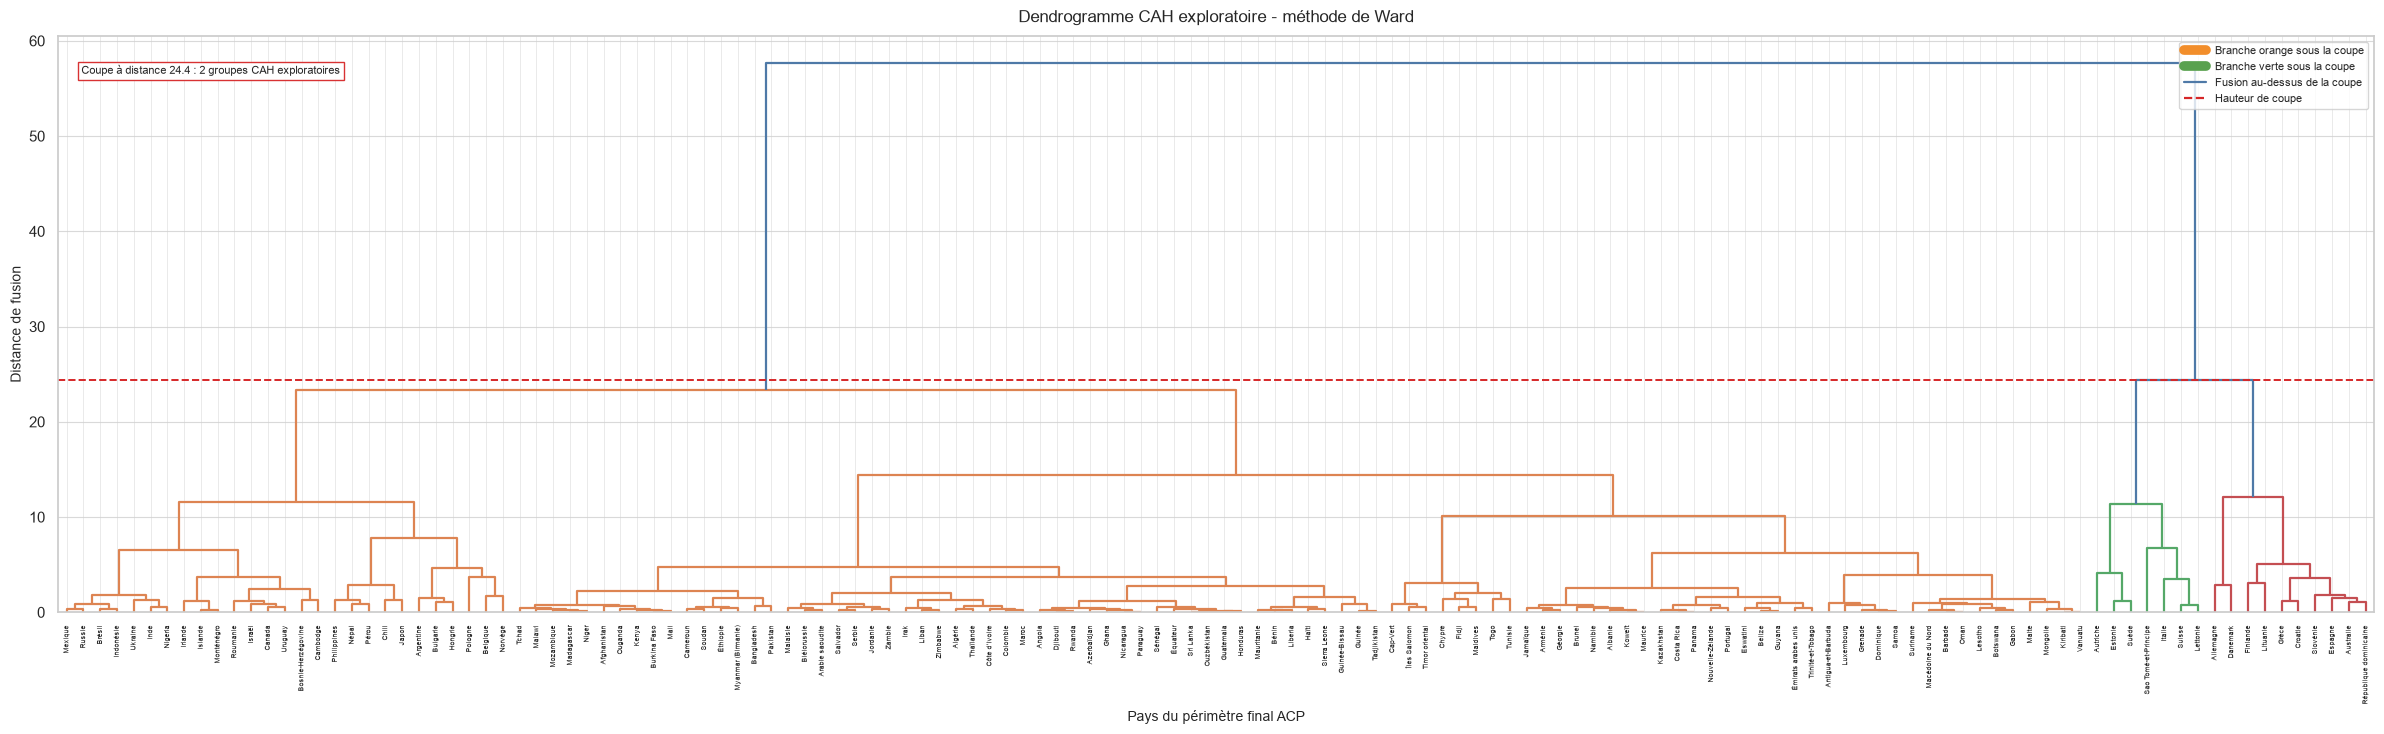

Lecture : le dendrogramme final reprend les pays du périmètre ACP et une coupe en deux grandes familles CAH.
Les branches colorées servent à visualiser les familles ; la recommandation finale reste décidée au niveau pays.


,nb_pays,score_priorite_moyen,exemples_pays
cluster_cah_synthese,,,
2,17,50.59,"Australie, Autriche, Suisse, Allemagne, Danema..."
1,121,40.98,"Afghanistan, Angola, Albanie, Émirats arabes u..."


In [34]:
# ---------------------------------------------------------------
# 13.2 Dendrogramme CAH final de synthèse
# ---------------------------------------------------------------

from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

pca_cols_dendrogramme_final = [col for col in pca_cluster_cols if col in projection.columns]
if not pca_cols_dendrogramme_final:
    pca_cols_dendrogramme_final = [col for col in ['PC1', 'PC2', 'PC3'] if col in projection.columns]

X_cah_final = projection[pca_cols_dendrogramme_final].copy()
Z_cah_final = linkage(X_cah_final, method='ward', metric='euclidean')

# On conserve une coupe en deux grandes familles, comme lecture finale de synthèse.
hauteur_coupe_finale = Z_cah_final[-2, 2]
projection['cluster_cah_synthese'] = fcluster(Z_cah_final, t=hauteur_coupe_finale, criterion='distance')

leaf_labels_final = projection['nom_pays'].astype(str).tolist()
orange_branch = '#f28e2b'
green_branch = '#59a14f'
above_cut_color = '#4e79a7'
cut_color = '#d62728'

fig_width = max(24, len(leaf_labels_final) * 0.16)
fig, ax = plt.subplots(figsize=(fig_width, 7.5))

with plt.rc_context({'lines.linewidth': 1.6}):
    dendrogram(
        Z_cah_final,
        labels=leaf_labels_final,
        leaf_rotation=90,
        leaf_font_size=5,
        color_threshold=hauteur_coupe_finale,
        above_threshold_color=above_cut_color,
        ax=ax,
    )

# Harmonisation visuelle des deux branches principales sous la coupe.
branch_colors = [orange_branch, green_branch]
for line in ax.get_lines():
    y_data = line.get_ydata()
    if len(y_data) and max(y_data) <= hauteur_coupe_finale:
        current_color = line.get_color()
        if current_color not in branch_colors:
            line.set_color(branch_colors[0])

ax.axhline(hauteur_coupe_finale, color=cut_color, linestyle='--', linewidth=1.4)
ax.text(
    0.01,
    0.95,
    f'Coupe à distance {hauteur_coupe_finale:.1f} : 2 groupes CAH exploratoires',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor=cut_color, alpha=0.95, boxstyle='square,pad=0.3'),
)

ax.set_title('Dendrogramme CAH exploratoire - méthode de Ward', fontsize=12, pad=10)
ax.set_xlabel('Pays du périmètre final ACP', fontsize=10)
ax.set_ylabel('Distance de fusion', fontsize=10)
ax.grid(axis='y', color='#d0d0d0', linewidth=0.8, alpha=0.8)
ax.grid(axis='x', color='#e0e0e0', linewidth=0.6, alpha=0.8)
ax.set_axisbelow(True)

legend_handles = [
    Line2D([0], [0], color=orange_branch, linewidth=7, label='Branche orange sous la coupe'),
    Line2D([0], [0], color=green_branch, linewidth=7, label='Branche verte sous la coupe'),
    Line2D([0], [0], color=above_cut_color, linewidth=1.6, label='Fusion au-dessus de la coupe'),
    Line2D([0], [0], color=cut_color, linestyle='--', linewidth=1.6, label='Hauteur de coupe'),
]
ax.legend(handles=legend_handles, loc='upper right', frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

cluster_cah_synthese_resume = (
    projection.groupby('cluster_cah_synthese')
    .agg(
        nb_pays=('iso3_final', 'size'),
        score_priorite_moyen=('biz__market_priority_score', 'mean'),
        exemples_pays=('nom_pays', lambda values: ', '.join(values.head(8))),
    )
    .sort_values('score_priorite_moyen', ascending=False)
    .round(2)
)

print('Lecture : le dendrogramme final reprend les pays du périmètre ACP et une coupe en deux grandes familles CAH.')
print('Les branches colorées servent à visualiser les familles ; la recommandation finale reste décidée au niveau pays.')
display(cluster_cah_synthese_resume)

## 14. Exports et rapport des attendus

### 14.1 Lecture des attendus du notebook 2 ACP Clustering Visualisation

Ce notebook transforme la base préparée dans le notebook 1 en lecture décisionnelle :

- l'ACP synthétise les dimensions marché, bio, institutionnelles, temporelles et qualité de données ;
- KMeans propose une segmentation exploitable des pays ;
- la CAH sert de contrôle de cohérence ;
- les profils de clusters permettent de traduire les groupes en priorités d'action ;
- la synthèse finale formalise le passage des candidats prioritaires fiables au choix argumenté du pays recommandé.

La recommandation finale ne doit pas être lue comme un classement automatique pur. Elle combine le signal statistique, la robustesse de la donnée et l'interprétation métier issue du contexte export.

### 14.2 Export du notebook

Les exports sont placés dans `data/processed/decision_export` afin de séparer les résultats de décision du socle de préparation produit par le notebook 1.

In [35]:
projection_export = projection.merge(
    db[['iso3_final', 'year', 'biz__market_attractiveness_score', 'biz__size_factor']],
    on='iso3_final',
    how='left',
)

projection_path = export_dir / 'zamoun_acp_projection_clusters.csv'
profiles_path = export_dir / 'zamoun_acp_cluster_profiles.csv'
summary_path = export_dir / 'zamoun_acp_cluster_summary.csv'
loadings_path = export_dir / 'zamoun_acp_variable_loadings.csv'

projection_export.to_csv(projection_path, index=False, encoding='utf-8-sig')
cluster_profiles_fr.to_csv(profiles_path, encoding='utf-8-sig')
lecture_clusters.to_csv(summary_path, encoding='utf-8-sig')
loadings_fr.to_csv(loadings_path, encoding='utf-8-sig')

print('Exports créés :')
for path in [projection_path, profiles_path, summary_path, loadings_path]:
    print('-', path.relative_to(project_root))

Exports créés :
- data\processed\decision_export\zamoun_acp_projection_clusters.csv
- data\processed\decision_export\zamoun_acp_cluster_profiles.csv
- data\processed\decision_export\zamoun_acp_cluster_summary.csv
- data\processed\decision_export\zamoun_acp_variable_loadings.csv


### 14.3 Rapport des attendus du notebook 2 ACP Clustering Visualisation

Ce notebook couvre les deux familles d'attendus montrées dans la grille :

| Attendu | Preuve dans le notebook |
|---|---|
| Réaliser des analyses multivariées pour comprendre la corrélation entre variables | définition des blocs de variables, heatmap des corrélations, tableau des corrélations fortes et lecture des redondances |
| Réaliser un centrage des données | `RobustScaler` centre les variables sur leur médiane et affiche le centre utilisé par variable |
| Créer l'éboulis des valeurs propres | tableau des valeurs propres, inertie expliquée et graphique d'éboulis |
| Justifier le nombre de dimensions retenues | 11 variables actives réduites à 3 composantes, soit 90,9 % de variance cumulée et 3 axes validés par Kaiser |
| Créer un cercle des corrélations | cercle PC1 / PC2 avec libellés français des variables |
| Réaliser une projection des individus | projection des pays dans le plan factoriel PC1 / PC2, puis projection colorée par clusters |
| Expliquer les caractéristiques des individus et leurs différences | scoring ACP exploratoire, profils de clusters, top pays par cluster, shortlist 3 et synthèse finale des recommandations |
| Réduire la dimension pour optimiser les modèles | KMeans et CAH sont entraînés sur les composantes ACP retenues, pas sur toutes les variables actives initiales |

Validation des 7 points du pipeline de données :

| Point de pipeline | Validation dans le notebook |
|---|---|
| 1. Normalisation des données et retrait des 3 pays les plus influents sur le plan agricole | standardisation robuste par `RobustScaler`; contrôle complémentaire avec retrait de Brazil, Fédération de Russie et Inde, 136 pays restants, ARI = 1,000 et 0 changement de cluster |
| 2. Réduction du nombre de données par ACP | 11 variables actives résumées en 3 composantes principales |
| 3. Interprétation des composantes au regard des critères d'évaluation | lectures PC1 à PC3 : signal bio/import premium; risque sanitaire et intensité productive; taille productive, stabilité et dépendance import |
| 4. Définition du nombre de segments à analyser | diagnostics inertie, silhouette et taille minimale; `k = 2` retenu |
| 5. Regroupement des pays ayant des données similaires | KMeans sur les composantes ACP retenues, contrôlé par CAH de Ward |
| 6. Sélection du segment le plus pertinent selon les critères d'importation | candidats du segment `Priorite immediate`, relus avec le score de priorité, `part_importations_poulet`, le signal bio/import et le niveau de confiance |
| 7. Identification du Top 5 des pays à cibler | Top 5 des candidats prioritaires fiables, shortlist 3, puis recommandation finale du pays le mieux justifié |

La logique est donc complète : les corrélations sont analysées avant l'ACP, l'ACP réduit la dimension, puis les modèles de clustering utilisent cet espace réduit pour produire une segmentation interprétable et une recommandation export argumentée.